# Combined StressID + WESAD physiological stress classification

This notebook adapts your uploaded WESAD framework to a **combined StressID + WESAD** pipeline and reports:

- **Cross-sample** evaluation
- **Cross-subject** evaluation
- **Binary classification**: stress vs non-stress
- **Multiclass classification**: stress / relaxation / other

## 1) Configuration


In [ ]:

# Colab dependencies
!pip -q install neurokit2 imbalanced-learn xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 27.3 MB/s eta 0:00:00


In [ ]:

import os
import re
import math
import json
import glob
import pickle
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

from scipy import signal
from scipy.signal import butter, filtfilt, find_peaks, welch, resample_poly
from scipy.integrate import trapezoid
from scipy.stats import skew, kurtosis, variation, moment, gmean, hmean, iqr

import neurokit2 as nk

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import RFE

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
np.random.seed(42)

In [ ]:
# =========================
# USER CONFIGURATION
# =========================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import numpy as np
import os
import glob
import re
import pickle

PROJECT_ROOT = Path('/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment')

# Dataset roots
STRESSID_BASE = PROJECT_ROOT / 'StressID Dataset'
STRESSID_ROOT = STRESSID_BASE / 'physiological'

# IMPORTANT:
# point this to the folder that contains S2/, S3/, ... and inside each subject folder the S*.pkl file
WESAD_ROOT = PROJECT_ROOT / 'WESAD Dataset' / 'WESAD'

# StressID metadata / labels
STRESSID_LABELS = STRESSID_BASE / 'labels.csv'
STRESSID_LABELS_V2 = STRESSID_BASE / 'labels_v2.csv'
STRESSID_LABELS_SUPP = STRESSID_BASE / 'labels_supplementary.csv'
STRESSID_DEMOGRAPHICS = STRESSID_BASE / 'demographics.csv'
STRESSID_SELF_ASSESSMENTS = STRESSID_BASE / 'self_assessments.csv'

# Output folder
OUTPUT_DIR = STRESSID_BASE / 'colab_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("STRESSID_ROOT:", STRESSID_ROOT)
print("WESAD_ROOT:", WESAD_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

# Common target sample rate after harmonization
# EDA and RR will be represented at this rate
TARGET_FS = 16  # Hz

# Windowing
WINDOW_SEC = 60
OVERLAP_SEC = 30

# Feature selection
USE_RFE = False
N_RFE_FEATURES = 30

# Model choices to benchmark
MODEL_ZOO = {
    'logreg': LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ),
    'svm_rbf': SVC(
        kernel='rbf',
        C=10.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=42
    ),
    'rf': RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    'extra_trees': ExtraTreesClassifier(
        n_estimators=500,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1
    ),
    'xgb': XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42
    ),
}

SCALE_MODELS = {'logreg', 'svm_rbf', 'knn'}

# WESAD / StressID sampling rates
WESAD_ECG_FS = 700
WESAD_LABEL_FS = 700
WESAD_WRIST_EDA_FS = 4
WESAD_CHEST_EDA_FS = 700

STRESSID_ECG_FS = 500
STRESSID_EDA_FS = 500

# Use chest EDA from RespiBAN for WESAD to align with ECG-origin RR
USE_WESAD_CHEST_EDA = True

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/PSL RA/ML-driven Stress Assessment
STRESSID_ROOT: /content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/physiological
WESAD_ROOT: /content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/WESAD Dataset/WESAD
OUTPUT_DIR: /content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs


## 2) StressID labels


In [ ]:
# =========================================================
# StressID labels from labels_v2.csv
# binary_target  <- binary-stress
# multiclass_target <- affect3-class-v2
# =========================================================

import pandas as pd

def load_stressid_labels(labels_path = STRESSID_LABELS_V2):
    df = pd.read_csv(labels_path, sep=";").copy()
    df.columns = [c.strip() for c in df.columns]

    required = ["subject/task", "binary-stress", "affect3-class-v2"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in labels file: {missing}")

    split_cols = df["subject/task"].astype(str).str.split("_", n=1, expand=True)
    df["subject_id"] = split_cols[0]
    df["task_name"] = split_cols[1]

    df["binary-stress"] = pd.to_numeric(df["binary-stress"], errors="coerce")
    df["affect3-class-v2"] = pd.to_numeric(df["affect3-class-v2"], errors="coerce")

    # final targets used by the combined pipeline
    df["binary_target"] = df["binary-stress"].map({
        0: "non_stress",
        1: "stress",
    })

    # paper 3-class:
    # 0 = relaxed, 1 = neutral, 2 = stressed
    # mapped to your combined label names:
    df["multiclass_target"] = df["affect3-class-v2"].map({
        0: "relaxation",
        1: "other",
        2: "stress",
    })

    stressid_labels = df[[
        "subject_id",
        "task_name",
        "binary_target",
        "multiclass_target",
        "binary-stress",
        "affect3-class-v2",
    ]].rename(columns={
        "binary-stress": "stressid_binary_stress_original",
        "affect3-class-v2": "stressid_affect3_class_v2_original",
    })

    print("StressID label counts")
    print(stressid_labels["binary_target"].value_counts(dropna=False))
    print()
    print(stressid_labels["multiclass_target"].value_counts(dropna=False))

    return stressid_labels

stressid_labels_df = load_stressid_labels()

StressID label counts
binary_target
stress        368
non_stress    332
Name: count, dtype: int64

multiclass_target
relaxation    257
other         242
stress        201
Name: count, dtype: int64


## 3) Common signal utilities

In [ ]:

def safe_resample(x, orig_fs, target_fs=TARGET_FS):
    x = np.asarray(x, dtype=float).reshape(-1)
    if len(x) == 0:
        return x
    if orig_fs == target_fs:
        return x.copy()
    g = math.gcd(int(orig_fs), int(target_fs))
    up = int(target_fs // g)
    down = int(orig_fs // g)
    return resample_poly(x, up, down)

from scipy.signal import butter, filtfilt

def bandpass_ecg(ecg, fs, low=0.5, high=40.0, order=4):
    ecg = np.asarray(ecg, dtype=float)

    if ecg.size < 10:
        return ecg

    nyq = 0.5 * fs
    low_norm = low / nyq
    high_norm = high / nyq

    # keep frequencies safely inside (0, 1)
    low_norm = max(low_norm, 1e-5)
    high_norm = min(high_norm, 0.999)

    if not (0 < low_norm < high_norm < 1):
        raise ValueError(
            f"Invalid ECG bandpass range: low={low}, high={high}, fs={fs}, "
            f"normalized=({low_norm:.6f}, {high_norm:.6f})"
        )

    b, a = butter(order, [low_norm, high_norm], btype='band')
    return filtfilt(b, a, ecg)

def lowpass_eda(eda, fs, cutoff=1.0, order=4):
    eda = np.asarray(eda, dtype=float).reshape(-1)
    nyq = 0.5 * fs
    cutoff = min(cutoff, nyq - 1e-3)
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, eda)

from scipy.signal import butter, filtfilt

def preprocess_eda_common(eda, fs=4, cutoff=1.0, order=4):
    eda = np.asarray(eda, dtype=float)

    if eda.size < 10:
        return eda

    nyq = 0.5 * fs
    cutoff_norm = cutoff / nyq
    cutoff_norm = min(max(cutoff_norm, 1e-5), 0.999)

    b, a = butter(order, cutoff_norm, btype='low')
    return filtfilt(b, a, eda)

def compute_rr_from_ecg(ecg, fs):
    ecg = np.asarray(ecg, dtype=float).reshape(-1)
    if len(ecg) < fs * 5:
        return np.array([]), np.array([])
    try:
        _, info = nk.ecg_peaks(ecg, sampling_rate=fs, correct_artifacts=True)
        peaks = np.asarray(info['ECG_R_Peaks'], dtype=int)
    except Exception:
        peaks, _ = find_peaks(ecg, distance=max(1, int(fs * 0.4)))

    if len(peaks) < 3:
        return np.array([]), np.array([])

    rr = np.diff(peaks) / fs
    rr_t = peaks[1:] / fs

    # artifact correction
    valid = (rr >= 0.3) & (rr <= 2.0)
    if valid.sum() == 0:
        return np.array([]), np.array([])
    rr_clean = rr.copy()
    rr_clean[~valid] = rr[valid].mean()
    return rr_t, rr_clean

def resample_rr_to_uniform(rr_t, rr, target_fs=TARGET_FS):
    if len(rr) < 3:
        return np.array([]), np.array([])
    t_new = np.arange(rr_t[0], rr_t[-1], 1.0 / target_fs)
    if len(t_new) < 3:
        return np.array([]), np.array([])
    rr_interp = np.interp(t_new, rr_t, rr)
    return t_new, rr_interp

def dominant_label(labels):
    labels = pd.Series(labels).dropna()
    if len(labels) == 0:
        return np.nan
    return labels.value_counts().idxmax()

## 4) Feature extraction

In [ ]:

def _safe_positive(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.array([1e-8])
    x = x.copy()
    min_positive = np.min(x[x > 0]) if np.any(x > 0) else 1e-8
    x[x <= 0] = min_positive
    return x

def statistical_features(sig, prefix):
    sig = np.asarray(sig, dtype=float)
    sig = sig[np.isfinite(sig)]
    if len(sig) == 0:
        return {f'{prefix}_mean': np.nan}
    pos = _safe_positive(sig)
    return {
        f'{prefix}_mean': np.mean(sig),
        f'{prefix}_geometric_mean': gmean(pos),
        f'{prefix}_harmonic_mean': hmean(pos),
        f'{prefix}_standard_deviation': np.std(sig),
        f'{prefix}_mean_absolute_deviation': np.mean(np.abs(sig - np.mean(sig))),
        f'{prefix}_variance': np.var(sig),
        f'{prefix}_median': np.median(sig),
        f'{prefix}_maximum': np.max(sig),
        f'{prefix}_minimum': np.min(sig),
        f'{prefix}_25th_percentile': np.percentile(sig, 25),
        f'{prefix}_75th_percentile': np.percentile(sig, 75),
        f'{prefix}_range': np.max(sig) - np.min(sig),
        f'{prefix}_interquartile_range': iqr(sig),
        f'{prefix}_variation_coefficient': variation(sig) if len(sig) > 1 else 0.0,
        f'{prefix}_central_moment': moment(sig, moment=2) if len(sig) > 1 else 0.0,
        f'{prefix}_skewness': skew(sig) if len(sig) > 2 else 0.0,
        f'{prefix}_kurtosis': kurtosis(sig) if len(sig) > 3 else 0.0,
    }

def nonlinear_features(sig, prefix):
    sig = np.asarray(sig, dtype=float)
    sig = sig[np.isfinite(sig)]
    if len(sig) < 10:
        return {
            f'{prefix}_approx_entropy': np.nan,
            f'{prefix}_sample_entropy': np.nan,
            f'{prefix}_SD1': np.nan,
            f'{prefix}_SD2': np.nan,
        }
    try:
        apen, _ = nk.entropy_approximate(sig, delay=1, dimension=2, tolerance='sd')
    except Exception:
        apen = np.nan
    try:
        sampen, _ = nk.entropy_sample(sig, delay=1, dimension=2, tolerance='sd')
    except Exception:
        sampen = np.nan

    diff = np.diff(sig)
    sd1 = np.sqrt(np.var(diff) / 2.0) if len(diff) > 0 else np.nan
    sd2 = np.sqrt(max(2 * np.var(sig) - (np.var(diff) / 2.0), 0)) if len(diff) > 0 else np.nan

    return {
        f'{prefix}_approx_entropy': float(apen) if pd.notna(apen) else np.nan,
        f'{prefix}_sample_entropy': float(sampen) if pd.notna(sampen) else np.nan,
        f'{prefix}_SD1': sd1,
        f'{prefix}_SD2': sd2,
    }

def eda_features(eda_sig, fs=TARGET_FS):
    if len(eda_sig) < fs * 10:
        return {'SCL': np.nan, 'SCR Amplitude': np.nan, 'SCR Duration': np.nan, 'SCR Frequency': np.nan}
    try:
        phasic = nk.eda_phasic(eda_sig, sampling_rate=fs)
        tonic = np.asarray(phasic['EDA_Tonic'], dtype=float)
        ph = np.asarray(phasic['EDA_Phasic'], dtype=float)
        peaks, _ = find_peaks(ph, height=np.nanstd(ph) * 0.1 if np.nanstd(ph) > 0 else 0)
        scr_amp = np.nanmean(ph[peaks]) if len(peaks) else 0.0
        scr_dur = np.nanmean(np.diff(peaks)) / fs if len(peaks) > 1 else 0.0
        scr_freq = len(peaks) / (len(eda_sig) / fs)
        return {
            'SCL': np.nanmean(tonic),
            'SCR Amplitude': scr_amp,
            'SCR Duration': scr_dur,
            'SCR Frequency': scr_freq
        }
    except Exception:
        return {'SCL': np.nan, 'SCR Amplitude': np.nan, 'SCR Duration': np.nan, 'SCR Frequency': np.nan}

def hrv_time_domain(rr_sig, fs=TARGET_FS):
    rr_sig = np.asarray(rr_sig, dtype=float)
    rr_sig = rr_sig[np.isfinite(rr_sig)]
    if len(rr_sig) < 10:
        return {
            'SDNN': np.nan, 'SDANN': np.nan, 'AVNN': np.nan, 'RMSSD': np.nan,
            'PNN50': np.nan, 'RSA Index': np.nan,
            'Deep Breathing Difference (DBD)': np.nan,
            'Exhalation/Inspiration Ratio (EI)': np.nan
        }
    rr_diff = np.diff(rr_sig)
    sdnn = np.std(rr_sig)
    avnn = np.mean(rr_sig)
    rmssd = np.sqrt(np.mean(rr_diff ** 2)) if len(rr_diff) else np.nan
    nn50 = np.sum(np.abs(rr_diff) > 0.05) if len(rr_diff) else 0
    pnn50 = (nn50 / len(rr_diff) * 100) if len(rr_diff) else np.nan

    block = max(1, 5 * fs)
    chunks = [rr_sig[i:i + block] for i in range(0, len(rr_sig), block) if len(rr_sig[i:i + block]) > 1]
    sdann = np.std([np.std(ch) for ch in chunks]) if len(chunks) > 1 else np.nan

    rsa_index = (np.max(rr_sig) - np.min(rr_sig)) / avnn if avnn != 0 else np.nan
    dbd = np.max(rr_sig) - np.min(rr_sig)
    ei = np.max(rr_sig) / np.min(rr_sig) if np.min(rr_sig) != 0 else np.nan
    return {
        'SDNN': sdnn,
        'SDANN': sdann,
        'AVNN': avnn,
        'RMSSD': rmssd,
        'PNN50': pnn50,
        'RSA Index': rsa_index,
        'Deep Breathing Difference (DBD)': dbd,
        'Exhalation/Inspiration Ratio (EI)': ei,
    }

def hrv_frequency_domain(rr_sig, fs=TARGET_FS):
    rr_sig = np.asarray(rr_sig, dtype=float)
    rr_sig = rr_sig[np.isfinite(rr_sig)]
    if len(rr_sig) < 32:
        return {'Total Power': np.nan, 'VLF Power': np.nan, 'LF Power': np.nan, 'HF Power': np.nan, 'LF/HF Ratio': np.nan}
    f, pxx = welch(rr_sig, fs=fs, nperseg=min(256, len(rr_sig)))
    def band_power(lo, hi):
        mask = (f >= lo) & (f < hi)
        if mask.sum() < 2:
            return 0.0
        return trapezoid(pxx[mask], f[mask])

    vlf = band_power(0.003, 0.04)
    lf = band_power(0.04, 0.15)
    hf = band_power(0.15, 0.40)
    total = vlf + lf + hf
    return {
        'Total Power': total,
        'VLF Power': vlf,
        'LF Power': lf,
        'HF Power': hf,
        'LF/HF Ratio': lf / hf if hf > 0 else np.nan,
    }

def extract_feature_row(eda_seg, rr_seg):
    feats = {}
    feats.update(statistical_features(eda_seg, 'EDA'))
    feats.update(nonlinear_features(eda_seg, 'EDA'))
    feats.update(eda_features(eda_seg, fs=TARGET_FS))

    feats.update(statistical_features(rr_seg, 'HRV'))
    feats.update(nonlinear_features(rr_seg, 'HRV'))
    feats.update(hrv_time_domain(rr_seg, fs=TARGET_FS))
    feats.update(hrv_frequency_domain(rr_seg, fs=TARGET_FS))
    return feats

## 5) WESAD loader

In [ ]:
def segment_indices(n_samples, fs=TARGET_FS, window_sec=WINDOW_SEC, overlap_sec=OVERLAP_SEC):
    win = int(window_sec * fs)
    step = int((window_sec - overlap_sec) * fs)
    step = max(1, step)
    if n_samples < win:
        return []
    return [(start, start + win) for start in range(0, n_samples - win + 1, step)]


def dominant_label(arr):
    arr = pd.Series(arr).dropna()
    if len(arr) == 0:
        return np.nan
    m = arr.mode()
    return m.iloc[0] if len(m) else np.nan


def iter_wesad_subject_dirs(root=WESAD_ROOT):
    root = Path(root)
    return sorted([p for p in root.iterdir() if p.is_dir() and re.match(r"^S\d+$", p.name)])


def subject_id_from_path(path):
    m = re.search(r'(S\d+)', str(path), re.IGNORECASE)
    return m.group(1) if m else Path(path).stem


# =========================
# Shared biosignalsplux conversion
# =========================
VCC = 3.0
ADC_BITS = 16
ADC_MAX = 2 ** ADC_BITS
ECG_GAIN = 1019.0

def biosignalsplux_ecg_raw_to_mV(signal_raw):
    """
    ECG(V) = ((ADC / 2^n) - 1/2) * VCC / G
    ECG(mV) = ECG(V) * 1000
    """
    signal_raw = np.asarray(signal_raw, dtype=float)
    return (((signal_raw / ADC_MAX) - 0.5) * VCC / ECG_GAIN) * 1000.0


def biosignalsplux_eda_raw_to_uS(signal_raw):
    """
    EDA(uS) = (ADC / 2^n) * VCC / 0.12
    """
    signal_raw = np.asarray(signal_raw, dtype=float)
    return ((signal_raw / ADC_MAX) * VCC) / 0.12


def load_wesad_pkl(pkl_path):
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    return data


def read_wesad_respiban_txt(txt_path):
    """
    Reads WESAD SX_respiban.txt correctly.

    File format:
    - commented metadata/header lines starting with '#'
    - real numeric data is tab-separated
    - columns:
        nSeq, DI, CH1, CH2, CH3, CH4, CH5, CH6, CH7, CH8
    """
    df = pd.read_csv(
        txt_path,
        sep=r"\t+",
        engine="python",
        comment="#",
        header=None
    )

    # drop completely empty columns that may appear due to trailing tabs
    df = df.dropna(axis=1, how="all")

    if df.shape[1] < 10:
        raise ValueError(
            f"Parsed {txt_path} but got only {df.shape[1]} columns, expected at least 10."
        )

    # assign standard WESAD Respiban column names
    base_cols = ["nSeq", "DI", "CH1", "CH2", "CH3", "CH4", "CH5", "CH6", "CH7", "CH8"]
    extra_cols = [f"extra_{i}" for i in range(df.shape[1] - len(base_cols))]
    df.columns = base_cols + extra_cols

    return df


def detect_respiban_channel_columns(df):
    """
    Try header names first.
    Fallback to WESAD structure: first two cols are not signal, signal cols start at index 2.
    """
    cols = list(df.columns)
    lower = {str(c).lower(): c for c in cols}

    def find_kw(keywords):
        for c in cols:
            cl = str(c).lower()
            if any(k in cl for k in keywords):
                return c
        return None

    ecg_col = "CH1"
    eda_col = "CH2"
    emg_col = "CH3"
    temp_col = "CH4"
    acc_x_col = "CH5"
    acc_y_col = "CH6"
    acc_z_col = "CH7"
    resp_col = "CH8"

    # Fallback if headers are missing or unhelpful
    # WESAD readme says cols 3-10 contain the 8 channels and header defines order.
    # In many exports the signal columns are exactly these 8 after first two metadata cols.
    if ecg_col is None or eda_col is None:
        signal_cols = cols[2:10] if len(cols) >= 10 else cols[2:]
        if len(signal_cols) >= 8:
            # Common WESAD chest order in synchronized dict/readme context:
            # ACCx, ACCy, ACCz, ECG, EDA, EMG, RESP, TEMP
            # so indices 3..7 within signal_cols
            try:
                ecg_col = ecg_col or signal_cols[3]
                eda_col = eda_col or signal_cols[4]
                resp_col = resp_col or signal_cols[6]
                temp_col = temp_col or signal_cols[7]
            except Exception:
                pass

    return ecg_col, eda_col, resp_col, temp_col


def load_wesad_raw_chest_signals(subject_dir):
    subject_id = subject_dir.name
    txt_path = subject_dir / f"{subject_id}_respiban.txt"
    pkl_path = subject_dir / f"{subject_id}.pkl"

    if not txt_path.exists():
        raise FileNotFoundError(f"Missing raw Respiban file: {txt_path}")
    if not pkl_path.exists():
        raise FileNotFoundError(f"Missing synchronized pkl file: {pkl_path}")

    df = read_wesad_respiban_txt(txt_path)
    ecg_col, eda_col, resp_col, temp_col = detect_respiban_channel_columns(df)

    if ecg_col is None or eda_col is None:
        raise ValueError(
            f"Could not detect ECG/EDA columns in {txt_path.name}. "
            f"Columns: {df.columns.tolist()}"
        )

    ecg_raw = pd.to_numeric(df[ecg_col], errors='coerce').to_numpy(dtype=float)
    eda_raw = pd.to_numeric(df[eda_col], errors='coerce').to_numpy(dtype=float)

    # raw -> physical units
    ecg_mV = biosignalsplux_ecg_raw_to_mV(ecg_raw)
    eda_uS = biosignalsplux_eda_raw_to_uS(eda_raw)

    # labels from pkl (already synchronized to chest stream)
    pkl_data = load_wesad_pkl(pkl_path)
    labels = np.asarray(pkl_data['label']).squeeze().astype(float)

    return ecg_mV, eda_uS, labels


def build_wesad_feature_table(root=WESAD_ROOT):
    rows = []
    subject_dirs = iter_wesad_subject_dirs(root)
    print(f'Found {len(subject_dirs)} WESAD subject folders')

    binary_map = {2: 'stress', 1: 'non_stress', 3: 'non_stress', 4: 'non_stress'}
    multi_map = {2: 'stress', 4: 'relaxation', 1: 'other', 3: 'other'}

    for subject_dir in subject_dirs:
        subject_id = subject_dir.name

        try:
            ecg_mV, eda_uS, labels_raw = load_wesad_raw_chest_signals(subject_dir)
        except Exception as e:
            print(f'[skip] {subject_id}: {e}')
            continue

        ecg_mV = np.asarray(ecg_mV, dtype=float)
        eda_uS = np.asarray(eda_uS, dtype=float)
        labels_raw = np.asarray(labels_raw, dtype=float)

        # align lengths conservatively
        n0 = min(len(ecg_mV), len(eda_uS), len(labels_raw))
        ecg_mV = ecg_mV[:n0]
        eda_uS = eda_uS[:n0]
        labels_raw = labels_raw[:n0]

        valid = np.isfinite(ecg_mV) & np.isfinite(eda_uS) & np.isfinite(labels_raw)
        ecg_mV = ecg_mV[valid]
        eda_uS = eda_uS[valid]
        labels_raw = labels_raw[valid]

        if len(ecg_mV) == 0 or len(eda_uS) == 0 or len(labels_raw) == 0:
            print(f'[skip] {subject_id}: empty ECG/EDA/labels after cleaning')
            continue

        # ECG stays at original fs for R-peak detection
        ecg_filt = bandpass_ecg(ecg_mV, fs=WESAD_ECG_FS)
        rr_t, rr = compute_rr_from_ecg(ecg_filt, fs=WESAD_ECG_FS)

        if rr is None or len(rr) < 10:
            print(f'[skip] {subject_id}: RR extraction failed')
            continue

        # RR represented at TARGET_FS
        _, rr_target = resample_rr_to_uniform(rr_t, rr, target_fs=TARGET_FS)

        # chest raw EDA converted to uS, then resampled
        eda_target = safe_resample(eda_uS, WESAD_CHEST_EDA_FS, TARGET_FS)
        eda_target = preprocess_eda_common(eda_target, fs=TARGET_FS)

        # labels are synchronized to chest stream at 700 Hz
        labels_target = safe_resample(labels_raw, WESAD_LABEL_FS, TARGET_FS)
        labels_target = np.rint(labels_target).astype(int)

        n = min(len(eda_target), len(rr_target), len(labels_target))
        if n < WINDOW_SEC * TARGET_FS:
            print(f'[skip] {subject_id}: too short after alignment')
            continue

        eda_target = eda_target[:n]
        rr_target = rr_target[:n]
        labels_target = labels_target[:n]

        for start, end in segment_indices(n):
            seg_labels = labels_target[start:end]
            valid_lbl = pd.Series(seg_labels).isin([1, 2, 3, 4])

            if valid_lbl.mean() < 0.8:
                continue

            dom = dominant_label(pd.Series(seg_labels)[valid_lbl])
            if pd.isna(dom):
                continue

            feats = extract_feature_row(eda_target[start:end], rr_target[start:end])

            feats.update({
                'dataset': 'WESAD',
                'subject_id': subject_id,
                'task_name': f'WESAD_label_{int(dom)}',
                'window_start_sec': start / TARGET_FS,
                'window_end_sec': end / TARGET_FS,
                'binary_target': binary_map.get(int(dom), np.nan),
                'multiclass_target': multi_map.get(int(dom), np.nan),
                'wesad_original_label': dom,
                'stressid_binary_stress_original': np.nan,
                'stressid_affect3_class_v2_original': np.nan,
            })
            rows.append(feats)

    return pd.DataFrame(rows)

## 6) StressID loader

In [ ]:
def detect_signal_columns(df):
    cols = {c.lower(): c for c in df.columns}

    def match_any(keywords):
        for low, orig in cols.items():
            if any(k in low for k in keywords):
                return orig
        return None

    ecg_col = match_any(['ecg'])
    eda_col = match_any(['eda', 'gsr', 'electrodermal'])
    resp_col = match_any(['resp', 'breath', 'rsp', 'respiration'])

    if ecg_col is None and eda_col is None and resp_col is None and df.shape[1] >= 3:
        ecg_col, eda_col, resp_col = df.columns[:3]

    return ecg_col, eda_col, resp_col


def read_unknown_table(path):
    attempts = [
        dict(sep=','),
        dict(sep=';'),
        dict(sep='\t'),
        dict(delim_whitespace=True),
    ]
    for kw in attempts:
        try:
            df = pd.read_csv(path, **kw)
            if df.shape[1] >= 1:
                return df
        except Exception:
            pass
    raise ValueError(f'Could not parse: {path}')


def find_stressid_file_for_row(row, root=STRESSID_ROOT):
    root = Path(root)
    subject = str(row['subject_id']).lower()
    task = str(row['task_name']).lower()

    subject_dir = root / subject
    if not subject_dir.exists():
        return None

    candidates = [
        p for p in subject_dir.rglob('*')
        if p.is_file() and p.suffix.lower() in {'.csv', '.txt', '.tsv'}
    ]

    bad_tokens = ['label', 'demographic', 'supplement', 'readme']
    filtered = []
    for p in candidates:
        s = str(p).lower()
        if any(tok in s for tok in bad_tokens):
            continue
        if task in s:
            filtered.append(p)

    if not filtered:
        signal_like = []
        for p in candidates:
            s = str(p).lower()
            if any(tok in s for tok in ['phys', 'signal', 'ecg', 'eda', 'resp']):
                signal_like.append(p)
        filtered = signal_like

    if not filtered:
        return None

    def score(p):
        s = str(p).lower()
        pri = 0
        for tok in ['phys', 'signal', 'ecg', 'eda', 'resp']:
            if tok in s:
                pri += 1
        if task in s:
            pri += 3
        return (-pri, len(s))

    filtered = sorted(filtered, key=score)
    return filtered[0]


def load_stressid_raw_signals(file_path):
    df = read_unknown_table(file_path)
    ecg_col, eda_col, resp_col = detect_signal_columns(df)

    if ecg_col is None or eda_col is None:
        raise ValueError(f'Could not detect ECG/EDA columns in {file_path}')

    ecg_raw = pd.to_numeric(df[ecg_col], errors='coerce').dropna().to_numpy(dtype=float)
    eda_raw = pd.to_numeric(df[eda_col], errors='coerce').dropna().to_numpy(dtype=float)

    resp = None
    if resp_col is not None:
        resp = pd.to_numeric(df[resp_col], errors='coerce').dropna().to_numpy(dtype=float)

    # Same biosignalsplux raw conversion logic
    ecg_mV = biosignalsplux_ecg_raw_to_mV(ecg_raw)
    eda_uS = biosignalsplux_eda_raw_to_uS(eda_raw)

    return ecg_mV, eda_uS, resp


def build_stressid_feature_table(root=STRESSID_ROOT, labels_df=stressid_labels_df):
    rows = []

    required_cols = {
        'subject_id',
        'task_name',
        'binary_target',
        'multiclass_target',
        'stressid_binary_stress_original',
        'stressid_affect3_class_v2_original',
    }
    missing = required_cols - set(labels_df.columns)
    if missing:
        raise ValueError(f'labels_df is missing required columns: {sorted(missing)}')

    labeled = labels_df.dropna(subset=['binary_target', 'multiclass_target']).copy()
    print(f'StressID labeled rows: {len(labeled)}')

    misses = []
    for _, row in labeled.iterrows():
        task_key = f"{row['subject_id']}_{row['task_name']}"

        file_path = find_stressid_file_for_row(row, root=root)
        if file_path is None:
            misses.append(task_key)
            continue

        try:
            ecg_mV, eda_uS, resp = load_stressid_raw_signals(file_path)
        except Exception as e:
            print(f'[read fail] {task_key}: {e}')
            continue

        ecg_mV = np.asarray(ecg_mV, dtype=float)
        eda_uS = np.asarray(eda_uS, dtype=float)

        ecg_mV = ecg_mV[np.isfinite(ecg_mV)]
        eda_uS = eda_uS[np.isfinite(eda_uS)]

        if len(ecg_mV) == 0 or len(eda_uS) == 0:
            continue

        # ECG stays at original fs for R-peak detection
        ecg_filt = bandpass_ecg(ecg_mV, fs=STRESSID_ECG_FS)
        rr_t, rr = compute_rr_from_ecg(ecg_filt, fs=STRESSID_ECG_FS)

        if rr is None or len(rr) < 10:
            print(f'[skip] {task_key}: RR extraction failed')
            continue

        # RR represented at TARGET_FS
        _, rr_target = resample_rr_to_uniform(rr_t, rr, target_fs=TARGET_FS)

        # EDA represented at TARGET_FS
        eda_target = safe_resample(eda_uS, STRESSID_EDA_FS, TARGET_FS)
        eda_target = preprocess_eda_common(eda_target, fs=TARGET_FS)

        n = min(len(eda_target), len(rr_target))
        if n < WINDOW_SEC * TARGET_FS:
            continue

        eda_target = eda_target[:n]
        rr_target = rr_target[:n]

        for start, end in segment_indices(n):
            feats = extract_feature_row(eda_target[start:end], rr_target[start:end])
            feats.update({
                'dataset': 'StressID',
                'subject_id': row['subject_id'],
                'task_name': row['task_name'],
                'window_start_sec': start / TARGET_FS,
                'window_end_sec': end / TARGET_FS,

                # final targets
                'binary_target': row['binary_target'],
                'multiclass_target': row['multiclass_target'],

                # source label provenance
                'wesad_original_label': np.nan,
                'stressid_binary_stress_original': row['stressid_binary_stress_original'],
                'stressid_affect3_class_v2_original': row['stressid_affect3_class_v2_original'],

            })
            rows.append(feats)

    if misses:
        print(f'No matching raw file found for {len(misses)} StressID rows.')
        print('Example misses:', misses[:15])

    out = pd.DataFrame(rows)
    print('Built StressID feature table:', out.shape)
    return out

## 7) Build and save the feature tables

In [ ]:
stressid_df = build_stressid_feature_table(STRESSID_ROOT, stressid_labels_df)
print('StressID feature rows:', stressid_df.shape)
display(stressid_df.head())

wesad_df = build_wesad_feature_table(WESAD_ROOT)
print('WESAD feature rows:', wesad_df.shape)
display(wesad_df.head())

combined_df = pd.concat([wesad_df, stressid_df], ignore_index=True)
combined_df = combined_df.replace([np.inf, -np.inf], np.nan)
combined_df = combined_df.dropna(subset=['binary_target', 'multiclass_target']).reset_index(drop=True)

print('Combined shape:', combined_df.shape)
display(combined_df[['dataset', 'subject_id', 'task_name', 'binary_target', 'multiclass_target']].head())

print('WESAD subjects:', combined_df.loc[combined_df['dataset'] == 'WESAD', 'subject_id'].nunique())
print('StressID subjects:', combined_df.loc[combined_df['dataset'] == 'StressID', 'subject_id'].nunique())

preview_cols = ['EDA_mean', 'SCL', 'SCR Amplitude', 'HRV_mean', 'RMSSD']
wesad_preview = [c for c in preview_cols if c in wesad_df.columns]
stressid_preview = [c for c in preview_cols if c in stressid_df.columns]

if wesad_preview:
    print("\nWESAD preview:")
    print(wesad_df[wesad_preview].head())
else:
    print("\nWESAD preview columns not found.")

if stressid_preview:
    print("\nStressID preview:")
    print(stressid_df[stressid_preview].head())
else:
    print("\nStressID preview columns not found.")

StressID labeled rows: 700
Built StressID feature table: (817, 69)
StressID feature rows: (817, 69)


,EDA_mean,EDA_geometric_mean,EDA_harmonic_mean,EDA_standard_deviation,EDA_mean_absolute_deviation,EDA_variance,EDA_median,EDA_maximum,EDA_minimum,EDA_25th_percentile,EDA_75th_percentile,EDA_range,EDA_interquartile_range,EDA_variation_coefficient,EDA_central_moment,EDA_skewness,EDA_kurtosis,EDA_approx_entropy,EDA_sample_entropy,EDA_SD1,EDA_SD2,SCL,SCR Amplitude,SCR Duration,SCR Frequency,HRV_mean,HRV_geometric_mean,HRV_harmonic_mean,HRV_standard_deviation,HRV_mean_absolute_deviation,HRV_variance,HRV_median,HRV_maximum,HRV_minimum,HRV_25th_percentile,HRV_75th_percentile,HRV_range,HRV_interquartile_range,HRV_variation_coefficient,HRV_central_moment,HRV_skewness,HRV_kurtosis,HRV_approx_entropy,HRV_sample_entropy,HRV_SD1,HRV_SD2,SDNN,SDANN,AVNN,RMSSD,PNN50,RSA Index,Deep Breathing Difference (DBD),Exhalation/Inspiration Ratio (EI),Total Power,VLF Power,LF Power,HF Power,LF/HF Ratio,dataset,subject_id,task_name,window_start_sec,window_end_sec,binary_target,multiclass_target,wesad_original_label,stressid_binary_stress_original,stressid_affect3_class_v2_original
0,15.248348,15.201001,15.149548,1.168220,0.982565,1.364737,15.327751,17.837613,6.881881,14.193340,16.150991,10.955732,1.957650,0.076613,1.364737,-0.645982,2.999846,0.112349,0.074349,0.074723,1.650421,15.015374,1.606798,5.993056,0.166667,1.038686,1.025547,1.012197,0.162931,0.145348,0.026547,1.066291,1.307847,0.782047,0.876149,1.190280,0.525800,0.314131,0.156863,0.026547,-0.131000,-1.389213,0.128146,0.105799,0.004643,0.230373,0.162931,0.040736,1.038686,0.006567,0.0,0.506216,0.525800,1.672338,0.013920,0.0,0.013209,0.000712,18.559228,StressID,2ea4,Breathing,0.0,60.0,non_stress,relaxation,NaN,0,0
1,14.672869,14.612781,14.553116,1.330023,1.196023,1.768962,14.642552,17.406785,12.709876,13.362254,16.057634,4.696908,2.695380,0.090645,1.768962,0.124683,-1.416101,0.069171,0.051619,0.022973,1.880796,14.694624,0.745124,6.414062,0.150000,1.027232,1.009507,0.991344,0.186797,0.170701,0.034893,1.069370,1.307847,0.712164,0.829936,1.197131,0.595683,0.367195,0.181845,0.034893,-0.208572,-1.500825,0.113732,0.086454,0.005042,0.264122,0.186797,0.043734,1.027232,0.007132,0.0,0.579891,0.595683,1.836440,0.019189,0.0,0.018381,0.000808,22.751279,StressID,2ea4,Breathing,30.0,90.0,non_stress,relaxation,NaN,0,0
2,13.036274,13.016136,12.996887,0.741741,0.559184,0.550179,12.901017,16.035598,12.133570,12.470453,13.362091,3.902028,0.891638,0.056898,0.550179,1.391763,2.517629,0.090851,0.061938,0.018284,1.048820,13.056842,0.557864,6.305556,0.166667,1.013399,0.996925,0.979748,0.177497,0.157898,0.031505,1.055399,1.275339,0.712164,0.833380,1.181248,0.563175,0.347868,0.175150,0.031505,-0.341843,-1.368803,0.112164,0.081079,0.004637,0.250975,0.177497,0.036208,1.013399,0.006557,0.0,0.555729,0.563175,1.790794,0.016369,0.0,0.015680,0.000689,22.752251,StressID,2ea4,Breathing,60.0,120.0,non_stress,relaxation,NaN,0,0
3,12.292276,12.288117,12.284035,0.322685,0.265856,0.104125,12.170174,13.231018,11.926328,12.033334,12.471078,1.304690,0.437744,0.026251,0.104125,1.092734,0.404828,0.094542,0.059654,0.007686,0.456280,12.290319,0.243568,5.687500,0.166667,1.023085,1.010089,0.996628,0.159500,0.138726,0.025440,1.053831,1.301977,0.728249,0.876564,1.147905,0.573728,0.271341,0.155901,0.025440,-0.258735,-1.133025,0.120739,0.106586,0.004229,0.225527,0.159500,0.029905,1.023085,0.005991,0.0,0.560783,0.573728,1.787819,0.012850,0.0,0.012233,0.000617,19.818851,StressID,2ea4,Breathing,90.0,150.0,non_stress,relaxation,NaN,0,0
4,17.458229,17.443501,17.427253,0.693719,0.512529,0.481247,17.310299,20.196823,9.537660,16.995628,17.931390,10.659163,0.935762,0.039736,0.481247,-1.501388,22.122866,0.065021,0.054182,0.100365,0.975920,17.109060,2.111305,10.500000,0.100000,1.075326,1.070095,1.064729,0.104750,0.083891,0.010973,1.080622,1.291807,0.792430,1.003590,1.150449,0.499377,0.146859,0.097413,0.010973,-0.230568,-0.480696,0.187862,0.172495,0.003854,0.148089,0.104750,0.031538,1.075326,0.005452,0.0,0.464396,0.499377,1.630184,0.006025,0.0,0.004432,0.001593,2.

Found 15 WESAD subject folders
WESAD feature rows: (1406, 69)


,EDA_mean,EDA_geometric_mean,EDA_harmonic_mean,EDA_standard_deviation,EDA_mean_absolute_deviation,EDA_variance,EDA_median,EDA_maximum,EDA_minimum,EDA_25th_percentile,EDA_75th_percentile,EDA_range,EDA_interquartile_range,EDA_variation_coefficient,EDA_central_moment,EDA_skewness,EDA_kurtosis,EDA_approx_entropy,EDA_sample_entropy,EDA_SD1,EDA_SD2,SCL,SCR Amplitude,SCR Duration,SCR Frequency,HRV_mean,HRV_geometric_mean,HRV_harmonic_mean,HRV_standard_deviation,HRV_mean_absolute_deviation,HRV_variance,HRV_median,HRV_maximum,HRV_minimum,HRV_25th_percentile,HRV_75th_percentile,HRV_range,HRV_interquartile_range,HRV_variation_coefficient,HRV_central_moment,HRV_skewness,HRV_kurtosis,HRV_approx_entropy,HRV_sample_entropy,HRV_SD1,HRV_SD2,SDNN,SDANN,AVNN,RMSSD,PNN50,RSA Index,Deep Breathing Difference (DBD),Exhalation/Inspiration Ratio (EI),Total Power,VLF Power,LF Power,HF Power,LF/HF Ratio,dataset,subject_id,task_name,window_start_sec,window_end_sec,binary_target,multiclass_target,wesad_original_label,stressid_binary_stress_original,stressid_affect3_class_v2_original
0,0.728972,0.728965,0.728957,0.003276,0.002773,0.000011,0.729430,0.735101,0.720750,0.726424,0.731586,0.014351,0.005163,0.004494,0.000011,-0.353465,-0.799012,0.351728,0.317925,0.000198,0.004628,0.728885,0.001447,1.439062,0.683333,0.633666,0.631923,0.630254,0.047994,0.039531,0.002303,0.620121,0.766484,0.568888,0.592511,0.664487,0.197597,0.071976,0.075741,0.002303,0.941420,-0.046536,0.130433,0.070942,0.001380,0.067860,0.047994,0.013433,0.633666,0.001952,0.0,0.311831,0.197597,1.347339,0.000901,0.0,0.000822,0.000078,10.496105,WESAD,S10,WESAD_label_1,90.0,150.0,non_stress,other,1,NaN,NaN
1,0.732324,0.732322,0.732319,0.001818,0.001475,0.000003,0.732342,0.736750,0.727596,0.731022,0.733551,0.009154,0.002529,0.002483,0.000003,0.038955,-0.383805,0.548120,0.509638,0.000201,0.002564,0.732285,0.001561,1.571181,0.616667,0.620064,0.619001,0.617962,0.036702,0.030801,0.001347,0.614384,0.714269,0.558730,0.590053,0.646306,0.155538,0.056252,0.059191,0.001347,0.636268,-0.376674,0.097915,0.079721,0.000833,0.051898,0.036702,0.005857,0.620064,0.001180,0.0,0.250842,0.155538,1.278378,0.000182,0.0,0.000140,0.000042,3.367465,WESAD,S10,WESAD_label_1,120.0,180.0,non_stress,other,1,NaN,NaN
2,0.735012,0.735008,0.735003,0.002599,0.002169,0.000007,0.735043,0.739661,0.728377,0.733050,0.737221,0.011284,0.004170,0.003536,0.000007,-0.250307,-0.808051,0.330756,0.274908,0.000155,0.003672,0.735035,0.001115,1.523026,0.650000,0.664493,0.662372,0.660212,0.052609,0.043959,0.002768,0.668530,0.770547,0.558730,0.627374,0.702688,0.211817,0.075314,0.079172,0.002768,-0.253772,-0.825274,0.103016,0.095661,0.001204,0.074391,0.052609,0.012888,0.664493,0.001705,0.0,0.318764,0.211817,1.379104,0.000517,0.0,0.000307,0.000209,1.468635,WESAD,S10,WESAD_label_1,150.0,210.0,non_stress,other,1,NaN,NaN
3,0.739625,0.739617,0.739610,0.003249,0.002697,0.000011,0.739001,0.746758,0.733749,0.737229,0.742135,0.013009,0.004905,0.004393,0.000011,0.358978,-0.719442,0.202294,0.176642,0.000124,0.004593,0.739637,0.000879,1.431090,0.666667,0.671846,0.670420,0.668978,0.043525,0.035710,0.001894,0.670317,0.770547,0.567143,0.643781,0.700358,0.203404,0.056578,0.064784,0.001894,-0.136345,-0.205607,0.114239,0.096004,0.001118,0.061543,0.043525,0.013244,0.671846,0.001583,0.0,0.302754,0.203404,1.358647,0.000316,0.0,0.000211,0.000105,2.021613,WESAD,S10,WESAD_label_1,180.0,240.0,non_stress,other,1,NaN,NaN
4,0.744646,0.744640,0.744635,0.002938,0.002606,0.000009,0.746029,0.748854,0.738049,0.742150,0.747137,0.010805,0.004987,0.003946,0.000009,-0.595264,-1.043976,0.193407,0.139888,0.000111,0.004154,0.744623,0.000828,1.594595,0.633333,0.631917,0.631156,0.630392,0.030961,0.024194,0.000959,0.630855,0.699978,0.567143,0.615990,0.650809,0.132835,0.034818,0.048995,0.000959,-0.038555,-0.395274,0.098809,0.085664,0.000699,0.043779,0.030961,0.008738,0.631917,0.000991,0.0,0.210210,0.132835,1.234218,0.000250,0.0,0.000214,0.000036,5.857873,WESAD,S10,WESAD_label_1,210.0,270.0,non_stress

Combined shape: (2223, 69)


,dataset,subject_id,task_name,binary_target,multiclass_target
0,WESAD,S10,WESAD_label_1,non_stress,other
1,WESAD,S10,WESAD_label_1,non_stress,other
2,WESAD,S10,WESAD_label_1,non_stress,other
3,WESAD,S10,WESAD_label_1,non_stress,other
4,WESAD,S10,WESAD_label_1,non_stress,other


WESAD subjects: 15
StressID subjects: 64

WESAD preview:
   EDA_mean       SCL  SCR Amplitude  HRV_mean     RMSSD
0  0.728972  0.728885       0.001447  0.633666  0.001952
1  0.732324  0.732285       0.001561  0.620064  0.001180
2  0.735012  0.735035       0.001115  0.664493  0.001705
3  0.739625  0.739637       0.000879  0.671846  0.001583
4  0.744646  0.744623       0.000828  0.631917  0.000991

StressID preview:
    EDA_mean        SCL  SCR Amplitude  HRV_mean     RMSSD
0  15.248348  15.015374       1.606798  1.038686  0.006567
1  14.672869  14.694624       0.745124  1.027232  0.007132
2  13.036274  13.056842       0.557864  1.013399  0.006557
3  12.292276  12.290319       0.243568  1.023085  0.005991
4  17.458229  17.109060       2.111305  1.075326  0.005452


In [ ]:
# =========================
# Save extracted feature tables
# =========================

from pathlib import Path

SAVE_DIR = OUTPUT_DIR / "features"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

wesad_features_path = SAVE_DIR / "wesad_features.csv"
stressid_features_path = SAVE_DIR / "stressid_features.csv"
combined_features_path = SAVE_DIR / "combined_features.csv"

wesad_df.to_csv(wesad_features_path, index=False)
stressid_df.to_csv(stressid_features_path, index=False)
combined_df.to_csv(combined_features_path, index=False)

print("Saved:")
print(wesad_features_path)
print(stressid_features_path)
print(combined_features_path)

print("\nShapes:")
print("WESAD:", wesad_df.shape)
print("StressID:", stressid_df.shape)
print("Combined:", combined_df.shape)

Saved:
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/features/wesad_features.csv
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/features/stressid_features.csv
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/features/combined_features.csv

Shapes:
WESAD: (1406, 69)
StressID: (817, 69)
Combined: (2223, 69)


## 8) Sanity checks

In [ ]:

print('Binary target distribution')
display(combined_df['binary_target'].value_counts())

print('Multiclass target distribution')
display(combined_df['multiclass_target'].value_counts())

print('Rows per dataset')
display(combined_df['dataset'].value_counts())

print('Subjects per dataset')
display(combined_df.groupby('dataset')['subject_id'].nunique())

Binary target distribution


,count
binary_target,
non_stress,1720
stress,503


Multiclass target distribution


,count
multiclass_target,
other,925
relaxation,916
stress,382


Rows per dataset


,count
dataset,
WESAD,1406
StressID,817


Subjects per dataset


,subject_id
dataset,
StressID,64
WESAD,15


## 9) Modeling helpers


In [ ]:
# =========================
# Load saved feature sets
# =========================

from pathlib import Path
import pandas as pd

FEATURES_DIR = Path('/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/features')

combined_features_path = FEATURES_DIR / 'combined_features.csv'

# same naming style as the rest of the notebook
combined_raw_df = pd.read_csv(combined_features_path)

print("Loaded raw combined features:")
print(combined_features_path)
print("Shape:", combined_raw_df.shape)



Loaded raw combined features:
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/features/combined_features.csv
Shape: (2223, 69)


In [ ]:
# =========================
# RAW-FEATURE benchmarking helpers
# Leave-One-Subject-Out for cross_subject
# =========================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

# -------------------------
# Raw-feature setup
# -------------------------

NON_FEATURE_COLUMNS = {
    # metadata
    "dataset",
    "subject_id",
    "task_name",
    "window_start_sec",
    "window_end_sec",

    # targets
    "binary_target",
    "multiclass_target",

    # original label columns / leakage
    "original_binary_label",
    "original_multiclass_label",
    "wesad_original_label",
    "stressid_binary_stress_original",
    "stressid_affect3_class_v2_original",

    # design / helper flags
    "is_baseline_window",
}

feature_columns = [
    c for c in combined_df.columns
    if c not in NON_FEATURE_COLUMNS
]

combined_df = combined_raw_df.copy()

FEATURE_COLUMNS = [
    c for c in combined_df.columns
    if c not in NON_FEATURE_COLUMNS
]

print('Using RAW feature dataframe')
print('combined_df shape:', combined_df.shape)
print('Number of raw feature columns:', len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS[:20])

if len(FEATURE_COLUMNS) == 0:
    raise ValueError(
        'No raw feature columns found. '
        'Check combined_raw_df and NON_FEATURE_COLUMNS.'
    )

N_FOLDS = 5  # only used for cross_sample

# -------------------------
# Helpers
# -------------------------
def encode_targets(df, target_col):
    le = LabelEncoder()
    y = le.fit_transform(df[target_col].astype(str))
    return y, le

def make_preprocessor(scale=False):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale:
        steps.append(('scaler', StandardScaler()))
    return Pipeline(steps)

def maybe_apply_rfe(X_train, y_train, X_test):
    if not USE_RFE:
        return X_train, X_test, None

    base = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )

    selector = RFE(
        estimator=base,
        n_features_to_select=min(N_RFE_FEATURES, X_train.shape[1]),
        step=0.1
    )

    X_train_sel = selector.fit_transform(X_train, y_train)
    X_test_sel = selector.transform(X_test)
    return X_train_sel, X_test_sel, selector

def fit_predict_one_fold(model_name, model, X_train, y_train, X_test):
    scale = model_name in SCALE_MODELS
    prep = make_preprocessor(scale=scale)

    X_train_p = prep.fit_transform(X_train)
    X_test_p = prep.transform(X_test)

    X_train_p, X_test_p, selector = maybe_apply_rfe(X_train_p, y_train, X_test_p)

    est = clone(model)
    sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

    try:
        est.fit(X_train_p, y_train, sample_weight=sample_weight)
    except TypeError:
        est.fit(X_train_p, y_train)

    y_pred = est.predict(X_test_p)

    y_prob = None
    if hasattr(est, 'predict_proba'):
        try:
            y_prob = est.predict_proba(X_test_p)
        except Exception:
            y_prob = None

    return y_pred, y_prob

def summarize_metrics(y_true, y_pred, y_prob=None, average='binary'):
    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average, zero_division=0
    )

    out = {
        'accuracy': acc,
        'balanced_accuracy': bacc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }

    if y_prob is not None:
        try:
            if y_prob.ndim == 2 and y_prob.shape[1] == 2:
                out['roc_auc'] = roc_auc_score(y_true, y_prob[:, 1])
            else:
                out['roc_auc'] = roc_auc_score(
                    y_true, y_prob, multi_class='ovr', average='macro'
                )
        except Exception:
            out['roc_auc'] = np.nan
    else:
        out['roc_auc'] = np.nan

    return out

def evaluate_cv(df, target_col, scheme='cross_sample', n_splits=N_FOLDS):
    work = df.dropna(subset=[target_col]).copy().reset_index(drop=True)

    if target_col not in work.columns:
        raise KeyError(f"Missing target column: {target_col}")

    if 'subject_id' not in work.columns:
        raise KeyError("Missing required column: subject_id")

    X = work[FEATURE_COLUMNS].copy()

    if X.shape[1] == 0:
        raise ValueError(
            'Feature matrix has zero columns. '
            'You are probably using the wrong feature selection logic.'
        )

    y, le = encode_targets(work, target_col)
    groups = work['subject_id'].astype(str).values

    if len(np.unique(y)) < 2:
        raise ValueError(f"Target '{target_col}' has fewer than 2 classes after filtering.")

    if scheme == 'cross_sample':
        splitter = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=42
        )
        split_iter = splitter.split(X, y)

    elif scheme == 'cross_subject':
        n_subjects = pd.Series(groups).nunique()
        if n_subjects < 2:
            raise ValueError(f'Need at least 2 unique subjects; got {n_subjects}.')

        splitter = LeaveOneGroupOut()
        split_iter = splitter.split(X, y, groups=groups)

    else:
        raise ValueError('scheme must be cross_sample or cross_subject')

    fold_rows = []

    for fold_idx, (tr, te) in enumerate(split_iter, start=1):
        X_train, X_test = X.iloc[tr], X.iloc[te]
        y_train, y_test = y[tr], y[te]

        train_subjects = work.iloc[tr]['subject_id'].astype(str).nunique()
        test_subjects = work.iloc[te]['subject_id'].astype(str).nunique()
        test_subject_ids = sorted(work.iloc[te]['subject_id'].astype(str).unique())

        if len(np.unique(y_train)) < len(np.unique(y)):
            print(
                f"Skipping fold {fold_idx} for {scheme}/{target_col}: "
                f"missing class in train; held-out subject(s)={test_subject_ids}"
            )
            continue

        average = 'binary' if len(le.classes_) == 2 else 'macro'

        for model_name, model in MODEL_ZOO.items():
            y_pred, y_prob = fit_predict_one_fold(
                model_name, model, X_train, y_train, X_test
            )

            metrics = summarize_metrics(
                y_test, y_pred, y_prob=y_prob, average=average
            )

            row = {
                'scheme': scheme,
                'target': target_col,
                'fold': fold_idx,
                'model': model_name,
                'held_out_subject': ', '.join(test_subject_ids),
                'n_train': len(tr),
                'n_test': len(te),
                'n_train_subjects': train_subjects,
                'n_test_subjects': test_subjects,
                'classes': ', '.join(le.classes_),
                **metrics
            }

            # print(
            #     f"[{fold_idx}] {scheme} | held-out={test_subject_ids} | "
            #     f"{target_col} | {model_name}: {metrics}"
            # )
            fold_rows.append(row)

    result_df = pd.DataFrame(fold_rows)

    if result_df.empty:
        raise ValueError(
            f'No folds were evaluated for target={target_col}, scheme={scheme}. '
            'This can happen if some LOSO training folds are missing one or more classes.'
        )

    summary_df = (
        result_df.groupby(['scheme', 'target', 'model'], as_index=False)
        .agg(
            accuracy_mean=('accuracy', 'mean'),
            accuracy_std=('accuracy', 'std'),
            balanced_accuracy_mean=('balanced_accuracy', 'mean'),
            f1_mean=('f1', 'mean'),
            precision_mean=('precision', 'mean'),
            recall_mean=('recall', 'mean'),
            roc_auc_mean=('roc_auc', 'mean'),
            folds=('fold', 'count')
        )
        .sort_values(
            ['scheme', 'target', 'f1_mean', 'balanced_accuracy_mean'],
            ascending=[True, True, False, False]
        )
        .reset_index(drop=True)
    )

    return result_df, summary_df

Using RAW feature dataframe
combined_df shape: (2223, 69)
Number of raw feature columns: 59
['EDA_mean', 'EDA_geometric_mean', 'EDA_harmonic_mean', 'EDA_standard_deviation', 'EDA_mean_absolute_deviation', 'EDA_variance', 'EDA_median', 'EDA_maximum', 'EDA_minimum', 'EDA_25th_percentile', 'EDA_75th_percentile', 'EDA_range', 'EDA_interquartile_range', 'EDA_variation_coefficient', 'EDA_central_moment', 'EDA_skewness', 'EDA_kurtosis', 'EDA_approx_entropy', 'EDA_sample_entropy', 'EDA_SD1']


## 10) Run the four evaluations

In [ ]:

from sklearn.model_selection import StratifiedKFold, GroupKFold
binary_sample_folds, binary_sample_summary = evaluate_cv(combined_df, 'binary_target', scheme='cross_sample', n_splits=5)
multi_sample_folds, multi_sample_summary = evaluate_cv(combined_df, 'multiclass_target', scheme='cross_sample', n_splits=5)

display(binary_sample_summary)
display(multi_sample_summary)


binary_subject_folds, binary_subject_summary = evaluate_cv(combined_df, 'binary_target', scheme='cross_subject')
multi_subject_folds, multi_subject_summary = evaluate_cv(combined_df, 'multiclass_target', scheme='cross_subject')

display(binary_subject_summary)
display(multi_subject_summary)

,scheme,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_mean,precision_mean,recall_mean,roc_auc_mean,folds
0,cross_sample,binary_target,extra_trees,0.922173,0.011114,0.838531,0.799048,0.958180,0.685782,0.967523,5
1,cross_sample,binary_target,xgb,0.908227,0.015485,0.852029,0.786393,0.829358,0.749406,0.948501,5
2,cross_sample,binary_target,rf,0.900122,0.014034,0.800329,0.735836,0.912697,0.618099,0.948995,5
3,cross_sample,binary_target,svm_rbf,0.795772,0.012643,0.820916,0.657833,0.530338,0.866832,0.911092,5
4,cross_sample,binary_target,logreg,0.635607,0.022964,0.746271,0.541058,0.378740,0.948356,0.859591,5


,scheme,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_mean,precision_mean,recall_mean,roc_auc_mean,folds
0,cross_sample,multiclass_target,extra_trees,0.853802,0.007938,0.844115,0.854656,0.870213,0.844115,0.954375,5
1,cross_sample,multiclass_target,xgb,0.827265,0.010009,0.823730,0.828082,0.834041,0.823730,0.943025,5
2,cross_sample,multiclass_target,rf,0.820065,0.008358,0.806247,0.816918,0.833907,0.806247,0.940425,5
3,cross_sample,multiclass_target,svm_rbf,0.720215,0.031642,0.746510,0.720031,0.709345,0.746510,0.882222,5
4,cross_sample,multiclass_target,logreg,0.623032,0.018662,0.675334,0.615881,0.631971,0.675334,0.828892,5


,scheme,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_mean,precision_mean,recall_mean,roc_auc_mean,folds
0,cross_subject,binary_target,logreg,0.433743,0.298091,0.480641,0.361096,0.295458,0.575076,0.683974,79
1,cross_subject,binary_target,svm_rbf,0.578780,0.250960,0.576339,0.313921,0.307769,0.394300,0.611859,79
2,cross_subject,binary_target,xgb,0.717634,0.239074,0.666380,0.226937,0.279357,0.229474,0.646015,79
3,cross_subject,binary_target,extra_trees,0.786115,0.218918,0.711284,0.172276,0.268044,0.150675,0.644128,79
4,cross_subject,binary_target,rf,0.769879,0.227310,0.694254,0.165126,0.260756,0.140726,0.617077,79


,scheme,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_mean,precision_mean,recall_mean,roc_auc_mean,folds
0,cross_subject,multiclass_target,rf,0.615773,0.251251,0.552794,0.442331,0.474387,0.481736,0.700963,79
1,cross_subject,multiclass_target,extra_trees,0.615549,0.247658,0.558546,0.438418,0.467436,0.474073,0.706605,79
2,cross_subject,multiclass_target,xgb,0.599249,0.228488,0.543825,0.424662,0.456572,0.453980,0.728282,79
3,cross_subject,multiclass_target,logreg,0.494291,0.258032,0.469534,0.357182,0.419905,0.381793,0.758088,79
4,cross_subject,multiclass_target,svm_rbf,0.524201,0.184220,0.485390,0.349083,0.408935,0.360865,0.700270,79


## Best model fine-tuning: Extra trees

In [ ]:
# =========================
# Extra Trees GridSearchCV
# 100 searches max per target
# Clean RAW physiological features only
# Cross-sample grid search + LOSO evaluation
# =========================

import json
import joblib
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    StratifiedKFold,
    LeaveOneGroupOut,
    GridSearchCV,
    ParameterGrid
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)

# -------------------------
# Output folders
# -------------------------
try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path("outputs")

OUTPUT_DIR = Path(OUTPUT_DIR)

RESULTS_DIR = OUTPUT_DIR / "extra_trees_gridsearch_100_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_DIR = OUTPUT_DIR / "final_models"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)


# -------------------------
# Clean feature set
# -------------------------
NON_FEATURE_COLUMNS = {
    # metadata
    "dataset",
    "subject_id",
    "task_name",
    "window_start_sec",
    "window_end_sec",

    # targets
    "binary_target",
    "multiclass_target",

    # original labels / leakage columns
    "original_binary_label",
    "original_multiclass_label",
    "wesad_original_label",
    "stressid_binary_stress_original",
    "stressid_affect3_class_v2_original",

    # helper / design flag
    "is_baseline_window"
}

combined_df = combined_raw_df.copy()

FEATURE_COLUMNS = [
    c for c in combined_df.columns
    if c not in NON_FEATURE_COLUMNS
]

print("Using raw physiological features:", len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS[:20])

FORBIDDEN_COLUMNS = [
    "dataset",
    "subject_id",
    "task_name",
    "window_start_sec",
    "window_end_sec",
    "binary_target",
    "multiclass_target",
    "original_binary_label",
    "original_multiclass_label",
    "wesad_original_label",
    "stressid_binary_stress_original",
    "stressid_affect3_class_v2_original",
    "is_baseline_window"
]

bad_cols = [c for c in FORBIDDEN_COLUMNS if c in FEATURE_COLUMNS]
print("Forbidden columns still in features:", bad_cols)

if bad_cols:
    raise ValueError(f"Leakage columns found in feature set: {bad_cols}")

if len(FEATURE_COLUMNS) == 0:
    raise ValueError("No feature columns found.")


# -------------------------
# Helpers
# -------------------------
def encode_target(df, target_col):
    le = LabelEncoder()
    y = le.fit_transform(df[target_col].astype(str))
    return y, le


def make_extra_trees_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ])


def clean_for_json(obj):
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [clean_for_json(v) for v in obj]

    if isinstance(obj, tuple):
        return tuple(clean_for_json(v) for v in obj)

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        if np.isnan(obj):
            return None
        return float(obj)

    if isinstance(obj, np.bool_):
        return bool(obj)

    if isinstance(obj, float) and np.isnan(obj):
        return None

    return obj


def summarize_metrics(y_true, y_pred, y_prob=None, average="binary"):
    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=average,
        zero_division=0
    )

    out = {
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": np.nan
    }

    if y_prob is not None:
        try:
            if y_prob.ndim == 2 and y_prob.shape[1] == 2:
                out["roc_auc"] = roc_auc_score(y_true, y_prob[:, 1])
            else:
                out["roc_auc"] = roc_auc_score(
                    y_true,
                    y_prob,
                    multi_class="ovr",
                    average="macro"
                )
        except Exception:
            out["roc_auc"] = np.nan

    return out


# -------------------------
# Extra Trees full grid
# This full grid is capped to 100 settings below.
# -------------------------
EXTRA_TREES_FULL_GRID = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced"]
}


def make_capped_param_grid(full_grid, max_searches=100, random_state=42):
    """
    Creates a capped parameter grid for GridSearchCV.

    GridSearchCV accepts a list of grids. Each grid here contains one parameter
    setting, so the total number of searched settings is capped exactly.
    """

    all_params = list(ParameterGrid(full_grid))
    print("Full Extra Trees grid size:", len(all_params))

    if len(all_params) <= max_searches:
        selected_params = all_params
    else:
        rng = np.random.default_rng(random_state)
        selected_idx = rng.choice(
            len(all_params),
            size=max_searches,
            replace=False
        )
        selected_params = [all_params[i] for i in selected_idx]

    capped_grid = [
        {k: [v] for k, v in p.items()}
        for p in selected_params
    ]

    print("Capped Extra Trees search size:", len(capped_grid))

    return capped_grid


# -------------------------
# GridSearchCV
# -------------------------
def run_extra_trees_grid_search(
    df,
    target_col,
    feature_columns,
    max_searches=100,
    n_splits=5,
    random_state=42
):
    work = df.dropna(subset=[target_col]).copy().reset_index(drop=True)

    X = work[feature_columns].copy()
    y, label_encoder = encode_target(work, target_col)

    is_binary = len(np.unique(y)) == 2

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1": "f1" if is_binary else "f1_macro",
        "precision": "precision" if is_binary else "precision_macro",
        "recall": "recall" if is_binary else "recall_macro",
        "roc_auc": "roc_auc" if is_binary else "roc_auc_ovr"
    }

    capped_param_grid = make_capped_param_grid(
        full_grid=EXTRA_TREES_FULL_GRID,
        max_searches=max_searches,
        random_state=random_state
    )

    grid = GridSearchCV(
        estimator=make_extra_trees_pipeline(),
        param_grid=capped_param_grid,
        scoring=scoring,
        refit="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        verbose=2,
        return_train_score=True,
        error_score=np.nan
    )

    print("\n" + "=" * 80)
    print("Running Extra Trees GridSearchCV")
    print("Target:", target_col)
    print("Rows:", len(work))
    print("Subjects:", work["subject_id"].astype(str).nunique())
    print("Searches max:", max_searches)
    print("=" * 80)

    grid.fit(X, y)

    results_df = pd.DataFrame(grid.cv_results_)

    keep_cols = [
        "rank_test_balanced_accuracy",
        "mean_test_accuracy",
        "std_test_accuracy",
        "mean_test_balanced_accuracy",
        "std_test_balanced_accuracy",
        "mean_test_f1",
        "std_test_f1",
        "mean_test_precision",
        "std_test_precision",
        "mean_test_recall",
        "std_test_recall",
        "mean_test_roc_auc",
        "std_test_roc_auc",
        "mean_train_accuracy",
        "mean_train_balanced_accuracy",
        "mean_train_f1",
        "params"
    ]

    keep_cols = [c for c in keep_cols if c in results_df.columns]

    ranked_df = results_df[keep_cols].sort_values(
        "rank_test_balanced_accuracy"
    ).reset_index(drop=True)

    print("\nBest balanced accuracy:", grid.best_score_)
    print("Best params:")
    print(grid.best_params_)

    return {
        "grid": grid,
        "results_df": results_df,
        "ranked_df": ranked_df,
        "best_params": grid.best_params_,
        "best_score": grid.best_score_,
        "label_encoder": label_encoder
    }


# -------------------------
# Evaluate selected best model
# Cross-sample and LOSO
# -------------------------
def evaluate_fixed_pipeline(
    df,
    target_col,
    feature_columns,
    best_params,
    scheme="cross_sample",
    n_splits=5
):
    work = df.dropna(subset=[target_col]).copy().reset_index(drop=True)

    X = work[feature_columns].copy()
    y, label_encoder = encode_target(work, target_col)
    groups = work["subject_id"].astype(str).values

    is_binary = len(np.unique(y)) == 2
    average = "binary" if is_binary else "macro"

    if scheme == "cross_sample":
        splitter = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=42
        )
        split_iter = splitter.split(X, y)

    elif scheme == "loso":
        splitter = LeaveOneGroupOut()
        split_iter = splitter.split(X, y, groups=groups)

    else:
        raise ValueError("scheme must be 'cross_sample' or 'loso'")

    fold_rows = []

    for fold_idx, (train_idx, test_idx) in enumerate(split_iter, start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        held_out_subjects = sorted(
            work.iloc[test_idx]["subject_id"].astype(str).unique()
        )

        if len(np.unique(y_train)) < len(np.unique(y)):
            print(
                f"Skipping fold {fold_idx}: training set missing class. "
                f"Held out subject(s): {held_out_subjects}"
            )
            continue

        pipe = make_extra_trees_pipeline()
        pipe.set_params(**best_params)

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)

        y_prob = None
        try:
            y_prob = pipe.predict_proba(X_test)
        except Exception:
            y_prob = None

        metrics = summarize_metrics(
            y_true=y_test,
            y_pred=y_pred,
            y_prob=y_prob,
            average=average
        )

        fold_rows.append({
            "scheme": scheme,
            "target": target_col,
            "fold": fold_idx,
            "held_out_subject": ", ".join(held_out_subjects)
                if scheme == "loso" else "",
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_train_subjects": work.iloc[train_idx]["subject_id"].astype(str).nunique(),
            "n_test_subjects": work.iloc[test_idx]["subject_id"].astype(str).nunique(),
            **metrics
        })

    fold_df = pd.DataFrame(fold_rows)

    summary = {
        "scheme": scheme,
        "target": target_col,
        "model": "extra_trees_gridsearch_100",
        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": fold_df["balanced_accuracy"].std(),
        "precision_mean": fold_df["precision"].mean(),
        "precision_std": fold_df["precision"].std(),
        "recall_mean": fold_df["recall"].mean(),
        "recall_std": fold_df["recall"].std(),
        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(),
        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_std": fold_df["roc_auc"].std(),
        "folds": len(fold_df)
    }

    return fold_df, pd.DataFrame([summary])


# -------------------------
# Run grid search
# 100 searches max for binary
# 100 searches max for multiclass
# -------------------------
binary_grid_out = run_extra_trees_grid_search(
    df=combined_df,
    target_col="binary_target",
    feature_columns=FEATURE_COLUMNS,
    max_searches=100,
    n_splits=5,
    random_state=42
)

multi_grid_out = run_extra_trees_grid_search(
    df=combined_df,
    target_col="multiclass_target",
    feature_columns=FEATURE_COLUMNS,
    max_searches=100,
    n_splits=5,
    random_state=84
)

print("\nTop binary Extra Trees settings:")
display(binary_grid_out["ranked_df"].head(10))

print("\nTop multiclass Extra Trees settings:")
display(multi_grid_out["ranked_df"].head(10))


# -------------------------
# Save grid-search results
# -------------------------
binary_grid_out["ranked_df"].to_csv(
    RESULTS_DIR / "binary_extra_trees_gridsearch_100_ranked.csv",
    index=False
)

binary_grid_out["results_df"].to_csv(
    RESULTS_DIR / "binary_extra_trees_gridsearch_100_all_results.csv",
    index=False
)

multi_grid_out["ranked_df"].to_csv(
    RESULTS_DIR / "multiclass_extra_trees_gridsearch_100_ranked.csv",
    index=False
)

multi_grid_out["results_df"].to_csv(
    RESULTS_DIR / "multiclass_extra_trees_gridsearch_100_all_results.csv",
    index=False
)


# -------------------------
# Evaluate best grid-search model
# -------------------------
binary_best_params = binary_grid_out["best_params"]
multi_best_params = multi_grid_out["best_params"]

binary_sample_folds, binary_sample_summary = evaluate_fixed_pipeline(
    df=combined_df,
    target_col="binary_target",
    feature_columns=FEATURE_COLUMNS,
    best_params=binary_best_params,
    scheme="cross_sample",
    n_splits=5
)

binary_loso_folds, binary_loso_summary = evaluate_fixed_pipeline(
    df=combined_df,
    target_col="binary_target",
    feature_columns=FEATURE_COLUMNS,
    best_params=binary_best_params,
    scheme="loso"
)

multi_sample_folds, multi_sample_summary = evaluate_fixed_pipeline(
    df=combined_df,
    target_col="multiclass_target",
    feature_columns=FEATURE_COLUMNS,
    best_params=multi_best_params,
    scheme="cross_sample",
    n_splits=5
)

multi_loso_folds, multi_loso_summary = evaluate_fixed_pipeline(
    df=combined_df,
    target_col="multiclass_target",
    feature_columns=FEATURE_COLUMNS,
    best_params=multi_best_params,
    scheme="loso"
)

final_summary = pd.concat(
    [
        binary_sample_summary,
        binary_loso_summary,
        multi_sample_summary,
        multi_loso_summary
    ],
    ignore_index=True
)

print("\nFinal Extra Trees GridSearchCV summary:")
display(final_summary)


# -------------------------
# Save final evaluation tables
# -------------------------
final_summary.to_csv(
    RESULTS_DIR / "extra_trees_gridsearch_100_final_summary.csv",
    index=False
)

binary_sample_folds.to_csv(
    RESULTS_DIR / "binary_extra_trees_gridsearch_100_cross_sample_folds.csv",
    index=False
)

binary_loso_folds.to_csv(
    RESULTS_DIR / "binary_extra_trees_gridsearch_100_loso_folds.csv",
    index=False
)

multi_sample_folds.to_csv(
    RESULTS_DIR / "multiclass_extra_trees_gridsearch_100_cross_sample_folds.csv",
    index=False
)

multi_loso_folds.to_csv(
    RESULTS_DIR / "multiclass_extra_trees_gridsearch_100_loso_folds.csv",
    index=False
)


# -------------------------
# Fit final models on all data and save
# -------------------------
def fit_final_extra_trees_model(
    df,
    target_col,
    feature_columns,
    best_params,
    model_name
):
    work = df.dropna(subset=[target_col]).copy().reset_index(drop=True)

    X = work[feature_columns].copy()
    y, label_encoder = encode_target(work, target_col)

    pipe = make_extra_trees_pipeline()
    pipe.set_params(**best_params)
    pipe.fit(X, y)

    artifact = {
        "target_col": target_col,
        "feature_columns": list(feature_columns),
        "label_classes": list(label_encoder.classes_),
        "model": pipe,
        "best_params": clean_for_json(best_params),
        "n_samples": int(len(work)),
        "n_subjects": int(work["subject_id"].astype(str).nunique())
    }

    model_path = MODEL_SAVE_DIR / f"{model_name}.joblib"
    joblib.dump(artifact, model_path)

    meta_path = MODEL_SAVE_DIR / f"{model_name}_meta.json"

    with open(meta_path, "w") as f:
        json.dump(
            {
                "target_col": target_col,
                "feature_columns": list(feature_columns),
                "label_classes": list(label_encoder.classes_),
                "best_params": clean_for_json(best_params),
                "n_samples": int(len(work)),
                "n_subjects": int(work["subject_id"].astype(str).nunique())
            },
            f,
            indent=2
        )

    return model_path, meta_path


binary_model_path, binary_meta_path = fit_final_extra_trees_model(
    df=combined_df,
    target_col="binary_target",
    feature_columns=FEATURE_COLUMNS,
    best_params=binary_best_params,
    model_name="extra_trees_gridsearch_100_binary"
)

multi_model_path, multi_meta_path = fit_final_extra_trees_model(
    df=combined_df,
    target_col="multiclass_target",
    feature_columns=FEATURE_COLUMNS,
    best_params=multi_best_params,
    model_name="extra_trees_gridsearch_100_multiclass"
)

print("\nSaved final Extra Trees models:")
print(binary_model_path)
print(binary_meta_path)
print(multi_model_path)
print(multi_meta_path)


# -------------------------
# Final sanity check
# -------------------------
print("\nFinal leakage check:")
print("Forbidden columns still in features:", [c for c in FORBIDDEN_COLUMNS if c in FEATURE_COLUMNS])

print("\nFinal summary:")
display(final_summary)

Using raw physiological features: 59
['EDA_mean', 'EDA_geometric_mean', 'EDA_harmonic_mean', 'EDA_standard_deviation', 'EDA_mean_absolute_deviation', 'EDA_variance', 'EDA_median', 'EDA_maximum', 'EDA_minimum', 'EDA_25th_percentile', 'EDA_75th_percentile', 'EDA_range', 'EDA_interquartile_range', 'EDA_variation_coefficient', 'EDA_central_moment', 'EDA_skewness', 'EDA_kurtosis', 'EDA_approx_entropy', 'EDA_sample_entropy', 'EDA_SD1']
Forbidden columns still in features: []
Full Extra Trees grid size: 1296
Capped Extra Trees search size: 100

Running Extra Trees GridSearchCV
Target: binary_target
Rows: 2223
Subjects: 79
Searches max: 100
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best balanced accuracy: 0.8707068846419526
Best params:
{'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 30, 'model__max_features': 0.5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Full Extra Trees grid size: 1296


,rank_test_balanced_accuracy,mean_test_accuracy,std_test_accuracy,mean_test_balanced_accuracy,std_test_balanced_accuracy,mean_test_f1,std_test_f1,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_roc_auc,std_test_roc_auc,mean_train_accuracy,mean_train_balanced_accuracy,mean_train_f1,params
0,1,0.910925,0.021231,0.870707,0.029193,0.802152,0.046916,0.808440,0.055906,0.797228,0.047477,0.956103,0.013765,0.993477,0.995785,0.985793,"{'model__class_weight': 'balanced', 'model__cr..."
1,2,0.910028,0.022620,0.869426,0.031704,0.800101,0.050302,0.806037,0.056952,0.795248,0.051089,0.956451,0.013043,0.993702,0.995930,0.986279,"{'model__class_weight': 'balanced', 'model__cr..."
2,3,0.912281,0.018695,0.868771,0.024283,0.803148,0.040813,0.818604,0.052563,0.789287,0.038164,0.957839,0.012260,0.996176,0.997529,0.991627,"{'model__class_weight': 'balanced', 'model__cr..."
3,4,0.919025,0.017653,0.868206,0.021755,0.812913,0.039590,0.855208,0.056184,0.775366,0.031537,0.961776,0.012606,0.998538,0.999055,0.996780,"{'model__class_weight': 'balanced', 'model__cr..."
4,5,0.913171,0.019409,0.867215,0.027289,0.803260,0.043999,0.824581,0.048022,0.783267,0.042374,0.955970,0.014236,0.992352,0.994356,0.983355,"{'model__class_weight': 'balanced', 'model__cr..."
5,6,0.903726,0.020459,0.865356,0.028814,0.788987,0.044792,0.783877,0.050178,0.795248,0.047436,0.953521,0.015289,0.988304,0.990332,0.974676,"{'model__class_weight': 'balanced', 'model__cr..."
6,7,0.910930,0.017676,0.865102,0.025245,0.798851,0.039662,0.819272,0.051597,0.781366,0.045388,0.958842,0.012578,0.997189,0.998183,0.993829,"{'model__class_weight': 'balanced', 'model__cr..."
7,8,0.916323,0.020694,0.865044,0.025532,0.807195,0.046414,0.847762,0.065525,0.771366,0.037105,0.959470,0.012860,0.997751,0.998547,0.995060,"{'model__class_weight': 'balanced', 'model__cr..."
8,9,0.919925,0.017742,0.864552,0.024019,0.811996,0.041222,0.867750,0.051488,0.763406,0.036840,0.963207,0.012052,0.999100,0.999419,0.998017,"{'model__class_weight': 'balanced', 'model__cr..."
9,10,0.920822,0.017283,0.864434,0.023508,0.813297,0.040467,0.873662,0.052527,0.761426,0.037107,0.961577,0.012203,0.998313,0.998910,0.996290,"{'model__class_weight': 'balanced', 'model__cr..."



Top multiclass Extra Trees settings:


,rank_test_balanced_accuracy,mean_test_accuracy,std_test_accuracy,mean_test_balanced_accuracy,std_test_balanced_accuracy,mean_test_f1,std_test_f1,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_roc_auc,std_test_roc_auc,mean_train_accuracy,mean_train_balanced_accuracy,mean_train_f1,params
0,1,0.855598,0.013342,0.852247,0.013092,0.858350,0.013222,0.867419,0.015007,0.852247,0.013092,0.957838,0.002942,1.000000,1.000000,1.000000,"{'model__class_weight': 'balanced', 'model__cr..."
1,2,0.850205,0.005538,0.849468,0.009994,0.854364,0.007425,0.862172,0.008197,0.849468,0.009994,0.954696,0.003330,0.999213,0.999364,0.998921,"{'model__class_weight': 'balanced', 'model__cr..."
2,3,0.849752,0.013157,0.848033,0.016174,0.854400,0.015024,0.863081,0.014610,0.848033,0.016174,0.956507,0.003740,0.999550,0.999636,0.999383,"{'model__class_weight': 'balanced', 'model__cr..."
3,3,0.849752,0.013157,0.848033,0.016174,0.854400,0.015024,0.863081,0.014610,0.848033,0.016174,0.956507,0.003740,0.999550,0.999636,0.999383,"{'model__class_weight': 'balanced', 'model__cr..."
4,5,0.847510,0.007451,0.847292,0.012577,0.852201,0.009547,0.859804,0.008420,0.847292,0.012577,0.954767,0.003560,0.999100,0.999274,0.998767,"{'model__class_weight': 'balanced', 'model__cr..."
5,6,0.842108,0.010936,0.844964,0.012520,0.846316,0.012326,0.849950,0.013842,0.844964,0.012520,0.951522,0.003995,0.997863,0.998279,0.997330,"{'model__class_weight': 'balanced', 'model__cr..."
6,7,0.842104,0.010214,0.844941,0.010858,0.846279,0.010492,0.849730,0.012695,0.844941,0.010858,0.951839,0.003939,0.997863,0.998279,0.997330,"{'model__class_weight': 'balanced', 'model__cr..."
7,8,0.851551,0.012011,0.844416,0.016010,0.853198,0.014653,0.865856,0.014204,0.844416,0.016010,0.956435,0.003941,1.000000,1.000000,1.000000,"{'model__class_weight': 'balanced', 'model__cr..."
8,9,0.851552,0.013198,0.843884,0.016157,0.853472,0.014694,0.867243,0.013529,0.843884,0.016157,0.958770,0.003473,1.000000,1.000000,1.000000,"{'model__class_weight': None, 'model__criterio..."
9,10,0.847953,0.015307,0.843020,0.017404,0.851872,0.016950,0.864338,0.017651,0.843020,0.017404,0.956194,0.003895,1.000000,1.000000,1.000000,"{'model__class_weight': None, 'model__criterio..."



Final Extra Trees GridSearchCV summary:


,scheme,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,folds
0,cross_sample,binary_target,extra_trees_gridsearch_100,0.910925,0.023737,0.870707,0.032639,0.808440,0.062505,0.797228,0.053081,0.802152,0.052454,0.956103,0.015390,5
1,loso,binary_target,extra_trees_gridsearch_100,0.719185,0.240909,0.664277,0.255789,0.305954,0.423037,0.226916,0.356201,0.229006,0.331980,0.635865,0.306952,79
2,cross_sample,multiclass_target,extra_trees_gridsearch_100,0.855604,0.007619,0.850656,0.013445,0.868005,0.006212,0.850656,0.013445,0.857607,0.010154,0.955847,0.004016,5
3,loso,multiclass_target,extra_trees_gridsearch_100,0.606076,0.243181,0.549976,0.246402,0.477193,0.264058,0.469240,0.244198,0.438720,0.247502,0.700499,0.194396,79



Saved final Extra Trees models:
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_gridsearch_100_binary.joblib
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_gridsearch_100_binary_meta.json
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_gridsearch_100_multiclass.joblib
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_gridsearch_100_multiclass_meta.json

Final leakage check:
Forbidden columns still in features: []

Final summary:


,scheme,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,folds
0,cross_sample,binary_target,extra_trees_gridsearch_100,0.910925,0.023737,0.870707,0.032639,0.808440,0.062505,0.797228,0.053081,0.802152,0.052454,0.956103,0.015390,5
1,loso,binary_target,extra_trees_gridsearch_100,0.719185,0.240909,0.664277,0.255789,0.305954,0.423037,0.226916,0.356201,0.229006,0.331980,0.635865,0.306952,79
2,cross_sample,multiclass_target,extra_trees_gridsearch_100,0.855604,0.007619,0.850656,0.013445,0.868005,0.006212,0.850656,0.013445,0.857607,0.010154,0.955847,0.004016,5
3,loso,multiclass_target,extra_trees_gridsearch_100,0.606076,0.243181,0.549976,0.246402,0.477193,0.264058,0.469240,0.244198,0.438720,0.247502,0.700499,0.194396,79


In [ ]:
# =========================
# Targeted Extra Trees GridSearchCV
# 100 searches max per target
# Clean RAW physiological features only
# Designed to improve Extra Trees numbers around current best settings
# =========================

import json
import joblib
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    StratifiedKFold,
    LeaveOneGroupOut,
    GridSearchCV,
    ParameterGrid
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)

# -------------------------
# Output folders
# -------------------------
try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path("outputs")

OUTPUT_DIR = Path(OUTPUT_DIR)

RESULTS_DIR = OUTPUT_DIR / "extra_trees_targeted_gridsearch_100_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_DIR = OUTPUT_DIR / "final_models"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Clean feature set
# -------------------------
NON_FEATURE_COLUMNS = {
    "dataset",
    "subject_id",
    "task_name",
    "window_start_sec",
    "window_end_sec",

    "binary_target",
    "multiclass_target",

    "original_binary_label",
    "original_multiclass_label",
    "wesad_original_label",
    "stressid_binary_stress_original",
    "stressid_affect3_class_v2_original",

    "is_baseline_window"
}

combined_df = combined_raw_df.copy()

FEATURE_COLUMNS = [
    c for c in combined_df.columns
    if c not in NON_FEATURE_COLUMNS
]

FORBIDDEN_COLUMNS = [
    "dataset",
    "subject_id",
    "task_name",
    "window_start_sec",
    "window_end_sec",
    "binary_target",
    "multiclass_target",
    "original_binary_label",
    "original_multiclass_label",
    "wesad_original_label",
    "stressid_binary_stress_original",
    "stressid_affect3_class_v2_original",
    "is_baseline_window"
]

bad_cols = [c for c in FORBIDDEN_COLUMNS if c in FEATURE_COLUMNS]

print("Using raw physiological features:", len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS[:20])
print("Forbidden columns still in features:", bad_cols)

if bad_cols:
    raise ValueError(f"Leakage columns found in feature set: {bad_cols}")

if len(FEATURE_COLUMNS) == 0:
    raise ValueError("No feature columns found.")

# -------------------------
# Helpers
# -------------------------
def encode_target(df, target_col):
    le = LabelEncoder()
    y = le.fit_transform(df[target_col].astype(str))
    return y, le


def make_extra_trees_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ])


def clean_for_json(obj):
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [clean_for_json(v) for v in obj]

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        if np.isnan(obj):
            return None
        return float(obj)

    if isinstance(obj, np.bool_):
        return bool(obj)

    if isinstance(obj, float) and np.isnan(obj):
        return None

    return obj


def summarize_metrics(y_true, y_pred, y_prob=None, average="binary"):
    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=average,
        zero_division=0
    )

    out = {
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": np.nan
    }

    if y_prob is not None:
        try:
            if y_prob.ndim == 2 and y_prob.shape[1] == 2:
                out["roc_auc"] = roc_auc_score(y_true, y_prob[:, 1])
            else:
                out["roc_auc"] = roc_auc_score(
                    y_true,
                    y_prob,
                    multi_class="ovr",
                    average="macro"
                )
        except Exception:
            out["roc_auc"] = np.nan

    return out


# -------------------------
# Targeted 100-setting grid
# -------------------------
def make_targeted_grid(target_col, max_searches=100):
    """
    Builds a targeted grid around your current best Extra Trees parameters.

    Current clean best from your run:
    Binary:
      class_weight=balanced, criterion=gini, max_depth=30,
      max_features=0.5, min_samples_leaf=4,
      min_samples_split=10, n_estimators=200

    Multiclass:
      class_weight=balanced, criterion=entropy, max_depth=30,
      max_features=0.5, min_samples_leaf=1,
      min_samples_split=5, n_estimators=200
    """

    if target_col == "binary_target":
        best = {
            "model__class_weight": "balanced",
            "model__criterion": "gini",
            "model__max_depth": 30,
            "model__max_features": 0.5,
            "model__min_samples_leaf": 4,
            "model__min_samples_split": 10,
            "model__n_estimators": 200
        }

        full_grid = {
            "model__class_weight": ["balanced", None],
            "model__criterion": ["gini", "entropy"],
            "model__max_depth": [20, 30, 40, None],
            "model__max_features": [0.4, 0.5, 0.6, 0.75, "sqrt"],
            "model__min_samples_leaf": [2, 3, 4, 5, 6],
            "model__min_samples_split": [5, 8, 10, 12, 15],
            "model__n_estimators": [200, 300, 500, 700]
        }

    elif target_col == "multiclass_target":
        best = {
            "model__class_weight": "balanced",
            "model__criterion": "entropy",
            "model__max_depth": 30,
            "model__max_features": 0.5,
            "model__min_samples_leaf": 1,
            "model__min_samples_split": 5,
            "model__n_estimators": 200
        }

        full_grid = {
            "model__class_weight": ["balanced", None],
            "model__criterion": ["entropy", "gini"],
            "model__max_depth": [20, 30, 40, None],
            "model__max_features": [0.4, 0.5, 0.6, 0.75, "sqrt"],
            "model__min_samples_leaf": [1, 2, 3, 4],
            "model__min_samples_split": [2, 5, 8, 10],
            "model__n_estimators": [200, 300, 500, 700]
        }

    else:
        raise ValueError("target_col must be binary_target or multiclass_target")

    all_params = list(ParameterGrid(full_grid))

    def distance_from_best(p):
        d = 0

        # Strong penalties for moving away from the current best structure
        if p["model__class_weight"] != best["model__class_weight"]:
            d += 4

        if p["model__criterion"] != best["model__criterion"]:
            d += 2

        # Depth
        best_depth = best["model__max_depth"]
        current_depth = p["model__max_depth"]

        if best_depth is None and current_depth is not None:
            d += 2
        elif best_depth is not None and current_depth is None:
            d += 1
        elif best_depth is not None and current_depth is not None:
            d += abs(current_depth - best_depth) / 10

        # max_features
        best_mf = best["model__max_features"]
        current_mf = p["model__max_features"]

        if isinstance(best_mf, str) or isinstance(current_mf, str):
            if best_mf != current_mf:
                d += 2
        else:
            d += abs(current_mf - best_mf) * 4

        # leaf and split
        d += abs(p["model__min_samples_leaf"] - best["model__min_samples_leaf"]) * 0.8
        d += abs(p["model__min_samples_split"] - best["model__min_samples_split"]) * 0.3

        # estimators
        d += abs(p["model__n_estimators"] - best["model__n_estimators"]) / 300

        return d

    ranked_params = sorted(all_params, key=distance_from_best)
    selected_params = ranked_params[:max_searches]

    capped_grid = [
        {k: [v] for k, v in p.items()}
        for p in selected_params
    ]

    print(f"\nTarget: {target_col}")
    print("Full targeted grid size:", len(all_params))
    print("Capped search size:", len(capped_grid))
    print("First selected setting:", selected_params[0])

    return capped_grid


# -------------------------
# GridSearchCV
# -------------------------
def run_targeted_extra_trees_grid_search(
    df,
    target_col,
    feature_columns,
    max_searches=100,
    n_splits=5,
    random_state=42,
    refit_metric="balanced_accuracy"
):
    work = df.dropna(subset=[target_col]).copy().reset_index(drop=True)

    X = work[feature_columns].copy()
    y, label_encoder = encode_target(work, target_col)

    is_binary = len(np.unique(y)) == 2

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1": "f1" if is_binary else "f1_macro",
        "precision": "precision" if is_binary else "precision_macro",
        "recall": "recall" if is_binary else "recall_macro",
        "roc_auc": "roc_auc" if is_binary else "roc_auc_ovr"
    }

    param_grid = make_targeted_grid(
        target_col=target_col,
        max_searches=max_searches
    )

    grid = GridSearchCV(
        estimator=make_extra_trees_pipeline(),
        param_grid=param_grid,
        scoring=scoring,
        refit=refit_metric,
        cv=cv,
        n_jobs=-1,
        verbose=2,
        return_train_score=True,
        error_score=np.nan
    )

    print("\n" + "=" * 80)
    print("Running targeted Extra Trees GridSearchCV")
    print("Target:", target_col)
    print("Rows:", len(work))
    print("Subjects:", work["subject_id"].astype(str).nunique())
    print("Max searches:", max_searches)
    print("Refit metric:", refit_metric)
    print("=" * 80)

    grid.fit(X, y)

    results_df = pd.DataFrame(grid.cv_results_)

    keep_cols = [
        "rank_test_balanced_accuracy",
        "rank_test_accuracy",
        "mean_test_accuracy",
        "std_test_accuracy",
        "mean_test_balanced_accuracy",
        "std_test_balanced_accuracy",
        "mean_test_f1",
        "std_test_f1",
        "mean_test_precision",
        "std_test_precision",
        "mean_test_recall",
        "std_test_recall",
        "mean_test_roc_auc",
        "std_test_roc_auc",
        "mean_train_accuracy",
        "mean_train_balanced_accuracy",
        "mean_train_f1",
        "params"
    ]

    keep_cols = [c for c in keep_cols if c in results_df.columns]

    ranked_by_bacc = results_df[keep_cols].sort_values(
        "rank_test_balanced_accuracy"
    ).reset_index(drop=True)

    ranked_by_acc = results_df[keep_cols].sort_values(
        "rank_test_accuracy"
    ).reset_index(drop=True)

    print("\nBest score used for refit:", grid.best_score_)
    print("Best params:")
    print(grid.best_params_)

    return {
        "grid": grid,
        "results_df": results_df,
        "ranked_by_bacc": ranked_by_bacc,
        "ranked_by_acc": ranked_by_acc,
        "best_params": grid.best_params_,
        "best_score": grid.best_score_,
        "label_encoder": label_encoder
    }


# -------------------------
# Evaluate selected model
# -------------------------
def evaluate_fixed_pipeline(
    df,
    target_col,
    feature_columns,
    best_params,
    scheme="cross_sample",
    n_splits=5
):
    work = df.dropna(subset=[target_col]).copy().reset_index(drop=True)

    X = work[feature_columns].copy()
    y, label_encoder = encode_target(work, target_col)
    groups = work["subject_id"].astype(str).values

    is_binary = len(np.unique(y)) == 2
    average = "binary" if is_binary else "macro"

    if scheme == "cross_sample":
        splitter = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=42
        )
        split_iter = splitter.split(X, y)

    elif scheme == "loso":
        splitter = LeaveOneGroupOut()
        split_iter = splitter.split(X, y, groups=groups)

    else:
        raise ValueError("scheme must be 'cross_sample' or 'loso'")

    fold_rows = []

    for fold_idx, (train_idx, test_idx) in enumerate(split_iter, start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        held_out_subjects = sorted(
            work.iloc[test_idx]["subject_id"].astype(str).unique()
        )

        if len(np.unique(y_train)) < len(np.unique(y)):
            print(
                f"Skipping fold {fold_idx}: training set missing class. "
                f"Held out subject(s): {held_out_subjects}"
            )
            continue

        pipe = make_extra_trees_pipeline()
        pipe.set_params(**best_params)

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)

        y_prob = None
        try:
            y_prob = pipe.predict_proba(X_test)
        except Exception:
            y_prob = None

        metrics = summarize_metrics(
            y_true=y_test,
            y_pred=y_pred,
            y_prob=y_prob,
            average=average
        )

        fold_rows.append({
            "scheme": scheme,
            "target": target_col,
            "fold": fold_idx,
            "held_out_subject": ", ".join(held_out_subjects)
                if scheme == "loso" else "",
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_train_subjects": work.iloc[train_idx]["subject_id"].astype(str).nunique(),
            "n_test_subjects": work.iloc[test_idx]["subject_id"].astype(str).nunique(),
            **metrics
        })

    fold_df = pd.DataFrame(fold_rows)

    summary = {
        "scheme": scheme,
        "target": target_col,
        "model": "extra_trees_targeted_gridsearch_100",
        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": fold_df["balanced_accuracy"].std(),
        "precision_mean": fold_df["precision"].mean(),
        "precision_std": fold_df["precision"].std(),
        "recall_mean": fold_df["recall"].mean(),
        "recall_std": fold_df["recall"].std(),
        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(),
        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_std": fold_df["roc_auc"].std(),
        "folds": len(fold_df)
    }

    return fold_df, pd.DataFrame([summary])


# -------------------------
# Run targeted searches
# -------------------------
# Keep balanced_accuracy for paper.
# If you only want higher accuracy, change refit_metric to "accuracy".
REFIT_METRIC = "balanced_accuracy"

binary_grid_out = run_targeted_extra_trees_grid_search(
    df=combined_df,
    target_col="binary_target",
    feature_columns=FEATURE_COLUMNS,
    max_searches=100,
    n_splits=5,
    random_state=42,
    refit_metric=REFIT_METRIC
)

multi_grid_out = run_targeted_extra_trees_grid_search(
    df=combined_df,
    target_col="multiclass_target",
    feature_columns=FEATURE_COLUMNS,
    max_searches=100,
    n_splits=5,
    random_state=84,
    refit_metric=REFIT_METRIC
)

print("\nTop binary settings by balanced accuracy:")
display(binary_grid_out["ranked_by_bacc"].head(10))

print("\nTop binary settings by accuracy:")
display(binary_grid_out["ranked_by_acc"].head(10))

print("\nTop multiclass settings by balanced accuracy:")
display(multi_grid_out["ranked_by_bacc"].head(10))

print("\nTop multiclass settings by accuracy:")
display(multi_grid_out["ranked_by_acc"].head(10))


# -------------------------
# Final evaluation
# -------------------------
binary_best_params = binary_grid_out["best_params"]
multi_best_params = multi_grid_out["best_params"]

binary_sample_folds, binary_sample_summary = evaluate_fixed_pipeline(
    df=combined_df,
    target_col="binary_target",
    feature_columns=FEATURE_COLUMNS,
    best_params=binary_best_params,
    scheme="cross_sample",
    n_splits=5
)

binary_loso_folds, binary_loso_summary = evaluate_fixed_pipeline(
    df=combined_df,
    target_col="binary_target",
    feature_columns=FEATURE_COLUMNS,
    best_params=binary_best_params,
    scheme="loso"
)

multi_sample_folds, multi_sample_summary = evaluate_fixed_pipeline(
    df=combined_df,
    target_col="multiclass_target",
    feature_columns=FEATURE_COLUMNS,
    best_params=multi_best_params,
    scheme="cross_sample",
    n_splits=5
)

multi_loso_folds, multi_loso_summary = evaluate_fixed_pipeline(
    df=combined_df,
    target_col="multiclass_target",
    feature_columns=FEATURE_COLUMNS,
    best_params=multi_best_params,
    scheme="loso"
)

final_summary = pd.concat(
    [
        binary_sample_summary,
        binary_loso_summary,
        multi_sample_summary,
        multi_loso_summary
    ],
    ignore_index=True
)

print("\nFinal targeted Extra Trees summary:")
display(final_summary)


# -------------------------
# Save results
# -------------------------
binary_grid_out["ranked_by_bacc"].to_csv(
    RESULTS_DIR / "binary_targeted_extra_trees_ranked_by_bacc.csv",
    index=False
)

binary_grid_out["ranked_by_acc"].to_csv(
    RESULTS_DIR / "binary_targeted_extra_trees_ranked_by_accuracy.csv",
    index=False
)

multi_grid_out["ranked_by_bacc"].to_csv(
    RESULTS_DIR / "multiclass_targeted_extra_trees_ranked_by_bacc.csv",
    index=False
)

multi_grid_out["ranked_by_acc"].to_csv(
    RESULTS_DIR / "multiclass_targeted_extra_trees_ranked_by_accuracy.csv",
    index=False
)

final_summary.to_csv(
    RESULTS_DIR / "targeted_extra_trees_final_summary.csv",
    index=False
)

binary_sample_folds.to_csv(
    RESULTS_DIR / "binary_targeted_extra_trees_cross_sample_folds.csv",
    index=False
)

binary_loso_folds.to_csv(
    RESULTS_DIR / "binary_targeted_extra_trees_loso_folds.csv",
    index=False
)

multi_sample_folds.to_csv(
    RESULTS_DIR / "multiclass_targeted_extra_trees_cross_sample_folds.csv",
    index=False
)

multi_loso_folds.to_csv(
    RESULTS_DIR / "multiclass_targeted_extra_trees_loso_folds.csv",
    index=False
)


# -------------------------
# Fit and save final models
# -------------------------
def fit_final_extra_trees_model(
    df,
    target_col,
    feature_columns,
    best_params,
    model_name
):
    work = df.dropna(subset=[target_col]).copy().reset_index(drop=True)

    X = work[feature_columns].copy()
    y, label_encoder = encode_target(work, target_col)

    pipe = make_extra_trees_pipeline()
    pipe.set_params(**best_params)
    pipe.fit(X, y)

    artifact = {
        "target_col": target_col,
        "feature_columns": list(feature_columns),
        "label_classes": list(label_encoder.classes_),
        "model": pipe,
        "best_params": clean_for_json(best_params),
        "n_samples": int(len(work)),
        "n_subjects": int(work["subject_id"].astype(str).nunique())
    }

    model_path = MODEL_SAVE_DIR / f"{model_name}.joblib"
    joblib.dump(artifact, model_path)

    meta_path = MODEL_SAVE_DIR / f"{model_name}_meta.json"

    with open(meta_path, "w") as f:
        json.dump(
            {
                "target_col": target_col,
                "feature_columns": list(feature_columns),
                "label_classes": list(label_encoder.classes_),
                "best_params": clean_for_json(best_params),
                "n_samples": int(len(work)),
                "n_subjects": int(work["subject_id"].astype(str).nunique())
            },
            f,
            indent=2
        )

    return model_path, meta_path


binary_model_path, binary_meta_path = fit_final_extra_trees_model(
    df=combined_df,
    target_col="binary_target",
    feature_columns=FEATURE_COLUMNS,
    best_params=binary_best_params,
    model_name="extra_trees_targeted_gridsearch_100_binary"
)

multi_model_path, multi_meta_path = fit_final_extra_trees_model(
    df=combined_df,
    target_col="multiclass_target",
    feature_columns=FEATURE_COLUMNS,
    best_params=multi_best_params,
    model_name="extra_trees_targeted_gridsearch_100_multiclass"
)

print("\nSaved final Extra Trees models:")
print(binary_model_path)
print(binary_meta_path)
print(multi_model_path)
print(multi_meta_path)

print("\nFinal leakage check:")
print("Forbidden columns still in features:", [c for c in FORBIDDEN_COLUMNS if c in FEATURE_COLUMNS])

Using raw physiological features: 59
['EDA_mean', 'EDA_geometric_mean', 'EDA_harmonic_mean', 'EDA_standard_deviation', 'EDA_mean_absolute_deviation', 'EDA_variance', 'EDA_median', 'EDA_maximum', 'EDA_minimum', 'EDA_25th_percentile', 'EDA_75th_percentile', 'EDA_range', 'EDA_interquartile_range', 'EDA_variation_coefficient', 'EDA_central_moment', 'EDA_skewness', 'EDA_kurtosis', 'EDA_approx_entropy', 'EDA_sample_entropy', 'EDA_SD1']
Forbidden columns still in features: []

Target: binary_target
Full targeted grid size: 8000
Capped search size: 100
First selected setting: {'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 30, 'model__max_features': 0.5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 200}

Running targeted Extra Trees GridSearchCV
Target: binary_target
Rows: 2223
Subjects: 79
Max searches: 100
Refit metric: balanced_accuracy
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best score used 

,rank_test_balanced_accuracy,rank_test_accuracy,mean_test_accuracy,std_test_accuracy,mean_test_balanced_accuracy,std_test_balanced_accuracy,mean_test_f1,std_test_f1,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_roc_auc,std_test_roc_auc,mean_train_accuracy,mean_train_balanced_accuracy,mean_train_f1,params
0,1,10,0.913627,0.022957,0.873870,0.031858,0.807764,0.050951,0.815549,0.058523,0.801228,0.051119,0.957153,0.012719,0.992690,0.995276,0.984107,"{'model__class_weight': 'balanced', 'model__cr..."
1,2,51,0.910480,0.024683,0.872564,0.033577,0.802699,0.054162,0.803782,0.064943,0.803267,0.054106,0.956455,0.014120,0.990778,0.994041,0.980037,"{'model__class_weight': 'balanced', 'model__cr..."
2,3,5,0.915430,0.020625,0.872225,0.027194,0.809664,0.045634,0.827716,0.056902,0.793287,0.041969,0.957792,0.012900,0.996514,0.997747,0.992361,"{'model__class_weight': 'balanced', 'model__cr..."
3,4,47,0.910927,0.021786,0.872125,0.029784,0.802990,0.048022,0.805975,0.056996,0.801228,0.047961,0.956166,0.013799,0.993590,0.995858,0.986034,"{'model__class_weight': 'balanced', 'model__cr..."
4,5,29,0.911828,0.020480,0.871998,0.026991,0.804297,0.044846,0.810179,0.054391,0.799228,0.041136,0.956437,0.012793,0.994040,0.996148,0.987002,"{'model__class_weight': 'balanced', 'model__cr..."
5,6,33,0.911826,0.022466,0.871988,0.032297,0.803977,0.050215,0.810126,0.055946,0.799208,0.053694,0.956318,0.012972,0.993590,0.995858,0.986039,"{'model__class_weight': 'balanced', 'model__cr..."
6,6,33,0.911826,0.022466,0.871988,0.032297,0.803977,0.050215,0.810126,0.055946,0.799208,0.053694,0.956318,0.012972,0.993590,0.995858,0.986039,"{'model__class_weight': 'balanced', 'model__cr..."
7,6,33,0.911826,0.022466,0.871988,0.032297,0.803977,0.050215,0.810126,0.055946,0.799208,0.053694,0.956318,0.012972,0.993590,0.995858,0.986039,"{'model__class_weight': 'balanced', 'model__cr..."
8,9,21,0.912279,0.019025,0.871599,0.023519,0.804883,0.040924,0.813981,0.056631,0.797267,0.036021,0.956231,0.013380,0.991340,0.994404,0.981227,"{'model__class_weight': 'balanced', 'model__cr..."
9,10,29,0.911828,0.019365,0.871298,0.025176,0.803921,0.042351,0.811493,0.052989,0.797248,0.038232,0.956310,0.012883,0.994040,0.996148,0.987002,"{'model__class_weight': 'balanced', 'model__cr..."



Top binary settings by accuracy:


,rank_test_balanced_accuracy,rank_test_accuracy,mean_test_accuracy,std_test_accuracy,mean_test_balanced_accuracy,std_test_balanced_accuracy,mean_test_f1,std_test_f1,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_roc_auc,std_test_roc_auc,mean_train_accuracy,mean_train_balanced_accuracy,mean_train_f1,params
0,51,1,0.917674,0.020201,0.868024,0.023901,0.811005,0.044694,0.848897,0.065176,0.777327,0.032969,0.958968,0.013429,0.998088,0.998765,0.995795,"{'model__class_weight': 'balanced', 'model__cr..."
1,63,2,0.917226,0.018673,0.867034,0.023630,0.809502,0.041821,0.847579,0.055794,0.775347,0.034634,0.958985,0.012818,0.998088,0.998765,0.995797,"{'model__class_weight': 'balanced', 'model__cr..."
2,85,3,0.917219,0.021285,0.865605,0.026892,0.808786,0.048045,0.851148,0.064939,0.771327,0.039373,0.959088,0.012986,0.997301,0.998256,0.994073,"{'model__class_weight': 'balanced', 'model__cr..."
3,62,4,0.916329,0.017607,0.867172,0.022060,0.808227,0.039160,0.842352,0.053009,0.777366,0.032080,0.959236,0.012181,0.997976,0.998692,0.995549,"{'model__class_weight': 'balanced', 'model__cr..."
4,3,5,0.915430,0.020625,0.872225,0.027194,0.809664,0.045634,0.827716,0.056902,0.793287,0.041969,0.957792,0.012900,0.996514,0.997747,0.992361,"{'model__class_weight': 'balanced', 'model__cr..."
5,25,6,0.914977,0.022319,0.869816,0.028507,0.807834,0.049564,0.830310,0.063750,0.787307,0.041660,0.958288,0.012596,0.996851,0.997965,0.993095,"{'model__class_weight': 'balanced', 'model__cr..."
6,95,7,0.914975,0.019373,0.864871,0.023807,0.805013,0.043069,0.839961,0.058054,0.773347,0.032864,0.958393,0.012832,0.998313,0.998910,0.996287,"{'model__class_weight': 'balanced', 'model__cr..."
7,84,8,0.914077,0.022232,0.865678,0.029849,0.803970,0.050055,0.833448,0.060657,0.777287,0.046099,0.958609,0.013739,0.996514,0.997747,0.992365,"{'model__class_weight': 'balanced', 'model__cr..."
8,47,9,0.913628,0.021358,0.868245,0.028639,0.804774,0.048127,0.826478,0.060730,0.785327,0.045233,0.958214,0.013393,0.996401,0.997674,0.992117,"{'model__class_weight': 'balanced', 'model__cr..."
9,1,10,0.913627,0.022957,0.873870,0.031858,0.807764,0.050951,0.815549,0.058523,0.801228,0.051119,0.957153,0.012719,0.992690,0.995276,0.984107,"{'model__class_weight': 'balanced', 'model__cr..."



Top multiclass settings by balanced accuracy:


...


Top multiclass settings by accuracy:


,rank_test_balanced_accuracy,rank_test_accuracy,mean_test_accuracy,std_test_accuracy,mean_test_balanced_accuracy,std_test_balanced_accuracy,mean_test_f1,std_test_f1,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_roc_auc,std_test_roc_auc,mean_train_accuracy,mean_train_balanced_accuracy,mean_train_f1,params
0,20,1,0.859197,0.015966,0.851563,0.017620,0.860432,0.016828,0.873166,0.016617,0.851563,0.017620,0.960427,0.004337,1.000000,1.000000,1.000000,"{'model__class_weight': 'balanced', 'model__cr..."
1,1,2,0.856950,0.011786,0.855873,0.014175,0.860302,0.014404,0.866762,0.016092,0.855873,0.014175,0.955655,0.003222,0.999663,0.999727,0.999537,"{'model__class_weight': 'balanced', 'model__cr..."
2,4,3,0.856053,0.018377,0.853112,0.018215,0.859267,0.018787,0.867693,0.020195,0.853112,0.018215,0.958053,0.003915,1.000000,1.000000,1.000000,"{'model__class_weight': 'balanced', 'model__cr..."
3,4,3,0.856053,0.018377,0.853112,0.018215,0.859267,0.018787,0.867693,0.020195,0.853112,0.018215,0.958053,0.003915,1.000000,1.000000,1.000000,"{'model__class_weight': 'balanced', 'model__cr..."
4,4,3,0.856053,0.018377,0.853112,0.018215,0.859267,0.018787,0.867693,0.020195,0.853112,0.018215,0.958053,0.003915,1.000000,1.000000,1.000000,"{'model__class_weight': 'balanced', 'model__cr..."
5,59,6,0.856048,0.014806,0.849055,0.019626,0.857549,0.017161,0.870079,0.014333,0.849055,0.019626,0.960498,0.003591,1.000000,1.000000,1.000000,"{'model__class_weight': 'balanced', 'model__cr..."
6,23,7,0.855600,0.016446,0.851206,0.018167,0.859400,0.017414,0.870426,0.016877,0.851206,0.018167,0.960613,0.003971,1.000000,1.000000,1.000000,"{'model__class_weight': 'balanced', 'model__cr..."
7,13,8,0.855598,0.013342,0.852247,0.013092,0.858350,0.013222,0.867419,0.015007,0.852247,0.013092,0.957851,0.002924,1.000000,1.000000,1.000000,"{'model__class_weight': 'balanced', 'model__cr..."
8,13,8,0.855598,0.013342,0.852247,0.013092,0.858350,0.013222,0.867419,0.015007,0.852247,0.013092,0.957851,0.002924,1.000000,1.000000,1.000000,"{'model__class_weight': 'balanced', 'model__cr..."
9,13,8,0.855598,0.013342,0.852247,0.013092,0.858350,0.013222,0.867419,0.015007,0.852247,0.013092,0.957838,0.002942,1.000000,1.000000,1.000000,"{'model__class_weight': 'balanced', 'model__cr..."



Final targeted Extra Trees summary:


,scheme,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,folds
0,cross_sample,binary_target,extra_trees_targeted_gridsearch_100,0.913627,0.025667,0.873870,0.035618,0.815549,0.065431,0.801228,0.057153,0.807764,0.056965,0.957153,0.014220,5
1,loso,binary_target,extra_trees_targeted_gridsearch_100,0.725508,0.226799,0.669178,0.246044,0.291986,0.411920,0.220469,0.356163,0.218729,0.325802,0.650630,0.298363,79
2,cross_sample,multiclass_target,extra_trees_targeted_gridsearch_100,0.857401,0.006257,0.852599,0.008663,0.868344,0.008237,0.852599,0.008663,0.858902,0.005883,0.955614,0.004689,5
3,loso,multiclass_target,extra_trees_targeted_gridsearch_100,0.610760,0.237366,0.554983,0.240064,0.462386,0.247163,0.461677,0.226419,0.429444,0.227552,0.702207,0.200392,79



Saved final Extra Trees models:
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_targeted_gridsearch_100_binary.joblib
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_targeted_gridsearch_100_binary_meta.json
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_targeted_gridsearch_100_multiclass.joblib
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_targeted_gridsearch_100_multiclass_meta.json

Final leakage check:
Forbidden columns still in features: []


In [ ]:
# =========================
# Evaluate best Extra Trees settings by different metrics
# Uses existing binary_grid_out and multi_grid_out
# =========================

def get_best_params_from_grid(grid_out, metric):
    """
    metric options:
        "accuracy"
        "balanced_accuracy"
        "f1"
        "roc_auc"
    """

    results_df = grid_out["results_df"].copy()

    score_col = f"mean_test_{metric}"

    if score_col not in results_df.columns:
        raise ValueError(f"{score_col} not found in grid results.")

    best_idx = results_df[score_col].idxmax()
    best_params = results_df.loc[best_idx, "params"]
    best_score = results_df.loc[best_idx, score_col]

    print(f"\nBest by {metric}")
    print("Score:", best_score)
    print("Params:", best_params)

    return best_params


candidate_metrics = [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "roc_auc"
]

candidate_summaries = []

for metric in candidate_metrics:
    print("\n" + "=" * 80)
    print(f"Binary model selected by {metric}")
    print("=" * 80)

    binary_params = get_best_params_from_grid(binary_grid_out, metric)

    _, binary_sample_summary = evaluate_fixed_pipeline(
        df=combined_df,
        target_col="binary_target",
        feature_columns=FEATURE_COLUMNS,
        best_params=binary_params,
        scheme="cross_sample",
        n_splits=5
    )

    _, binary_loso_summary = evaluate_fixed_pipeline(
        df=combined_df,
        target_col="binary_target",
        feature_columns=FEATURE_COLUMNS,
        best_params=binary_params,
        scheme="loso"
    )

    binary_sample_summary["selected_by"] = metric
    binary_loso_summary["selected_by"] = metric

    candidate_summaries.append(binary_sample_summary)
    candidate_summaries.append(binary_loso_summary)


for metric in candidate_metrics:
    print("\n" + "=" * 80)
    print(f"Multiclass model selected by {metric}")
    print("=" * 80)

    multi_params = get_best_params_from_grid(multi_grid_out, metric)

    _, multi_sample_summary = evaluate_fixed_pipeline(
        df=combined_df,
        target_col="multiclass_target",
        feature_columns=FEATURE_COLUMNS,
        best_params=multi_params,
        scheme="cross_sample",
        n_splits=5
    )

    _, multi_loso_summary = evaluate_fixed_pipeline(
        df=combined_df,
        target_col="multiclass_target",
        feature_columns=FEATURE_COLUMNS,
        best_params=multi_params,
        scheme="loso"
    )

    multi_sample_summary["selected_by"] = metric
    multi_loso_summary["selected_by"] = metric

    candidate_summaries.append(multi_sample_summary)
    candidate_summaries.append(multi_loso_summary)


candidate_summary_df = pd.concat(candidate_summaries, ignore_index=True)

candidate_summary_df = candidate_summary_df[
    [
        "selected_by",
        "scheme",
        "target",
        "model",
        "accuracy_mean",
        "balanced_accuracy_mean",
        "precision_mean",
        "recall_mean",
        "f1_mean",
        "roc_auc_mean",
        "folds"
    ]
]

display(candidate_summary_df.sort_values(
    ["target", "scheme", "accuracy_mean"],
    ascending=[True, True, False]
))


Binary model selected by accuracy

Best by accuracy
Score: 0.9176738536289099
Params: {'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 30, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__min_samples_split': 8, 'model__n_estimators': 300}

Binary model selected by balanced_accuracy

Best by balanced_accuracy
Score: 0.8738696753396271
Params: {'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 30, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__min_samples_split': 12, 'model__n_estimators': 300}

Binary model selected by f1

Best by f1
Score: 0.8110052810080253
Params: {'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 30, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__min_samples_split': 8, 'model__n_estimators': 300}

Binary model selected by roc_auc

Best by roc_auc
Score: 0.9597182247294498
Params: {'model__class_weight': 'balance

,selected_by,scheme,target,model,accuracy_mean,balanced_accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,folds
0,accuracy,cross_sample,binary_target,extra_trees_targeted_gridsearch_100,0.917674,0.868024,0.848897,0.777327,0.811005,0.958968,5
4,f1,cross_sample,binary_target,extra_trees_targeted_gridsearch_100,0.917674,0.868024,0.848897,0.777327,0.811005,0.958968,5
2,balanced_accuracy,cross_sample,binary_target,extra_trees_targeted_gridsearch_100,0.913627,0.873870,0.815549,0.801228,0.807764,0.957153,5
6,roc_auc,cross_sample,binary_target,extra_trees_targeted_gridsearch_100,0.910477,0.864791,0.817378,0.781327,0.798437,0.959718,5
1,accuracy,loso,binary_target,extra_trees_targeted_gridsearch_100,0.734983,0.678361,0.301050,0.219263,0.220446,0.646507,79
5,f1,loso,binary_target,extra_trees_targeted_gridsearch_100,0.734983,0.678361,0.301050,0.219263,0.220446,0.646507,79
7,roc_auc,loso,binary_target,extra_trees_targeted_gridsearch_100,0.725590,0.667862,0.289306,0.219158,0.220554,0.642381,79
3,balanced_accuracy,loso,binary_target,extra_trees_targeted_gridsearch_100,0.725508,0.669178,0.291986,0.220469,0.218729,0.650630,79
14,roc_auc,cross_sample,multiclass_target,extra_trees_targeted_gridsearch_100,0.860548,0.852573,0.875221,0.852573,0.861646,0.957943,5
8,accuracy,cross_sample,multiclass_target,extra_trees_targeted_gridsearch_100,0.860097,0.852226,0.872500,0.852226,0.860478,0.958679,5


In [ ]:
# =========================
# FINAL Extra Trees evaluation + save everything
# No tuning
# Clean RAW physiological features only
# Evaluates selected best models
# Saves summaries, fold metrics, predictions, confusion matrices,
# classification reports, metadata, and trained final models
# =========================

import json
import joblib
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# -------------------------
# Output folders
# -------------------------
try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path("outputs")

OUTPUT_DIR = Path(OUTPUT_DIR)

RESULTS_DIR = OUTPUT_DIR / "final_extra_trees_selected_model_evaluation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_DIR = OUTPUT_DIR / "final_models"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Saving final evaluation outputs to:", RESULTS_DIR)
print("Saving final models to:", MODEL_SAVE_DIR)


# -------------------------
# Clean feature set
# -------------------------
NON_FEATURE_COLUMNS = {
    # metadata
    "dataset",
    "subject_id",
    "task_name",
    "window_start_sec",
    "window_end_sec",

    # targets
    "binary_target",
    "multiclass_target",

    # original labels / leakage columns
    "original_binary_label",
    "original_multiclass_label",
    "wesad_original_label",
    "stressid_binary_stress_original",
    "stressid_affect3_class_v2_original",

    # helper flag
    "is_baseline_window"
}

combined_df = combined_raw_df.copy()

FEATURE_COLUMNS = [
    c for c in combined_df.columns
    if c not in NON_FEATURE_COLUMNS
]

FORBIDDEN_COLUMNS = [
    "dataset",
    "subject_id",
    "task_name",
    "window_start_sec",
    "window_end_sec",
    "binary_target",
    "multiclass_target",
    "original_binary_label",
    "original_multiclass_label",
    "wesad_original_label",
    "stressid_binary_stress_original",
    "stressid_affect3_class_v2_original",
    "is_baseline_window"
]

bad_cols = [c for c in FORBIDDEN_COLUMNS if c in FEATURE_COLUMNS]

print("\nUsing raw physiological features:", len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS[:20])
print("Forbidden columns still in features:", bad_cols)

if bad_cols:
    raise ValueError(f"Leakage columns found in feature set: {bad_cols}")

if len(FEATURE_COLUMNS) == 0:
    raise ValueError("No feature columns found.")


# -------------------------
# Final selected parameters
# -------------------------
# Binary model selected by best cross-sample accuracy / F1
BINARY_FINAL_PARAMS = {
    "model__class_weight": "balanced",
    "model__criterion": "gini",
    "model__max_depth": 30,
    "model__max_features": 0.5,
    "model__min_samples_leaf": 3,
    "model__min_samples_split": 8,
    "model__n_estimators": 300
}

# Multiclass model selected by best final cross-sample performance
MULTICLASS_FINAL_PARAMS = {
    "model__class_weight": "balanced",
    "model__criterion": "entropy",
    "model__max_depth": 30,
    "model__max_features": 0.5,
    "model__min_samples_leaf": 1,
    "model__min_samples_split": 2,
    "model__n_estimators": 300
}


# -------------------------
# Helpers
# -------------------------
def encode_target(df, target_col):
    le = LabelEncoder()
    y = le.fit_transform(df[target_col].astype(str))
    return y, le


def make_extra_trees_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ])


def clean_for_json(obj):
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [clean_for_json(v) for v in obj]

    if isinstance(obj, tuple):
        return [clean_for_json(v) for v in obj]

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        if np.isnan(obj):
            return None
        return float(obj)

    if isinstance(obj, np.bool_):
        return bool(obj)

    if isinstance(obj, float) and np.isnan(obj):
        return None

    return obj


def summarize_metrics(y_true, y_pred, y_prob=None, average="binary"):
    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=average,
        zero_division=0
    )

    out = {
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": np.nan
    }

    if y_prob is not None:
        try:
            if y_prob.ndim == 2 and y_prob.shape[1] == 2:
                out["roc_auc"] = roc_auc_score(y_true, y_prob[:, 1])
            else:
                out["roc_auc"] = roc_auc_score(
                    y_true,
                    y_prob,
                    multi_class="ovr",
                    average="macro"
                )
        except Exception:
            out["roc_auc"] = np.nan

    return out


def evaluate_final_model(
    df,
    target_col,
    feature_columns,
    final_params,
    scheme="cross_sample",
    n_splits=5,
    random_state=42
):
    work = df.dropna(subset=[target_col]).copy().reset_index(drop=True)

    X = work[feature_columns].copy()
    y, label_encoder = encode_target(work, target_col)
    groups = work["subject_id"].astype(str).values

    class_names = list(label_encoder.classes_)
    is_binary = len(np.unique(y)) == 2
    average = "binary" if is_binary else "macro"

    if scheme == "cross_sample":
        splitter = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )
        split_iter = splitter.split(X, y)

    elif scheme == "loso":
        splitter = LeaveOneGroupOut()
        split_iter = splitter.split(X, y, groups=groups)

    else:
        raise ValueError("scheme must be 'cross_sample' or 'loso'")

    fold_rows = []
    prediction_rows = []

    all_y_true = []
    all_y_pred = []

    for fold_idx, (train_idx, test_idx) in enumerate(split_iter, start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        held_out_subjects = sorted(
            work.iloc[test_idx]["subject_id"].astype(str).unique()
        )

        if len(np.unique(y_train)) < len(np.unique(y)):
            print(
                f"Skipping fold {fold_idx}: training set missing class. "
                f"Held out subject(s): {held_out_subjects}"
            )
            continue

        pipe = make_extra_trees_pipeline()
        pipe.set_params(**final_params)
        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)

        y_prob = None
        try:
            y_prob = pipe.predict_proba(X_test)
        except Exception:
            y_prob = None

        metrics = summarize_metrics(
            y_true=y_test,
            y_pred=y_pred,
            y_prob=y_prob,
            average=average
        )

        fold_rows.append({
            "scheme": scheme,
            "target": target_col,
            "fold": fold_idx,
            "held_out_subject": ", ".join(held_out_subjects)
                if scheme == "loso" else "",
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_train_subjects": work.iloc[train_idx]["subject_id"].astype(str).nunique(),
            "n_test_subjects": work.iloc[test_idx]["subject_id"].astype(str).nunique(),
            **metrics
        })

        for local_i, row_idx in enumerate(test_idx):
            pred_row = {
                "scheme": scheme,
                "target": target_col,
                "fold": fold_idx,
                "row_index": int(row_idx),
                "dataset": work.iloc[row_idx].get("dataset", ""),
                "subject_id": work.iloc[row_idx].get("subject_id", ""),
                "task_name": work.iloc[row_idx].get("task_name", ""),
                "true_encoded": int(y_test[local_i]),
                "pred_encoded": int(y_pred[local_i]),
                "true_label": class_names[int(y_test[local_i])],
                "pred_label": class_names[int(y_pred[local_i])]
            }

            if y_prob is not None:
                for class_i, class_name in enumerate(class_names):
                    pred_row[f"prob_{class_name}"] = float(y_prob[local_i, class_i])

            prediction_rows.append(pred_row)

        all_y_true.extend(y_test.tolist())
        all_y_pred.extend(y_pred.tolist())

    fold_df = pd.DataFrame(fold_rows)
    prediction_df = pd.DataFrame(prediction_rows)

    summary = {
        "scheme": scheme,
        "target": target_col,
        "model": "extra_trees_final_selected",
        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": fold_df["balanced_accuracy"].std(),
        "precision_mean": fold_df["precision"].mean(),
        "precision_std": fold_df["precision"].std(),
        "recall_mean": fold_df["recall"].mean(),
        "recall_std": fold_df["recall"].std(),
        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(),
        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_std": fold_df["roc_auc"].std(),
        "folds": len(fold_df)
    }

    summary_df = pd.DataFrame([summary])

    labels = list(range(len(class_names)))

    cm = confusion_matrix(
        all_y_true,
        all_y_pred,
        labels=labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in class_names],
        columns=[f"pred_{c}" for c in class_names]
    )

    report_dict = classification_report(
        all_y_true,
        all_y_pred,
        labels=labels,
        target_names=class_names,
        zero_division=0,
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).transpose()

    return {
        "folds": fold_df,
        "summary": summary_df,
        "predictions": prediction_df,
        "confusion_matrix": cm_df,
        "classification_report": report_df,
        "label_classes": class_names
    }


# -------------------------
# Final evaluations
# -------------------------
binary_cross_sample = evaluate_final_model(
    df=combined_df,
    target_col="binary_target",
    feature_columns=FEATURE_COLUMNS,
    final_params=BINARY_FINAL_PARAMS,
    scheme="cross_sample",
    n_splits=5,
    random_state=42
)

binary_loso = evaluate_final_model(
    df=combined_df,
    target_col="binary_target",
    feature_columns=FEATURE_COLUMNS,
    final_params=BINARY_FINAL_PARAMS,
    scheme="loso",
    random_state=42
)

multiclass_cross_sample = evaluate_final_model(
    df=combined_df,
    target_col="multiclass_target",
    feature_columns=FEATURE_COLUMNS,
    final_params=MULTICLASS_FINAL_PARAMS,
    scheme="cross_sample",
    n_splits=5,
    random_state=42
)

multiclass_loso = evaluate_final_model(
    df=combined_df,
    target_col="multiclass_target",
    feature_columns=FEATURE_COLUMNS,
    final_params=MULTICLASS_FINAL_PARAMS,
    scheme="loso",
    random_state=42
)


# -------------------------
# Combine and display final summary
# -------------------------
final_summary = pd.concat(
    [
        binary_cross_sample["summary"],
        binary_loso["summary"],
        multiclass_cross_sample["summary"],
        multiclass_loso["summary"]
    ],
    ignore_index=True
)

print("\nFinal selected Extra Trees performance:")
display(final_summary)

print("\nBinary cross-sample confusion matrix:")
display(binary_cross_sample["confusion_matrix"])

print("\nBinary LOSO confusion matrix:")
display(binary_loso["confusion_matrix"])

print("\nMulticlass cross-sample confusion matrix:")
display(multiclass_cross_sample["confusion_matrix"])

print("\nMulticlass LOSO confusion matrix:")
display(multiclass_loso["confusion_matrix"])


# -------------------------
# Save final tables
# -------------------------
final_summary.to_csv(
    RESULTS_DIR / "final_selected_extra_trees_summary.csv",
    index=False
)

# Fold-level metrics
binary_cross_sample["folds"].to_csv(
    RESULTS_DIR / "binary_final_extra_trees_cross_sample_folds.csv",
    index=False
)

binary_loso["folds"].to_csv(
    RESULTS_DIR / "binary_final_extra_trees_loso_folds.csv",
    index=False
)

multiclass_cross_sample["folds"].to_csv(
    RESULTS_DIR / "multiclass_final_extra_trees_cross_sample_folds.csv",
    index=False
)

multiclass_loso["folds"].to_csv(
    RESULTS_DIR / "multiclass_final_extra_trees_loso_folds.csv",
    index=False
)

# Predictions
binary_cross_sample["predictions"].to_csv(
    RESULTS_DIR / "binary_final_extra_trees_cross_sample_predictions.csv",
    index=False
)

binary_loso["predictions"].to_csv(
    RESULTS_DIR / "binary_final_extra_trees_loso_predictions.csv",
    index=False
)

multiclass_cross_sample["predictions"].to_csv(
    RESULTS_DIR / "multiclass_final_extra_trees_cross_sample_predictions.csv",
    index=False
)

multiclass_loso["predictions"].to_csv(
    RESULTS_DIR / "multiclass_final_extra_trees_loso_predictions.csv",
    index=False
)

# Confusion matrices
binary_cross_sample["confusion_matrix"].to_csv(
    RESULTS_DIR / "binary_final_extra_trees_cross_sample_confusion_matrix.csv"
)

binary_loso["confusion_matrix"].to_csv(
    RESULTS_DIR / "binary_final_extra_trees_loso_confusion_matrix.csv"
)

multiclass_cross_sample["confusion_matrix"].to_csv(
    RESULTS_DIR / "multiclass_final_extra_trees_cross_sample_confusion_matrix.csv"
)

multiclass_loso["confusion_matrix"].to_csv(
    RESULTS_DIR / "multiclass_final_extra_trees_loso_confusion_matrix.csv"
)

# Classification reports
binary_cross_sample["classification_report"].to_csv(
    RESULTS_DIR / "binary_final_extra_trees_cross_sample_classification_report.csv"
)

binary_loso["classification_report"].to_csv(
    RESULTS_DIR / "binary_final_extra_trees_loso_classification_report.csv"
)

multiclass_cross_sample["classification_report"].to_csv(
    RESULTS_DIR / "multiclass_final_extra_trees_cross_sample_classification_report.csv"
)

multiclass_loso["classification_report"].to_csv(
    RESULTS_DIR / "multiclass_final_extra_trees_loso_classification_report.csv"
)


# -------------------------
# Save parameter file
# -------------------------
params_to_save = {
    "binary_final_params": clean_for_json(BINARY_FINAL_PARAMS),
    "multiclass_final_params": clean_for_json(MULTICLASS_FINAL_PARAMS),
    "feature_columns": list(FEATURE_COLUMNS),
    "non_feature_columns": sorted(list(NON_FEATURE_COLUMNS)),
    "forbidden_columns_check": [c for c in FORBIDDEN_COLUMNS if c in FEATURE_COLUMNS]
}

with open(RESULTS_DIR / "final_selected_extra_trees_params.json", "w") as f:
    json.dump(params_to_save, f, indent=2)


# -------------------------
# Fit final models on all data and save
# -------------------------
def fit_and_save_final_model(
    df,
    target_col,
    feature_columns,
    final_params,
    model_name
):
    work = df.dropna(subset=[target_col]).copy().reset_index(drop=True)

    X = work[feature_columns].copy()
    y, label_encoder = encode_target(work, target_col)

    pipe = make_extra_trees_pipeline()
    pipe.set_params(**final_params)
    pipe.fit(X, y)

    artifact = {
        "target_col": target_col,
        "feature_columns": list(feature_columns),
        "label_classes": list(label_encoder.classes_),
        "model": pipe,
        "final_params": clean_for_json(final_params),
        "n_samples": int(len(work)),
        "n_subjects": int(work["subject_id"].astype(str).nunique())
    }

    model_path = MODEL_SAVE_DIR / f"{model_name}.joblib"
    joblib.dump(artifact, model_path)

    meta_path = MODEL_SAVE_DIR / f"{model_name}_meta.json"

    with open(meta_path, "w") as f:
        json.dump(
            {
                "target_col": target_col,
                "feature_columns": list(feature_columns),
                "label_classes": list(label_encoder.classes_),
                "final_params": clean_for_json(final_params),
                "n_samples": int(len(work)),
                "n_subjects": int(work["subject_id"].astype(str).nunique())
            },
            f,
            indent=2
        )

    return model_path, meta_path


binary_model_path, binary_meta_path = fit_and_save_final_model(
    df=combined_df,
    target_col="binary_target",
    feature_columns=FEATURE_COLUMNS,
    final_params=BINARY_FINAL_PARAMS,
    model_name="extra_trees_final_selected_binary"
)

multiclass_model_path, multiclass_meta_path = fit_and_save_final_model(
    df=combined_df,
    target_col="multiclass_target",
    feature_columns=FEATURE_COLUMNS,
    final_params=MULTICLASS_FINAL_PARAMS,
    model_name="extra_trees_final_selected_multiclass"
)


# -------------------------
# Final save manifest
# -------------------------
manifest = {
    "results_dir": str(RESULTS_DIR),
    "model_save_dir": str(MODEL_SAVE_DIR),
    "binary_model_path": str(binary_model_path),
    "binary_meta_path": str(binary_meta_path),
    "multiclass_model_path": str(multiclass_model_path),
    "multiclass_meta_path": str(multiclass_meta_path),
    "summary_file": str(RESULTS_DIR / "final_selected_extra_trees_summary.csv"),
    "params_file": str(RESULTS_DIR / "final_selected_extra_trees_params.json"),
    "feature_count": len(FEATURE_COLUMNS),
    "forbidden_columns_still_in_features": [c for c in FORBIDDEN_COLUMNS if c in FEATURE_COLUMNS]
}

with open(RESULTS_DIR / "final_selected_extra_trees_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("\nSaved final selected Extra Trees models:")
print(binary_model_path)
print(binary_meta_path)
print(multiclass_model_path)
print(multiclass_meta_path)

print("\nSaved all final evaluation outputs to:")
print(RESULTS_DIR)

print("\nFinal leakage check:")
print("Forbidden columns still in features:", [c for c in FORBIDDEN_COLUMNS if c in FEATURE_COLUMNS])

print("\nManifest:")
print(json.dumps(manifest, indent=2))

Saving final evaluation outputs to: /content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_extra_trees_selected_model_evaluation
Saving final models to: /content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models

Using raw physiological features: 59
['EDA_mean', 'EDA_geometric_mean', 'EDA_harmonic_mean', 'EDA_standard_deviation', 'EDA_mean_absolute_deviation', 'EDA_variance', 'EDA_median', 'EDA_maximum', 'EDA_minimum', 'EDA_25th_percentile', 'EDA_75th_percentile', 'EDA_range', 'EDA_interquartile_range', 'EDA_variation_coefficient', 'EDA_central_moment', 'EDA_skewness', 'EDA_kurtosis', 'EDA_approx_entropy', 'EDA_sample_entropy', 'EDA_SD1']
Forbidden columns still in features: []

Final selected Extra Trees performance:


,scheme,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,folds
0,cross_sample,binary_target,extra_trees_final_selected,0.917674,0.022585,0.868024,0.026722,0.848897,0.072869,0.777327,0.036861,0.811005,0.049970,0.958968,0.015014,5
1,loso,binary_target,extra_trees_final_selected,0.734983,0.227659,0.678361,0.245363,0.301050,0.414715,0.219263,0.352236,0.220446,0.325131,0.646507,0.301652,79
2,cross_sample,multiclass_target,extra_trees_final_selected,0.860548,0.009827,0.852573,0.016883,0.875221,0.006755,0.852573,0.016883,0.861646,0.012850,0.957943,0.004637,5
3,loso,multiclass_target,extra_trees_final_selected,0.604973,0.238619,0.542612,0.241230,0.450284,0.250847,0.451000,0.226025,0.418501,0.226613,0.696807,0.201430,79



Binary cross-sample confusion matrix:


,pred_non_stress,pred_stress
true_non_stress,1649,71
true_stress,112,391



Binary LOSO confusion matrix:


...


Multiclass cross-sample confusion matrix:


,pred_other,pred_relaxation,pred_stress
true_other,792,119,14
true_relaxation,95,808,13
true_stress,15,54,313



Multiclass LOSO confusion matrix:


,pred_other,pred_relaxation,pred_stress
true_other,496,376,53
true_relaxation,246,622,48
true_stress,62,134,186



Saved final selected Extra Trees models:
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_final_selected_binary.joblib
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_final_selected_binary_meta.json
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_final_selected_multiclass.joblib
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_final_selected_multiclass_meta.json

Saved all final evaluation outputs to:
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_extra_trees_selected_model_evaluation

Final leakage check:
Forbidden columns still in features: []

Manifest:
{
  "results_dir": "/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_extra_trees

##Rule-based model

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

# load raw feature csv
df = pd.read_csv(combined_features_path)


# pick SCL column
if "SCL" in df.columns:
    scl_col = "SCL"
elif "EDA_mean" in df.columns:
    scl_col = "EDA_mean"
else:
    raise ValueError("Need either 'SCL' or 'EDA_mean' in the raw feature CSV.")

# keep only rows with binary labels
work = df.dropna(subset=["binary_target"]).copy()

# sort in temporal order within each subject/task
sort_cols = ["subject_id", "task_name"]
if "window_start_sec" in work.columns:
    sort_cols.append("window_start_sec")

work = work.sort_values(sort_cols).reset_index(drop=True)

# slope-based rule
preds = []

for (_, _), g in work.groupby(["subject_id", "task_name"], sort=False):
    scl = pd.to_numeric(g[scl_col], errors="coerce").to_numpy(dtype=float)
    seq_pred = ["non_stress"]  # first window has no previous point

    for i in range(1, len(scl)):
        if np.isnan(scl[i]) or np.isnan(scl[i - 1]):
            seq_pred.append("non_stress")
        elif scl[i] - scl[i - 1] > 0:
            seq_pred.append("stress")
        else:
            seq_pred.append("non_stress")

    preds.extend(seq_pred)

work["rule_pred"] = preds

# metrics
y_true = work["binary_target"].astype(str)
y_pred = work["rule_pred"].astype(str)

acc = accuracy_score(y_true, y_pred)
bacc = balanced_accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, pos_label="stress", average="binary", zero_division=0
)

print("Accuracy:", acc)
print("Balanced accuracy:", bacc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("\nConfusion matrix [rows=true, cols=pred]:")
print(confusion_matrix(y_true, y_pred, labels=["non_stress", "stress"]))
print("\nClassification report:")
print(classification_report(y_true, y_pred, digits=6))

Accuracy: 0.6234817813765182
Balanced accuracy: 0.5787415044616024
Precision: 0.2997601918465228
Recall: 0.4970178926441352
F1: 0.3739715781600598

Confusion matrix [rows=true, cols=pred]:
[[1136  584]
 [ 253  250]]

Classification report:
              precision    recall  f1-score   support

  non_stress   0.817855  0.660465  0.730782      1720
      stress   0.299760  0.497018  0.373972       503

    accuracy                       0.623482      2223
   macro avg   0.558807  0.578742  0.552377      2223
weighted avg   0.700625  0.623482  0.650046      2223



## Model Latency

In [ ]:
# ==========================================
# Latency evaluation for saved Extra Trees model
# using combined_raw_df
# Works with final selected saved model artifact
# ==========================================

import time
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

# -------------------------
# paths
# -------------------------
MODEL_PATH = "/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_models/extra_trees_final_selected_multiclass.joblib"

try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path("outputs")

OUTPUT_DIR = Path(OUTPUT_DIR)

LATENCY_DIR = OUTPUT_DIR / "final_extra_trees_latency"
LATENCY_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# load saved artifact
# -------------------------
artifact = joblib.load(MODEL_PATH)

feature_columns = artifact["feature_columns"]
model = artifact["model"]
target_col = artifact.get("target_col", "unknown_target")
label_classes = artifact.get("label_classes", None)

print("Loaded model artifact:")
print("Target:", target_col)
print("Number of model features:", len(feature_columns))

if label_classes is not None:
    print("Label classes:", label_classes)

# -------------------------
# start from raw dataframe
# -------------------------
df = combined_raw_df.copy()

# -------------------------
# check required feature columns
# -------------------------
missing_features = [c for c in feature_columns if c not in df.columns]

if missing_features:
    raise ValueError(
        "combined_raw_df is missing feature columns required by the saved model:\n"
        + ", ".join(missing_features)
    )

# -------------------------
# select exact model inputs
# -------------------------
X_latency = df[feature_columns].copy()

# make sure all features are numeric
X_latency = X_latency.apply(pd.to_numeric, errors="coerce")
X_latency = X_latency.replace([np.inf, -np.inf], np.nan)

# Do not manually impute here if the saved model is a Pipeline.
# The saved pipeline includes SimpleImputer.
# But this fallback keeps the code safe if the artifact contains a plain model.
is_pipeline = hasattr(model, "steps")

if is_pipeline:
    X_infer = X_latency
else:
    X_infer = X_latency.fillna(0.0)

# -------------------------
# warmup
# -------------------------
warmup_n = min(32, len(X_latency))

if warmup_n == 0:
    raise ValueError("No rows available for latency evaluation.")

_ = model.predict(X_infer.iloc[:warmup_n])

# -------------------------
# batch prediction latency
# -------------------------
t0 = time.perf_counter()
_ = model.predict(X_infer)
t1 = time.perf_counter()

batch_total_sec = t1 - t0
batch_latency_per_sample_ms = (batch_total_sec / max(len(X_latency), 1)) * 1000.0

# -------------------------
# single-sample prediction latency
# -------------------------
n_trials = min(200, len(X_latency))
single_times_ms = []

for i in range(n_trials):
    x1 = X_infer.iloc[i:i+1]

    s0 = time.perf_counter()
    _ = model.predict(x1)
    s1 = time.perf_counter()

    single_times_ms.append((s1 - s0) * 1000.0)

single_times_ms = np.array(single_times_ms, dtype=float)

# -------------------------
# optional predict_proba latency
# -------------------------
proba_available = hasattr(model, "predict_proba")
proba_batch_latency_per_sample_ms = np.nan
proba_single_mean_ms = np.nan
proba_single_std_ms = np.nan
proba_single_min_ms = np.nan
proba_single_max_ms = np.nan

if proba_available:
    # warmup
    _ = model.predict_proba(X_infer.iloc[:warmup_n])

    p0 = time.perf_counter()
    _ = model.predict_proba(X_infer)
    p1 = time.perf_counter()

    proba_batch_total_sec = p1 - p0
    proba_batch_latency_per_sample_ms = (
        proba_batch_total_sec / max(len(X_latency), 1)
    ) * 1000.0

    proba_single_times_ms = []

    for i in range(n_trials):
        x1 = X_infer.iloc[i:i+1]

        s0 = time.perf_counter()
        _ = model.predict_proba(x1)
        s1 = time.perf_counter()

        proba_single_times_ms.append((s1 - s0) * 1000.0)

    proba_single_times_ms = np.array(proba_single_times_ms, dtype=float)

    proba_single_mean_ms = proba_single_times_ms.mean()
    proba_single_std_ms = proba_single_times_ms.std()
    proba_single_min_ms = proba_single_times_ms.min()
    proba_single_max_ms = proba_single_times_ms.max()

# -------------------------
# report
# -------------------------
latency_summary = {
    "model_path": MODEL_PATH,
    "target_col": target_col,
    "rows_evaluated": int(len(X_latency)),
    "feature_count": int(len(feature_columns)),
    "model_is_pipeline": bool(is_pipeline),

    "predict_batch_total_sec": float(batch_total_sec),
    "predict_batch_latency_per_sample_ms": float(batch_latency_per_sample_ms),
    "predict_single_trials": int(n_trials),
    "predict_single_mean_ms": float(single_times_ms.mean()),
    "predict_single_std_ms": float(single_times_ms.std()),
    "predict_single_min_ms": float(single_times_ms.min()),
    "predict_single_max_ms": float(single_times_ms.max()),

    "predict_proba_available": bool(proba_available),
    "predict_proba_batch_latency_per_sample_ms": float(proba_batch_latency_per_sample_ms)
        if not np.isnan(proba_batch_latency_per_sample_ms) else None,
    "predict_proba_single_mean_ms": float(proba_single_mean_ms)
        if not np.isnan(proba_single_mean_ms) else None,
    "predict_proba_single_std_ms": float(proba_single_std_ms)
        if not np.isnan(proba_single_std_ms) else None,
    "predict_proba_single_min_ms": float(proba_single_min_ms)
        if not np.isnan(proba_single_min_ms) else None,
    "predict_proba_single_max_ms": float(proba_single_max_ms)
        if not np.isnan(proba_single_max_ms) else None,
}

print("\nLatency evaluation")
print("------------------")
print("Using dataframe: combined_raw_df")
print(f"Rows evaluated: {latency_summary['rows_evaluated']}")
print(f"Model features: {latency_summary['feature_count']}")
print(f"Model is pipeline: {latency_summary['model_is_pipeline']}")

print("\nPrediction latency")
print(f"Batch latency per sample: {batch_latency_per_sample_ms:.4f} ms")
print(f"Single-sample mean latency: {single_times_ms.mean():.4f} ms")
print(f"Single-sample std latency: {single_times_ms.std():.4f} ms")
print(f"Single-sample min latency: {single_times_ms.min():.4f} ms")
print(f"Single-sample max latency: {single_times_ms.max():.4f} ms")

if proba_available:
    print("\nPrediction probability latency")
    print(f"Batch predict_proba latency per sample: {proba_batch_latency_per_sample_ms:.4f} ms")
    print(f"Single-sample predict_proba mean latency: {proba_single_mean_ms:.4f} ms")
    print(f"Single-sample predict_proba std latency: {proba_single_std_ms:.4f} ms")
    print(f"Single-sample predict_proba min latency: {proba_single_min_ms:.4f} ms")
    print(f"Single-sample predict_proba max latency: {proba_single_max_ms:.4f} ms")

# -------------------------
# save latency results
# -------------------------
latency_summary_path = LATENCY_DIR / "extra_trees_final_selected_multiclass_latency_summary.json"
latency_summary_csv_path = LATENCY_DIR / "extra_trees_final_selected_multiclass_latency_summary.csv"

with open(latency_summary_path, "w") as f:
    json.dump(latency_summary, f, indent=2)

pd.DataFrame([latency_summary]).to_csv(
    latency_summary_csv_path,
    index=False
)

single_latency_df = pd.DataFrame({
    "trial": np.arange(1, n_trials + 1),
    "predict_latency_ms": single_times_ms
})

single_latency_path = LATENCY_DIR / "extra_trees_final_selected_multiclass_single_sample_latency.csv"
single_latency_df.to_csv(single_latency_path, index=False)

print("\nSaved latency outputs:")
print(latency_summary_path)
print(latency_summary_csv_path)
print(single_latency_path)

Loaded model artifact:
Target: multiclass_target
Number of model features: 59
Label classes: ['other', 'relaxation', 'stress']

Latency evaluation
------------------
Using dataframe: combined_raw_df
Rows evaluated: 2223
Model features: 59
Model is pipeline: True

Prediction latency
Batch latency per sample: 0.1042 ms
Single-sample mean latency: 103.4150 ms
Single-sample std latency: 55.8919 ms
Single-sample min latency: 67.3141 ms
Single-sample max latency: 360.3818 ms

Prediction probability latency
Batch predict_proba latency per sample: 0.0932 ms
Single-sample predict_proba mean latency: 95.3588 ms
Single-sample predict_proba std latency: 24.8070 ms
Single-sample predict_proba min latency: 67.7933 ms
Single-sample predict_proba max latency: 242.2049 ms

Saved latency outputs:
/content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/final_extra_trees_latency/extra_trees_final_selected_multiclass_latency_summary.json
/content/drive/MyDrive/PSL RA/ML-dri

## Figures

In [ ]:
# =========================
# Human-readable names for figures
# Updated for final Extra Trees models and clean raw physiological features
# =========================

import re

# -------------------------
# Target names
# -------------------------
TARGET_NAME_MAP = {
    "binary_target": "Binary Stress Classification",
    "multiclass_target": "Multiclass Stress Classification",
    "binary": "Binary Stress Classification",
    "multiclass": "Multiclass Stress Classification",
}


# -------------------------
# Evaluation scheme names
# -------------------------
SCHEME_NAME_MAP = {
    "cross_sample": "Cross-Sample Evaluation",
    "cross_subject": "Cross-Subject Evaluation",
    "cross_subject_loso": "Leave-One-Subject-Out Evaluation",
    "loso": "Leave-One-Subject-Out Evaluation",
    "group_kfold": "Grouped Cross-Validation",
    "grouped": "Grouped Cross-Validation",
}


# -------------------------
# Model names
# -------------------------
MODEL_NAME_MAP = {
    # Final selected Extra Trees model
    "extra_trees_final_selected": "Extra Trees",
    "extra_trees_final_selected_binary": "Extra Trees",
    "extra_trees_final_selected_multiclass": "Extra Trees",

    # Extra Trees grid-search models
    "extra_trees": "Extra Trees",
    "extra_trees_gridsearch_100": "Extra Trees",
    "extra_trees_targeted_gridsearch_100": "Extra Trees",
    "extra_trees_gridsearch_binary": "Extra Trees",
    "extra_trees_gridsearch_multiclass": "Extra Trees",
    "extra_trees_targeted_gridsearch_100_binary": "Extra Trees",
    "extra_trees_targeted_gridsearch_100_multiclass": "Extra Trees",

    # Other benchmark models
    "rf": "Random Forest",
    "random_forest": "Random Forest",
    "svm_rbf": "Support Vector Machine",
    "svm": "Support Vector Machine",
    "logreg": "Logistic Regression",
    "logistic_regression": "Logistic Regression",
    "xgb": "XGBoost",
    "xgb_final": "XGBoost",
    "xgb_all_features": "XGBoost",
    "xgb_reg": "Regularized XGBoost",
    "xgb_strict": "Filtered XGBoost",

    # Rule-based baselines
    "rule_based_scl_trend": "Rule-Based SCL Trend",
    "rule_based_scl_trend_binary": "Rule-Based SCL Trend",
    "xgb_scl_only_raw": "XGBoost (SCL Only)",
}


# -------------------------
# Class label names
# -------------------------
LABEL_NAME_MAP = {
    "stress": "Stress",
    "non_stress": "Non-Stress",
    "non-stress": "Non-Stress",
    "relaxation": "Relaxation",
    "meditation": "Relaxation",
    "other": "Other",

    "0": "Class 0",
    "1": "Class 1",
    "2": "Class 2",
    0: "Class 0",
    1: "Class 1",
    2: "Class 2",
}


# -------------------------
# Feature names
# -------------------------
FEATURE_NAME_MAP = {
    # EDA statistical features
    "EDA_mean": "Mean Electrodermal Activity",
    "EDA_geometric_mean": "Geometric Mean Electrodermal Activity",
    "EDA_harmonic_mean": "Harmonic Mean Electrodermal Activity",
    "EDA_standard_deviation": "EDA Standard Deviation",
    "EDA_mean_absolute_deviation": "EDA Mean Absolute Deviation",
    "EDA_variance": "EDA Variance",
    "EDA_median": "EDA Median",
    "EDA_maximum": "EDA Maximum",
    "EDA_minimum": "EDA Minimum",
    "EDA_25th_percentile": "EDA 25th Percentile",
    "EDA_75th_percentile": "EDA 75th Percentile",
    "EDA_range": "EDA Range",
    "EDA_interquartile_range": "EDA Interquartile Range",
    "EDA_variation_coefficient": "EDA Coefficient of Variation",
    "EDA_central_moment": "EDA Central Moment",
    "EDA_skewness": "EDA Skewness",
    "EDA_kurtosis": "EDA Kurtosis",
    "EDA_approx_entropy": "EDA Approximate Entropy",
    "EDA_sample_entropy": "EDA Sample Entropy",
    "EDA_SD1": "EDA SD1",
    "EDA_SD2": "EDA SD2",

    # EDA domain features
    "SCL": "Skin Conductance Level (SCL)",
    "SCR": "Skin Conductance Response (SCR)",
    "SCR_Amplitude": "SCR Amplitude",
    "SCR_amplitude": "SCR Amplitude",
    "SCR_Frequency": "SCR Frequency",
    "SCR_frequency": "SCR Frequency",
    "SCR_Rise_Time": "SCR Rise Time",
    "SCR_rise_time": "SCR Rise Time",
    "SCR_Area": "SCR Area",
    "SCR_area": "SCR Area",

    # HRV statistical features
    "HRV_mean": "Mean Heart Rate Variability",
    "HRV_geometric_mean": "Geometric Mean Heart Rate Variability",
    "HRV_harmonic_mean": "Harmonic Mean Heart Rate Variability",
    "HRV_standard_deviation": "HRV Standard Deviation",
    "HRV_mean_absolute_deviation": "HRV Mean Absolute Deviation",
    "HRV_variance": "HRV Variance",
    "HRV_median": "HRV Median",
    "HRV_maximum": "HRV Maximum",
    "HRV_minimum": "HRV Minimum",
    "HRV_25th_percentile": "HRV 25th Percentile",
    "HRV_75th_percentile": "HRV 75th Percentile",
    "HRV_range": "HRV Range",
    "HRV_interquartile_range": "HRV Interquartile Range",
    "HRV_variation_coefficient": "HRV Coefficient of Variation",
    "HRV_central_moment": "HRV Central Moment",
    "HRV_skewness": "HRV Skewness",
    "HRV_kurtosis": "HRV Kurtosis",
    "HRV_approx_entropy": "HRV Approximate Entropy",
    "HRV_sample_entropy": "HRV Sample Entropy",
    "HRV_SD1": "HRV SD1",
    "HRV_SD2": "HRV SD2",

    # HRV domain features
    "RMSSD": "RMSSD",
    "SDNN": "SDNN",
    "AVNN": "AVNN",
    "SDANN": "SDANN",
    "RSAindex": "RSA Index",
    "DBD": "Deep Breathing Difference",
    "EI": "Exhalation-Inhalation Ratio",
    "VLF": "Very Low Frequency Power (VLF)",
    "LF": "Low Frequency Power (LF)",
    "HF": "High Frequency Power (HF)",
    "LF_HF": "LF/HF Ratio",
    "LF/HF": "LF/HF Ratio",
    "LF/HF Ratio": "LF/HF Ratio",

    # Targets and label columns
    "binary_target": "Binary Stress Label",
    "multiclass_target": "Multiclass Stress Label",
    "original_binary_label": "Original Binary Label",
    "original_multiclass_label": "Original Multiclass Label",
    "wesad_original_label": "Original WESAD Label",
    "stressid_binary_stress_original": "Original StressID Binary Label",
    "stressid_affect3_class_v2_original": "Original StressID Multiclass Label",
}


# -------------------------
# Acronym handling
# -------------------------
ACRONYMS = {
    "eda": "EDA",
    "hrv": "HRV",
    "ecg": "ECG",
    "scl": "SCL",
    "scr": "SCR",
    "rmssd": "RMSSD",
    "sdnn": "SDNN",
    "sdann": "SDANN",
    "avnn": "AVNN",
    "rsa": "RSA",
    "rsaindex": "RSA Index",
    "dbd": "DBD",
    "ei": "EI",
    "vlf": "VLF",
    "lf": "LF",
    "hf": "HF",
    "sd1": "SD1",
    "sd2": "SD2",
    "auc": "AUC",
    "roc": "ROC",
    "loso": "LOSO",
}


def _title_word(word):
    """
    Title-case a word while preserving physiological acronyms.
    """
    raw = str(word).strip()
    low = raw.lower()

    if low in ACRONYMS:
        return ACRONYMS[low]

    if re.fullmatch(r"\d+(st|nd|rd|th)?", low):
        return raw

    return raw.capitalize()


def pretty_feature_name(text):
    """
    Convert raw feature names into readable labels.
    Works for EDA, HRV, SCR, SCL, and generic underscore-separated names.
    """
    text = str(text)

    if text in FEATURE_NAME_MAP:
        return FEATURE_NAME_MAP[text]

    # Keep old engineered-feature figures readable if they still exist.
    text = text.replace("__delta", " Change")
    text = text.replace("__ratio", " Ratio")

    # Normalize separators.
    cleaned = text.replace("/", "_")
    cleaned = cleaned.replace("-", "_")
    cleaned = cleaned.replace(" ", "_")

    parts = [p for p in cleaned.split("_") if p != ""]

    pretty_parts = []

    for p in parts:
        low = p.lower()

        if low == "mean":
            pretty_parts.append("Mean")
        elif low == "geometric":
            pretty_parts.append("Geometric")
        elif low == "harmonic":
            pretty_parts.append("Harmonic")
        elif low == "standard":
            pretty_parts.append("Standard")
        elif low == "deviation":
            pretty_parts.append("Deviation")
        elif low == "absolute":
            pretty_parts.append("Absolute")
        elif low == "variance":
            pretty_parts.append("Variance")
        elif low == "median":
            pretty_parts.append("Median")
        elif low == "maximum":
            pretty_parts.append("Maximum")
        elif low == "minimum":
            pretty_parts.append("Minimum")
        elif low == "range":
            pretty_parts.append("Range")
        elif low == "interquartile":
            pretty_parts.append("Interquartile")
        elif low == "percentile":
            pretty_parts.append("Percentile")
        elif low == "variation":
            pretty_parts.append("Coefficient")
        elif low == "coefficient":
            pretty_parts.append("Coefficient")
        elif low == "central":
            pretty_parts.append("Central")
        elif low == "moment":
            pretty_parts.append("Moment")
        elif low == "skewness":
            pretty_parts.append("Skewness")
        elif low == "kurtosis":
            pretty_parts.append("Kurtosis")
        elif low == "approx":
            pretty_parts.append("Approximate")
        elif low == "sample":
            pretty_parts.append("Sample")
        elif low == "entropy":
            pretty_parts.append("Entropy")
        elif low == "amplitude":
            pretty_parts.append("Amplitude")
        elif low == "frequency":
            pretty_parts.append("Frequency")
        elif low == "rise":
            pretty_parts.append("Rise")
        elif low == "time":
            pretty_parts.append("Time")
        elif low == "area":
            pretty_parts.append("Area")
        elif low == "power":
            pretty_parts.append("Power")
        elif low == "ratio":
            pretty_parts.append("Ratio")
        elif low == "change":
            pretty_parts.append("Change")
        else:
            pretty_parts.append(_title_word(p))

    pretty = " ".join(pretty_parts)

    # Clean common awkward phrases.
    pretty = pretty.replace("EDA Mean", "Mean EDA")
    pretty = pretty.replace("HRV Mean", "Mean HRV")
    pretty = pretty.replace("LF HF", "LF/HF")
    pretty = pretty.replace("RSAindex", "RSA Index")

    return pretty.strip()


def pretty_name(text):
    """
    General display-name function for targets, schemes, models, labels, and features.
    """
    original = text

    if original in LABEL_NAME_MAP:
        return LABEL_NAME_MAP[original]

    text = str(text)

    if text in TARGET_NAME_MAP:
        return TARGET_NAME_MAP[text]

    if text in SCHEME_NAME_MAP:
        return SCHEME_NAME_MAP[text]

    if text in MODEL_NAME_MAP:
        return MODEL_NAME_MAP[text]

    if text in LABEL_NAME_MAP:
        return LABEL_NAME_MAP[text]

    if text in FEATURE_NAME_MAP:
        return FEATURE_NAME_MAP[text]

    return pretty_feature_name(text)


def safe_figure_name(text):
    """
    Convert a title or label into a safe lowercase filename stem.
    """
    text = str(text).lower().strip()

    text = text.replace("/", "_")
    text = text.replace("\\", "_")
    text = text.replace(" ", "_")
    text = text.replace("-", "_")

    text = re.sub(r"[^a-z0-9_]+", "", text)
    text = re.sub(r"_+", "_", text)
    text = text.strip("_")

    return text


def make_figure_title(target=None, scheme=None, model=None, suffix=None):
    """
    Build a consistent human-readable figure title.
    """
    parts = []

    if model is not None:
        parts.append(pretty_name(model))

    if target is not None:
        parts.append(pretty_name(target))

    if scheme is not None:
        parts.append(pretty_name(scheme))

    if suffix is not None:
        parts.append(str(suffix))

    return " - ".join(parts)


def make_figure_filename(target=None, scheme=None, model=None, suffix=None, ext="png"):
    """
    Build a consistent safe filename for a figure.
    """
    title = make_figure_title(
        target=target,
        scheme=scheme,
        model=model,
        suffix=suffix
    )

    return f"{safe_figure_name(title)}.{ext}"


# -------------------------
# Quick sanity checks
# -------------------------
print(pretty_name("extra_trees_final_selected"))
print(pretty_name("loso"))
print(pretty_name("binary_target"))
print(pretty_name("multiclass_target"))
print(pretty_name("EDA_approx_entropy"))
print(pretty_name("HRV_standard_deviation"))

print(
    make_figure_title(
        target="multiclass_target",
        scheme="loso",
        model="extra_trees_final_selected",
        suffix="Confusion Matrix"
    )
)

print(
    make_figure_filename(
        target="multiclass_target",
        scheme="loso",
        model="extra_trees_final_selected",
        suffix="confusion_matrix"
    )
)

Extra Trees
Leave-One-Subject-Out Evaluation
Binary Stress Classification
Multiclass Stress Classification
EDA Approximate Entropy
HRV Standard Deviation
Extra Trees - Multiclass Stress Classification - Leave-One-Subject-Out Evaluation - Confusion Matrix
extra_trees_multiclass_stress_classification_leave_one_subject_out_evaluation_confusion_matrix.png


In [ ]:
# =========================
# Full paper figure pack
# FINAL EXTRA TREES VERSION
# RAW PHYSIOLOGICAL FEATURES ONLY
# Human-readable titles, labels, and filenames
# =========================

import os
import re
import json
import math
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    classification_report
)

from sklearn.calibration import calibration_curve
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# Optional dependencies
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

try:
    from sklearn.manifold import TSNE
    HAS_TSNE = True
except Exception:
    HAS_TSNE = False


# ---------------------------------------------------
# Human-readable naming helpers
# ---------------------------------------------------

TARGET_NAME_MAP = {
    "binary_target": "Binary Stress Classification",
    "multiclass_target": "Multiclass Stress Classification",
    "binary": "Binary Stress Classification",
    "multiclass": "Multiclass Stress Classification",
}

SCHEME_NAME_MAP = {
    "cross_sample": "Cross-Sample Evaluation",
    "cross_subject": "Leave-One-Subject-Out Evaluation",
    "cross_subject_loso": "Leave-One-Subject-Out Evaluation",
    "loso": "Leave-One-Subject-Out Evaluation",
    "group_kfold": "Grouped Cross-Validation",
    "grouped": "Grouped Cross-Validation",
}

MODEL_NAME_MAP = {
    # Final selected Extra Trees model
    "extra_trees_final_selected": "Extra Trees",
    "extra_trees_final_selected_binary": "Extra Trees",
    "extra_trees_final_selected_multiclass": "Extra Trees",

    # Grid-search Extra Trees models
    "extra_trees": "Extra Trees",
    "extra_trees_gridsearch_100": "Extra Trees",
    "extra_trees_targeted_gridsearch_100": "Extra Trees",
    "extra_trees_gridsearch_binary": "Extra Trees",
    "extra_trees_gridsearch_multiclass": "Extra Trees",
    "extra_trees_targeted_gridsearch_100_binary": "Extra Trees",
    "extra_trees_targeted_gridsearch_100_multiclass": "Extra Trees",

    # Other benchmark models
    "rf": "Random Forest",
    "random_forest": "Random Forest",
    "svm_rbf": "Support Vector Machine",
    "svm": "Support Vector Machine",
    "logreg": "Logistic Regression",
    "logistic_regression": "Logistic Regression",
    "xgb": "XGBoost",
    "xgb_final": "XGBoost",
    "xgb_all_features": "XGBoost",
    "xgb_reg": "Regularized XGBoost",
    "xgb_strict": "Filtered XGBoost",

    # Rule-based baselines
    "rule_based_scl_trend": "Rule-Based SCL Trend",
    "rule_based_scl_trend_binary": "Rule-Based SCL Trend",
    "xgb_scl_only_raw": "XGBoost (SCL Only)",
}

LABEL_NAME_MAP = {
    "stress": "Stress",
    "non_stress": "Non-Stress",
    "non-stress": "Non-Stress",
    "relaxation": "Relaxation",
    "meditation": "Relaxation",
    "other": "Other",
    "0": "Class 0",
    "1": "Class 1",
    "2": "Class 2",
    0: "Class 0",
    1: "Class 1",
    2: "Class 2",
}

FEATURE_NAME_MAP = {
    # EDA statistical features
    "EDA_mean": "Mean Electrodermal Activity",
    "EDA_geometric_mean": "Geometric Mean Electrodermal Activity",
    "EDA_harmonic_mean": "Harmonic Mean Electrodermal Activity",
    "EDA_standard_deviation": "EDA Standard Deviation",
    "EDA_mean_absolute_deviation": "EDA Mean Absolute Deviation",
    "EDA_variance": "EDA Variance",
    "EDA_median": "EDA Median",
    "EDA_maximum": "EDA Maximum",
    "EDA_minimum": "EDA Minimum",
    "EDA_25th_percentile": "EDA 25th Percentile",
    "EDA_75th_percentile": "EDA 75th Percentile",
    "EDA_range": "EDA Range",
    "EDA_interquartile_range": "EDA Interquartile Range",
    "EDA_variation_coefficient": "EDA Coefficient of Variation",
    "EDA_central_moment": "EDA Central Moment",
    "EDA_skewness": "EDA Skewness",
    "EDA_kurtosis": "EDA Kurtosis",
    "EDA_approx_entropy": "EDA Approximate Entropy",
    "EDA_sample_entropy": "EDA Sample Entropy",
    "EDA_SD1": "EDA SD1",
    "EDA_SD2": "EDA SD2",

    # EDA domain features
    "SCL": "Skin Conductance Level (SCL)",
    "SCR": "Skin Conductance Response (SCR)",
    "SCR_Amplitude": "SCR Amplitude",
    "SCR_amplitude": "SCR Amplitude",
    "SCR Frequency": "SCR Frequency",
    "SCR_Frequency": "SCR Frequency",
    "SCR_frequency": "SCR Frequency",
    "SCR Rise Time": "SCR Rise Time",
    "SCR_Rise_Time": "SCR Rise Time",
    "SCR_rise_time": "SCR Rise Time",
    "SCR Area": "SCR Area",
    "SCR_Area": "SCR Area",
    "SCR_area": "SCR Area",

    # HRV statistical features
    "HRV_mean": "Mean Heart Rate Variability",
    "HRV_geometric_mean": "Geometric Mean Heart Rate Variability",
    "HRV_harmonic_mean": "Harmonic Mean Heart Rate Variability",
    "HRV_standard_deviation": "HRV Standard Deviation",
    "HRV_mean_absolute_deviation": "HRV Mean Absolute Deviation",
    "HRV_variance": "HRV Variance",
    "HRV_median": "HRV Median",
    "HRV_maximum": "HRV Maximum",
    "HRV_minimum": "HRV Minimum",
    "HRV_25th_percentile": "HRV 25th Percentile",
    "HRV_75th_percentile": "HRV 75th Percentile",
    "HRV_range": "HRV Range",
    "HRV_interquartile_range": "HRV Interquartile Range",
    "HRV_variation_coefficient": "HRV Coefficient of Variation",
    "HRV_central_moment": "HRV Central Moment",
    "HRV_skewness": "HRV Skewness",
    "HRV_kurtosis": "HRV Kurtosis",
    "HRV_approx_entropy": "HRV Approximate Entropy",
    "HRV_sample_entropy": "HRV Sample Entropy",
    "HRV_SD1": "HRV SD1",
    "HRV_SD2": "HRV SD2",

    # HRV domain features
    "RMSSD": "RMSSD",
    "SDNN": "SDNN",
    "AVNN": "AVNN",
    "SDANN": "SDANN",
    "RSAindex": "RSA Index",
    "DBD": "Deep Breathing Difference",
    "EI": "Exhalation-Inhalation Ratio",
    "VLF": "Very Low Frequency Power (VLF)",
    "LF": "Low Frequency Power (LF)",
    "HF": "High Frequency Power (HF)",
    "HF Power": "HF Power",
    "LF Power": "LF Power",
    "LF_HF": "LF/HF Ratio",
    "LF/HF": "LF/HF Ratio",
    "LF/HF Ratio": "LF/HF Ratio",

    # Targets and label columns
    "binary_target": "Binary Stress Label",
    "multiclass_target": "Multiclass Stress Label",
    "original_binary_label": "Original Binary Label",
    "original_multiclass_label": "Original Multiclass Label",
    "wesad_original_label": "Original WESAD Label",
    "stressid_binary_stress_original": "Original StressID Binary Label",
    "stressid_affect3_class_v2_original": "Original StressID Multiclass Label",
}

ACRONYMS = {
    "eda": "EDA",
    "hrv": "HRV",
    "ecg": "ECG",
    "scl": "SCL",
    "scr": "SCR",
    "rmssd": "RMSSD",
    "sdnn": "SDNN",
    "sdann": "SDANN",
    "avnn": "AVNN",
    "rsa": "RSA",
    "rsaindex": "RSA Index",
    "dbd": "DBD",
    "ei": "EI",
    "vlf": "VLF",
    "lf": "LF",
    "hf": "HF",
    "sd1": "SD1",
    "sd2": "SD2",
    "auc": "AUC",
    "roc": "ROC",
    "loso": "LOSO",
}


def _title_word(word):
    raw = str(word).strip()
    low = raw.lower()

    if low in ACRONYMS:
        return ACRONYMS[low]

    if re.fullmatch(r"\d+(st|nd|rd|th)?", low):
        return raw

    return raw.capitalize()


def pretty_feature_name(text):
    text = str(text)

    if text in FEATURE_NAME_MAP:
        return FEATURE_NAME_MAP[text]

    text = text.replace("__delta", " Change")
    text = text.replace("__ratio", " Ratio")

    cleaned = text.replace("/", "_")
    cleaned = cleaned.replace("-", "_")
    cleaned = cleaned.replace(" ", "_")

    parts = [p for p in cleaned.split("_") if p != ""]

    pretty_parts = []

    for p in parts:
        low = p.lower()

        if low == "mean":
            pretty_parts.append("Mean")
        elif low == "geometric":
            pretty_parts.append("Geometric")
        elif low == "harmonic":
            pretty_parts.append("Harmonic")
        elif low == "standard":
            pretty_parts.append("Standard")
        elif low == "deviation":
            pretty_parts.append("Deviation")
        elif low == "absolute":
            pretty_parts.append("Absolute")
        elif low == "variance":
            pretty_parts.append("Variance")
        elif low == "median":
            pretty_parts.append("Median")
        elif low == "maximum":
            pretty_parts.append("Maximum")
        elif low == "minimum":
            pretty_parts.append("Minimum")
        elif low == "range":
            pretty_parts.append("Range")
        elif low == "interquartile":
            pretty_parts.append("Interquartile")
        elif low == "percentile":
            pretty_parts.append("Percentile")
        elif low == "variation":
            pretty_parts.append("Coefficient")
        elif low == "coefficient":
            pretty_parts.append("Coefficient")
        elif low == "central":
            pretty_parts.append("Central")
        elif low == "moment":
            pretty_parts.append("Moment")
        elif low == "skewness":
            pretty_parts.append("Skewness")
        elif low == "kurtosis":
            pretty_parts.append("Kurtosis")
        elif low == "approx":
            pretty_parts.append("Approximate")
        elif low == "sample":
            pretty_parts.append("Sample")
        elif low == "entropy":
            pretty_parts.append("Entropy")
        elif low == "amplitude":
            pretty_parts.append("Amplitude")
        elif low == "frequency":
            pretty_parts.append("Frequency")
        elif low == "rise":
            pretty_parts.append("Rise")
        elif low == "time":
            pretty_parts.append("Time")
        elif low == "area":
            pretty_parts.append("Area")
        elif low == "power":
            pretty_parts.append("Power")
        elif low == "ratio":
            pretty_parts.append("Ratio")
        elif low == "change":
            pretty_parts.append("Change")
        else:
            pretty_parts.append(_title_word(p))

    pretty = " ".join(pretty_parts)

    pretty = pretty.replace("LF HF", "LF/HF")
    pretty = pretty.replace("RSAindex", "RSA Index")

    return pretty.strip()


def pretty_name(text):
    original = text

    if original in LABEL_NAME_MAP:
        return LABEL_NAME_MAP[original]

    text = str(text)

    if text in TARGET_NAME_MAP:
        return TARGET_NAME_MAP[text]

    if text in SCHEME_NAME_MAP:
        return SCHEME_NAME_MAP[text]

    if text in MODEL_NAME_MAP:
        return MODEL_NAME_MAP[text]

    if text in LABEL_NAME_MAP:
        return LABEL_NAME_MAP[text]

    if text in FEATURE_NAME_MAP:
        return FEATURE_NAME_MAP[text]

    return pretty_feature_name(text)


def safe_figure_name(text):
    text = str(text).lower().strip()
    text = text.replace("/", "_")
    text = text.replace("\\", "_")
    text = text.replace(" ", "_")
    text = text.replace("-", "_")
    text = re.sub(r"[^a-z0-9_]+", "", text)
    text = re.sub(r"_+", "_", text)
    text = text.strip("_")
    return text


def make_figure_title(target=None, scheme=None, model=None, suffix=None):
    parts = []

    if model is not None:
        parts.append(pretty_name(model))

    if target is not None:
        parts.append(pretty_name(target))

    if scheme is not None:
        parts.append(pretty_name(scheme))

    if suffix is not None:
        parts.append(str(suffix))

    return " - ".join(parts)


def make_figure_filename(target=None, scheme=None, model=None, suffix=None, ext="png"):
    title = make_figure_title(
        target=target,
        scheme=scheme,
        model=model,
        suffix=suffix
    )

    return f"{safe_figure_name(title)}.{ext}"


# ---------------------------------------------------
# Paths and figure directory
# ---------------------------------------------------

try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path("outputs")

OUTPUT_DIR = Path(OUTPUT_DIR)

FIG_DIR = OUTPUT_DIR / "paper_figures_extra_trees_final"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Saving figures to:", FIG_DIR)


# ---------------------------------------------------
# Data selection
# RAW FEATURES ONLY
# ---------------------------------------------------

FEATURES_DIR = OUTPUT_DIR / "features"
raw_path = FEATURES_DIR / "combined_features.csv"

NON_FEATURE_COLUMNS = {
    "dataset",
    "subject_id",
    "task_name",
    "window_start_sec",
    "window_end_sec",

    "binary_target",
    "multiclass_target",

    "original_binary_label",
    "original_multiclass_label",
    "wesad_original_label",
    "stressid_binary_stress_original",
    "stressid_affect3_class_v2_original",

    "is_baseline_window",
}


def get_raw_feature_columns(df):
    feats = [
        c for c in df.columns
        if c not in NON_FEATURE_COLUMNS
        and pd.api.types.is_numeric_dtype(df[c])
        and not c.endswith("__delta")
        and not c.endswith("__ratio")
    ]

    return feats


candidate_dfs = []

if "combined_raw_df" in globals():
    candidate_dfs.append(("combined_raw_df", combined_raw_df.copy()))

if "combined_df" in globals():
    candidate_dfs.append(("combined_df", combined_df.copy()))

if raw_path.exists():
    candidate_dfs.append(("combined_features.csv", pd.read_csv(raw_path)))

fig_df = None
fig_df_name = None
ALL_FEATURE_COLUMNS = []

for name, df in candidate_dfs:
    feats = get_raw_feature_columns(df)

    if len(feats) > 0:
        fig_df = df.copy()
        fig_df_name = name
        ALL_FEATURE_COLUMNS = feats
        break

if fig_df is None:
    raise FileNotFoundError(
        "Could not find a usable raw feature dataframe in memory or saved files."
    )

FORBIDDEN_FEATURES = [
    "dataset",
    "subject_id",
    "task_name",
    "window_start_sec",
    "window_end_sec",
    "binary_target",
    "multiclass_target",
    "original_binary_label",
    "original_multiclass_label",
    "wesad_original_label",
    "stressid_binary_stress_original",
    "stressid_affect3_class_v2_original",
    "is_baseline_window",
]

bad_features = [c for c in FORBIDDEN_FEATURES if c in ALL_FEATURE_COLUMNS]

print("Using figure dataframe:", fig_df_name)
print("Figure dataframe shape:", fig_df.shape)
print("Feature mode: raw")
print("Number of feature columns for figures:", len(ALL_FEATURE_COLUMNS))
print("Forbidden columns still in features:", bad_features)

if bad_features:
    raise ValueError(f"Leakage columns found in figure feature list: {bad_features}")


# ---------------------------------------------------
# Final selected Extra Trees parameters
# ---------------------------------------------------

BINARY_FINAL_PARAMS = {
    "model__class_weight": "balanced",
    "model__criterion": "gini",
    "model__max_depth": 30,
    "model__max_features": 0.5,
    "model__min_samples_leaf": 3,
    "model__min_samples_split": 8,
    "model__n_estimators": 300,
}

MULTICLASS_FINAL_PARAMS = {
    "model__class_weight": "balanced",
    "model__criterion": "entropy",
    "model__max_depth": 30,
    "model__max_features": 0.5,
    "model__min_samples_leaf": 1,
    "model__min_samples_split": 2,
    "model__n_estimators": 300,
}


# ---------------------------------------------------
# Helper functions
# ---------------------------------------------------

def savefig(name):
    clean_name = safe_figure_name(name)
    png = FIG_DIR / f"{clean_name}.png"
    pdf = FIG_DIR / f"{clean_name}.pdf"

    plt.tight_layout()
    plt.savefig(png, dpi=300, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")

    print("Saved:", png.name, "|", pdf.name)
    plt.close()


def encode_targets(df, target_col):
    le = LabelEncoder()
    y = le.fit_transform(df[target_col].astype(str))
    return y, le


def make_extra_trees_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ])


def get_final_params(target_col):
    if target_col == "binary_target":
        return BINARY_FINAL_PARAMS.copy()

    if target_col == "multiclass_target":
        return MULTICLASS_FINAL_PARAMS.copy()

    raise ValueError(f"Unknown target column: {target_col}")


def get_cv_predictions(df, target_col, scheme="loso", n_splits=5, feature_columns=None):
    work = df.dropna(subset=[target_col]).copy().reset_index(drop=True)

    use_features = feature_columns if feature_columns is not None else ALL_FEATURE_COLUMNS
    use_features = [c for c in use_features if c in work.columns]

    if not use_features:
        raise ValueError(
            f"No usable feature columns found for {target_col} in current dataframe."
        )

    X = work[use_features].apply(pd.to_numeric, errors="coerce").copy()
    y, le = encode_targets(work, target_col)
    groups = work["subject_id"].astype(str).values

    if scheme == "loso" or scheme == "cross_subject":
        splitter = LeaveOneGroupOut()
        split_iter = splitter.split(X, y, groups=groups)
        scheme_name = "loso"

    elif scheme == "cross_sample":
        splitter = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=42
        )
        split_iter = splitter.split(X, y)
        scheme_name = "cross_sample"

    else:
        raise ValueError("scheme must be loso, cross_subject, or cross_sample")

    y_true_all = []
    y_pred_all = []
    y_prob_all = []
    fold_rows = []

    params = get_final_params(target_col)

    for fold_idx, (tr, te) in enumerate(split_iter, start=1):
        X_train = X.iloc[tr]
        X_test = X.iloc[te]

        y_train = y[tr]
        y_test = y[te]

        if len(np.unique(y_train)) < len(np.unique(y)):
            continue

        pipe = make_extra_trees_pipeline()
        pipe.set_params(**params)
        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)

        try:
            y_prob = pipe.predict_proba(X_test)
        except Exception:
            y_prob = None

        y_true_all.extend(y_test.tolist())
        y_pred_all.extend(y_pred.tolist())

        if y_prob is not None:
            y_prob_all.append(y_prob)

        fold_rows.append({
            "fold": fold_idx,
            "n_test": len(te),
            "n_test_subjects": work.iloc[te]["subject_id"].astype(str).nunique(),
            "subject_ids": sorted(
                work.iloc[te]["subject_id"].astype(str).unique().tolist()
            )
        })

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_prob_all = np.vstack(y_prob_all) if len(y_prob_all) else None

    return work, y_true_all, y_pred_all, y_prob_all, le, pd.DataFrame(fold_rows)


def read_summary_if_available():
    summary_candidates = []

    if "final_summary" in globals():
        summary_candidates.append(("final_summary", final_summary.copy()))

    saved_summary_paths = [
        OUTPUT_DIR / "final_extra_trees_selected_model_evaluation" / "final_selected_extra_trees_summary.csv",
        OUTPUT_DIR / "extra_trees_targeted_gridsearch_100_results" / "targeted_extra_trees_final_summary.csv",
        OUTPUT_DIR / "extra_trees_gridsearch_100_results" / "extra_trees_gridsearch_100_final_summary.csv",
    ]

    for p in saved_summary_paths:
        if p.exists():
            summary_candidates.append((p.stem, pd.read_csv(p)))

    return summary_candidates


def get_saved_model_path(target_col):
    model_dir = OUTPUT_DIR / "final_models"

    if target_col == "binary_target":
        candidates = [
            model_dir / "extra_trees_final_selected_binary.joblib",
            model_dir / "extra_trees_targeted_gridsearch_100_binary.joblib",
            model_dir / "extra_trees_gridsearch_100_binary.joblib",
        ]
    elif target_col == "multiclass_target":
        candidates = [
            model_dir / "extra_trees_final_selected_multiclass.joblib",
            model_dir / "extra_trees_targeted_gridsearch_100_multiclass.joblib",
            model_dir / "extra_trees_gridsearch_100_multiclass.joblib",
        ]
    else:
        candidates = []

    for p in candidates:
        if p.exists():
            return p

    return None


def get_artifact_model_parts(artifact):
    model = artifact["model"]

    if hasattr(model, "named_steps"):
        imputer = model.named_steps.get("imputer", None)
        estimator = model.named_steps.get("model", None)

        if estimator is not None:
            return model, imputer, estimator

    preprocessor = artifact.get("preprocessor", None)
    estimator = artifact.get("model", None)

    return model, preprocessor, estimator


# ---------------------------------------------------
# 1) Dataset composition figure
# ---------------------------------------------------

plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
fig_df["dataset"].value_counts().sort_index().plot(kind="bar")
plt.title("Samples by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Number of Windows")

plt.subplot(1, 2, 2)
fig_df["subject_id"].astype(str).value_counts().sort_values(ascending=False).head(20).plot(kind="bar")
plt.title("Top 20 Subjects by Sample Count")
plt.xlabel("Subject")
plt.ylabel("Number of Windows")

savefig("Figure 1 Dataset Composition")


# ---------------------------------------------------
# 2) Label distribution
# ---------------------------------------------------

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
fig_df["binary_target"].value_counts(dropna=False).plot(kind="bar")
plt.title("Binary Label Distribution")
plt.xlabel("Binary Label")
plt.ylabel("Number of Windows")

plt.subplot(1, 2, 2)
fig_df["multiclass_target"].value_counts(dropna=False).plot(kind="bar")
plt.title("Multiclass Label Distribution")
plt.xlabel("Multiclass Label")
plt.ylabel("Number of Windows")

savefig("Figure 2 Label Distribution")


# ---------------------------------------------------
# 3) Dataset x label stacked bars
# ---------------------------------------------------

for target_col, name in [
    ("binary_target", "binary"),
    ("multiclass_target", "multiclass")
]:
    ctab = pd.crosstab(fig_df["dataset"], fig_df[target_col], normalize="index")

    ctab.plot(kind="bar", stacked=True, figsize=(7, 5))
    plt.title(f"Dataset Composition by {pretty_name(name)}")
    plt.xlabel("Dataset")
    plt.ylabel("Proportion")

    savefig(f"Figure 3 Dataset Composition by {pretty_name(name)}")


# ---------------------------------------------------
# 4) Feature missingness
# ---------------------------------------------------

missing = (
    fig_df[ALL_FEATURE_COLUMNS]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 5))
missing.plot(kind="bar")
plt.title("Top 20 Features by Missingness")
plt.xlabel("Feature")
plt.ylabel("Missing Fraction")
plt.xticks(rotation=75, ha="right")

savefig("Figure 4 Feature Missingness")


# ---------------------------------------------------
# 5) Top correlated features with targets
# ---------------------------------------------------

for target_col, name in [
    ("binary_target", "binary"),
    ("multiclass_target", "multiclass")
]:
    work = fig_df.dropna(subset=[target_col]).copy()
    y_num, _ = encode_targets(work, target_col)

    corr_vals = {}

    for c in ALL_FEATURE_COLUMNS:
        x = pd.to_numeric(work[c], errors="coerce")
        valid = x.notna()

        if valid.sum() > 10:
            corr = np.corrcoef(x[valid], y_num[valid])[0, 1]

            if not np.isnan(corr):
                corr_vals[c] = abs(corr)

    if len(corr_vals) == 0:
        continue

    top_corr = pd.Series(corr_vals).sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    plt.barh(
        range(len(top_corr)),
        top_corr.sort_values().values
    )
    plt.yticks(
        range(len(top_corr)),
        [pretty_name(i) for i in top_corr.sort_values().index]
    )
    plt.title(f"Top 20 Feature Correlations with {pretty_name(name)}")
    plt.xlabel("Absolute Correlation")
    plt.ylabel("Feature")

    savefig(f"Figure 5 Top Correlated Features {pretty_name(name)}")


# ---------------------------------------------------
# 6) Correlation heatmap among top features
# ---------------------------------------------------

for target_col, name in [
    ("binary_target", "binary"),
    ("multiclass_target", "multiclass")
]:
    work = fig_df.dropna(subset=[target_col]).copy()
    y_num, _ = encode_targets(work, target_col)

    corr_vals = {}

    for c in ALL_FEATURE_COLUMNS:
        x = pd.to_numeric(work[c], errors="coerce")
        valid = x.notna()

        if valid.sum() > 10:
            corr = np.corrcoef(x[valid], y_num[valid])[0, 1]

            if not np.isnan(corr):
                corr_vals[c] = abs(corr)

    if len(corr_vals) == 0:
        continue

    top_feats = pd.Series(corr_vals).sort_values(ascending=False).head(12).index.tolist()

    corr_mat = (
        work[top_feats]
        .apply(pd.to_numeric, errors="coerce")
        .corr(numeric_only=True)
    )

    plt.figure(figsize=(8, 7))
    plt.imshow(corr_mat, aspect="auto")
    plt.colorbar()
    plt.xticks(
        range(len(top_feats)),
        [pretty_name(t) for t in top_feats],
        rotation=75,
        ha="right"
    )
    plt.yticks(
        range(len(top_feats)),
        [pretty_name(t) for t in top_feats]
    )
    plt.title(f"Correlation Heatmap of Top Features: {pretty_name(name)}")

    savefig(f"Figure 6 Correlation Heatmap {pretty_name(name)}")


# ---------------------------------------------------
# 7) Boxplots for classic physiological features if present
# ---------------------------------------------------

classic_feats = [
    "SCL",
    "EDA_mean",
    "SCR Amplitude",
    "SCR Frequency",
    "RMSSD",
    "SDNN",
    "LF/HF Ratio",
    "HRV_mean",
    "HRV_standard_deviation",
    "HF Power",
    "LF Power"
]

available_classic = [c for c in classic_feats if c in fig_df.columns]

if available_classic:
    for feat in available_classic:
        for target_col, name in [
            ("binary_target", "binary"),
            ("multiclass_target", "multiclass")
        ]:
            work = fig_df.dropna(subset=[target_col, feat]).copy()

            if work.empty:
                continue

            labels = sorted(work[target_col].astype(str).unique().tolist())

            data = [
                pd.to_numeric(
                    work.loc[work[target_col].astype(str) == lab, feat],
                    errors="coerce"
                ).dropna().values
                for lab in labels
            ]

            if not any(len(d) > 0 for d in data):
                continue

            plt.figure(figsize=(7, 4))
            plt.boxplot(data, tick_labels=labels, showfliers=False)
            plt.title(f"{pretty_name(feat)} by {pretty_name(name)}")
            plt.xlabel("Label")
            plt.ylabel(pretty_name(feat))

            savefig(f"Figure 7 {pretty_name(feat)} by {pretty_name(name)}")


# ---------------------------------------------------
# 8) Model comparison figures if summaries exist
# ---------------------------------------------------

summary_candidates = read_summary_if_available()

for nm, sdf in summary_candidates:
    if {"model", "balanced_accuracy_mean", "f1_mean"}.issubset(sdf.columns):
        plot_df = sdf.copy()

        if "target" in plot_df.columns:
            for target_col in plot_df["target"].unique():
                sub = plot_df[plot_df["target"] == target_col].copy()

                plt.figure(figsize=(8, 5))
                x = np.arange(len(sub))
                model_labels = [pretty_name(m) for m in sub["model"]]

                plt.bar(
                    x - 0.18,
                    sub["balanced_accuracy_mean"],
                    width=0.36,
                    label="Balanced Accuracy"
                )
                plt.bar(
                    x + 0.18,
                    sub["f1_mean"],
                    width=0.36,
                    label="F1 Score"
                )

                plt.xticks(x, model_labels, rotation=45, ha="right")
                plt.ylabel("Score")
                plt.title(f"Model Performance: {pretty_name(target_col)}")
                plt.legend()

                savefig(f"Figure 8 Model Performance {pretty_name(target_col)} {nm}")

        else:
            plt.figure(figsize=(8, 5))
            x = np.arange(len(plot_df))
            model_labels = [pretty_name(m) for m in plot_df["model"]]

            plt.bar(
                x - 0.18,
                plot_df["balanced_accuracy_mean"],
                width=0.36,
                label="Balanced Accuracy"
            )
            plt.bar(
                x + 0.18,
                plot_df["f1_mean"],
                width=0.36,
                label="F1 Score"
            )

            plt.xticks(x, model_labels, rotation=45, ha="right")
            plt.ylabel("Score")
            plt.title(f"Model Comparison: {pretty_name(nm)}")
            plt.legend()

            savefig(f"Figure 8 Model Comparison {pretty_name(nm)}")


# ---------------------------------------------------
# 9) Cross-sample vs LOSO comparison for final Extra Trees
# ---------------------------------------------------

final_rows = []

for nm, sdf in summary_candidates:
    if {"target", "scheme", "balanced_accuracy_mean", "f1_mean", "roc_auc_mean"}.issubset(sdf.columns):
        final_rows.append(sdf.copy())

if final_rows:
    final_df = pd.concat(final_rows, ignore_index=True)

    final_df["scheme_norm"] = final_df["scheme"].replace({
        "cross_subject": "loso",
        "cross_subject_loso": "loso"
    })

    for target_col in final_df["target"].unique():
        sub = final_df[final_df["target"] == target_col].copy()

        if set(sub["scheme_norm"]) >= {"cross_sample", "loso"}:
            cs = sub[sub["scheme_norm"] == "cross_sample"].iloc[0]
            loso = sub[sub["scheme_norm"] == "loso"].iloc[0]

            plt.figure(figsize=(7, 4))

            ys = ["Balanced Accuracy", "F1 Score", "ROC-AUC"]
            x1 = [
                cs["balanced_accuracy_mean"],
                cs["f1_mean"],
                cs["roc_auc_mean"]
            ]
            x2 = [
                loso["balanced_accuracy_mean"],
                loso["f1_mean"],
                loso["roc_auc_mean"]
            ]

            for i in range(len(ys)):
                plt.plot([x1[i], x2[i]], [i, i], marker="o")

            plt.yticks(range(len(ys)), ys)
            plt.xlabel("Score")
            plt.title(f"Cross-Sample vs LOSO: {pretty_name(target_col)}")
            plt.legend(["Cross-Sample ↔ LOSO"], loc="lower right")

            savefig(f"Figure 9 Cross Sample vs LOSO {pretty_name(target_col)}")


# ---------------------------------------------------
# 10) Confusion matrices, ROC, PR, calibration
# ---------------------------------------------------

for target_col, name in [
    ("binary_target", "binary"),
    ("multiclass_target", "multiclass")
]:
    for scheme in ["cross_sample", "loso"]:
        work, y_true, y_pred, y_prob, le, fold_info = get_cv_predictions(
            fig_df,
            target_col,
            scheme=scheme,
            n_splits=5
        )

        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(6, 5))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=[pretty_name(c) for c in le.classes_]
        )
        disp.plot(
            values_format="d",
            cmap="Blues",
            ax=plt.gca(),
            colorbar=False
        )
        plt.title(f"Confusion Matrix: {pretty_name(name)} - {pretty_name(scheme)}")

        savefig(f"Figure 10 Confusion Matrix {pretty_name(name)} {pretty_name(scheme)}")

        if y_prob is not None:
            n_classes = len(le.classes_)

            # ROC curves
            plt.figure(figsize=(6, 5))

            if n_classes == 2:
                fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
            else:
                for i, cls_name in enumerate(le.classes_):
                    y_bin = (y_true == i).astype(int)
                    fpr, tpr, _ = roc_curve(y_bin, y_prob[:, i])
                    roc_auc = auc(fpr, tpr)
                    plt.plot(
                        fpr,
                        tpr,
                        label=f"{pretty_name(cls_name)} (AUC = {roc_auc:.3f})"
                    )

            plt.plot([0, 1], [0, 1], "--")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(f"ROC Curves: {pretty_name(name)} - {pretty_name(scheme)}")
            plt.legend()

            savefig(f"Figure 11 ROC Curves {pretty_name(name)} {pretty_name(scheme)}")

            # Precision-recall curves
            plt.figure(figsize=(6, 5))

            if n_classes == 2:
                prec, rec, _ = precision_recall_curve(y_true, y_prob[:, 1])
                ap = average_precision_score(y_true, y_prob[:, 1])
                plt.plot(rec, prec, label=f"AP = {ap:.3f}")
            else:
                for i, cls_name in enumerate(le.classes_):
                    y_bin = (y_true == i).astype(int)
                    prec, rec, _ = precision_recall_curve(y_bin, y_prob[:, i])
                    ap = average_precision_score(y_bin, y_prob[:, i])
                    plt.plot(
                        rec,
                        prec,
                        label=f"{pretty_name(cls_name)} (AP = {ap:.3f})"
                    )

            plt.xlabel("Recall")
            plt.ylabel("Precision")
            plt.title(f"Precision-Recall Curves: {pretty_name(name)} - {pretty_name(scheme)}")
            plt.legend()

            savefig(f"Figure 12 Precision Recall Curves {pretty_name(name)} {pretty_name(scheme)}")

            # Calibration plot
            plt.figure(figsize=(6, 5))

            if n_classes == 2:
                prob_true, prob_pred = calibration_curve(
                    y_true,
                    y_prob[:, 1],
                    n_bins=10,
                    strategy="uniform"
                )
                plt.plot(prob_pred, prob_true, marker="o", label="Model")
            else:
                for i, cls_name in enumerate(le.classes_):
                    y_bin = (y_true == i).astype(int)
                    prob_true, prob_pred = calibration_curve(
                        y_bin,
                        y_prob[:, i],
                        n_bins=10,
                        strategy="uniform"
                    )
                    plt.plot(
                        prob_pred,
                        prob_true,
                        marker="o",
                        label=pretty_name(cls_name)
                    )

            plt.plot([0, 1], [0, 1], "--", label="Perfect")
            plt.xlabel("Mean Predicted Probability")
            plt.ylabel("Observed Fraction")
            plt.title(f"Calibration Plot: {pretty_name(name)} - {pretty_name(scheme)}")
            plt.legend()

            savefig(f"Figure 13 Calibration Plot {pretty_name(name)} {pretty_name(scheme)}")

        if not fold_info.empty:
            plt.figure(figsize=(7, 4))
            plt.bar(fold_info["fold"].astype(str), fold_info["n_test"])
            plt.title(f"Fold Test Sizes: {pretty_name(name)} - {pretty_name(scheme)}")
            plt.xlabel("Fold")
            plt.ylabel("Number of Test Windows")

            savefig(f"Figure 14 Fold Test Sizes {pretty_name(name)} {pretty_name(scheme)}")


# ---------------------------------------------------
# 11) Subject-level stress prevalence
# ---------------------------------------------------

if "binary_target" in fig_df.columns:
    subject_stress = (
        fig_df.dropna(subset=["binary_target"])
        .assign(
            is_stress=lambda d: (
                d["binary_target"].astype(str) == "stress"
            ).astype(int)
        )
        .groupby(["dataset", "subject_id"], as_index=False)["is_stress"]
        .mean()
        .rename(columns={"is_stress": "stress_fraction"})
        .sort_values("stress_fraction", ascending=False)
    )

    plt.figure(figsize=(10, 5))
    plt.bar(
        subject_stress["subject_id"].astype(str),
        subject_stress["stress_fraction"]
    )
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Stress Fraction")
    plt.xlabel("Subject")
    plt.title("Subject-Level Stress Prevalence")

    savefig("Figure 15 Subject Level Stress Prevalence")


# ---------------------------------------------------
# 12) Latency figure
# ---------------------------------------------------

latency_candidate_dirs = [
    OUTPUT_DIR / "final_extra_trees_latency",
    OUTPUT_DIR / "final_extra_trees_selected_model_evaluation",
    OUTPUT_DIR / "final_extra_trees_results",
]

latency_frames = []

for latency_dir in latency_candidate_dirs:
    if latency_dir.exists():
        for p in sorted(latency_dir.glob("*latency*.csv")):
            try:
                latency_frames.append(pd.read_csv(p))
            except Exception:
                pass

if latency_frames:
    lat_df = pd.concat(latency_frames, ignore_index=True)

    possible_cols = [
        "predict_batch_latency_per_sample_ms",
        "predict_single_mean_ms",
        "predict_single_min_ms",
        "predict_single_max_ms",
        "predict_proba_batch_latency_per_sample_ms",
        "predict_proba_single_mean_ms",
    ]

    cols = [c for c in possible_cols if c in lat_df.columns]

    if cols:
        vals = lat_df[cols].iloc[0]

        plt.figure(figsize=(9, 4))
        vals.plot(kind="bar")
        plt.ylabel("Milliseconds")
        plt.title("Inference Latency Summary")
        plt.xticks(rotation=35, ha="right")

        savefig("Figure 16 Inference Latency Summary")


# ---------------------------------------------------
# 13) SHAP feature importance for saved Extra Trees models
# ---------------------------------------------------

def shap_for_model(model_path, title_stub, max_display=20, sample_n=500):
    if not HAS_SHAP:
        print("Skipping SHAP: shap is not installed.")
        return

    if model_path is None or not model_path.exists():
        print(f"Skipping SHAP for {title_stub}: model file not found.")
        return

    artifact = joblib.load(model_path)

    artifact_feature_columns = artifact["feature_columns"]
    full_model, imputer, estimator = get_artifact_model_parts(artifact)

    if estimator is None:
        print(f"Skipping SHAP for {title_stub}: no estimator found in artifact.")
        return

    usable_features = [c for c in artifact_feature_columns if c in fig_df.columns]

    if len(usable_features) != len(artifact_feature_columns):
        print(f"Skipping SHAP for {title_stub}: current dataframe is missing model features.")
        print("Expected:", len(artifact_feature_columns), "| Available:", len(usable_features))
        return

    use_df = fig_df.dropna(subset=usable_features, how="all").copy()

    if len(use_df) == 0:
        return

    X_df = use_df[usable_features].apply(pd.to_numeric, errors="coerce").copy()

    if len(X_df) > sample_n:
        X_df = X_df.sample(sample_n, random_state=42)

    if imputer is not None:
        X_p = imputer.transform(X_df)
    else:
        X_p = SimpleImputer(strategy="median").fit_transform(X_df)

    feature_names = [pretty_name(f) for f in usable_features]

    try:
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_p)
    except Exception as e:
        print(f"Skipping SHAP for {title_stub}: {e}")
        return

    plt.figure()
    shap.summary_plot(
        shap_values,
        X_p,
        feature_names=feature_names,
        plot_type="bar",
        max_display=max_display,
        show=False
    )
    plt.title(f"SHAP Feature Importance: {pretty_name(title_stub)}")

    savefig(f"Figure 17 SHAP Feature Importance {pretty_name(title_stub)}")

    plt.figure()
    shap.summary_plot(
        shap_values,
        X_p,
        feature_names=feature_names,
        max_display=max_display,
        show=False
    )
    plt.title(f"SHAP Summary Plot: {pretty_name(title_stub)}")

    savefig(f"Figure 18 SHAP Summary Plot {pretty_name(title_stub)}")


binary_model_path = get_saved_model_path("binary_target")
multiclass_model_path = get_saved_model_path("multiclass_target")

shap_for_model(binary_model_path, "binary")
shap_for_model(multiclass_model_path, "multiclass")


# ---------------------------------------------------
# 14) t-SNE embedding
# ---------------------------------------------------

if HAS_TSNE and len(ALL_FEATURE_COLUMNS) > 0:
    for target_col, name in [
        ("binary_target", "binary"),
        ("multiclass_target", "multiclass")
    ]:
        work = fig_df.dropna(subset=[target_col]).copy()

        if work.empty:
            continue

        sample_n = min(1200, len(work))
        work = work.sample(sample_n, random_state=42)

        X = work[ALL_FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")
        X = SimpleImputer(strategy="median").fit_transform(X)

        emb = TSNE(
            n_components=2,
            random_state=42,
            init="pca",
            learning_rate="auto"
        ).fit_transform(X)

        plt.figure(figsize=(7, 6))

        labs = work[target_col].astype(str).values

        for lab in np.unique(labs):
            idx = labs == lab
            plt.scatter(
                emb[idx, 0],
                emb[idx, 1],
                s=12,
                alpha=0.7,
                label=pretty_name(lab)
            )

        plt.title(f"t-SNE Embedding: {pretty_name(name)}")
        plt.xlabel("t-SNE Dimension 1")
        plt.ylabel("t-SNE Dimension 2")
        plt.legend()

        savefig(f"Figure 19 TSNE Embedding {pretty_name(name)}")


# ---------------------------------------------------
# 15) Figure manifest
# ---------------------------------------------------

manifest = {
    "figure_dir": str(FIG_DIR),
    "figure_dataframe": fig_df_name,
    "figure_dataframe_shape": list(fig_df.shape),
    "feature_mode": "raw",
    "feature_count": len(ALL_FEATURE_COLUMNS),
    "forbidden_features_included": bad_features,
    "binary_model_path": str(binary_model_path) if binary_model_path is not None else None,
    "multiclass_model_path": str(multiclass_model_path) if multiclass_model_path is not None else None,
    "files": sorted([p.name for p in FIG_DIR.iterdir() if p.is_file()])
}

with open(FIG_DIR / "figure_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("\nDone. Total figure files:", len(manifest["files"]))
print("Manifest saved to:", FIG_DIR / "figure_manifest.json")
print("Figure directory:", FIG_DIR)

Saving figures to: /content/drive/MyDrive/PSL RA/ML-driven Stress Assessment/StressID Dataset/colab_outputs/paper_figures_extra_trees_final
Using figure dataframe: combined_raw_df
Figure dataframe shape: (2223, 69)
Feature mode: raw
Number of feature columns for figures: 59
Forbidden columns still in features: []
Saved: figure_1_dataset_composition.png | figure_1_dataset_composition.pdf
Saved: figure_2_label_distribution.png | figure_2_label_distribution.pdf
Saved: figure_3_dataset_composition_by_binary_stress_classification.png | figure_3_dataset_composition_by_binary_stress_classification.pdf
Saved: figure_3_dataset_composition_by_multiclass_stress_classification.png | figure_3_dataset_composition_by_multiclass_stress_classification.pdf
Saved: figure_4_feature_missingness.png | figure_4_feature_missingness.pdf
Saved: figure_5_top_correlated_features_binary_stress_classification.png | figure_5_top_correlated_features_binary_stress_classification.pdf
Saved: figure_5_top_correlated_feat

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Loaded dataset: (2223, 69)
Columns: 69
Number of model input features: 59
Binary target distribution:
binary_target
non_stress    1720
stress         503
Name: count, dtype: int64
Label encoding:
0: non_stress
1: stress

Training final Extra Trees binary model...
Saved model to: models/final_extra_trees_binary_stress_model.joblib

Computing SHAP values...

Top 20 SHAP features:
                      Feature   Class 0   Class 1     Total
24              SCR Frequency  0.075991  0.075991  0.151981
25                   HRV_mean  0.030571  0.030571  0.061142
48                       AVNN  0.030463  0.030463  0.060926
27          HRV_harmonic_mean  0.029432  0.029432  0.058864
26         HRV_geometric_mean  0.027850  0.027850  0.055700
35        HRV_75th_percentile  0.027384  0.027384  0.054767
33                HRV_minimum  0.027350  0.027350  0.054700
34        HRV_25th_percentile  0.026104  0.026104  0.052208
31                 HRV_median  0.025391  0.025391  0.050782
13  EDA_variation_c

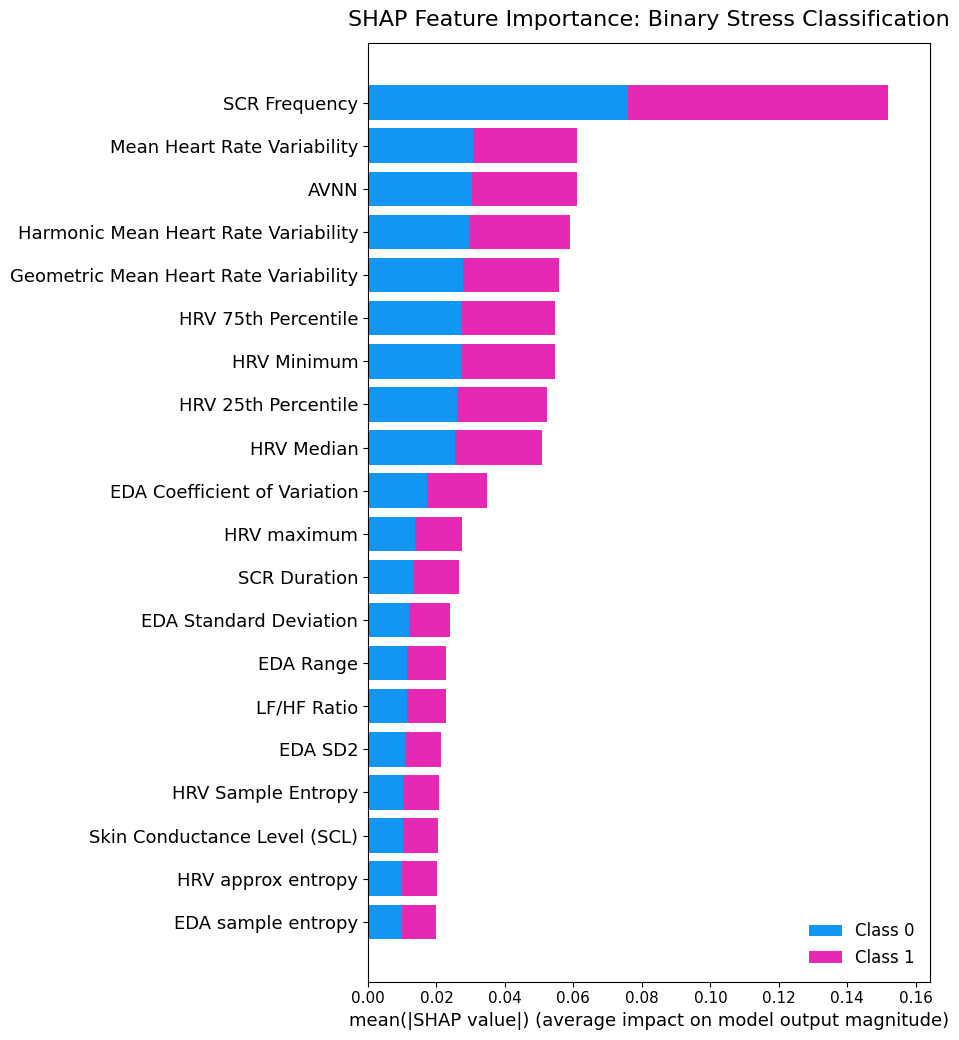


Saved figure to: figures/figure_17_shap_feature_importance_binary_stress_classification.png


In [ ]:
# ============================================================
# SHAP Feature Importance: Binary Stress Classification
# Loads or trains final Extra Trees model, then creates figure
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import joblib

try:
    import shap
except ImportError:
    raise ImportError("Install SHAP first: pip install shap")


# -----------------------------
# Paths
# -----------------------------
CSV_PATH = "/content/drive/MyDrive/StressID Dataset/colab_outputs/features/combined_features.csv"   # change this if your csv has a different name/path
MODEL_DIR = Path("models")
FIGURE_DIR = Path("figures")

MODEL_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "final_extra_trees_binary_stress_model.joblib"
IMPUTER_PATH = MODEL_DIR / "final_extra_trees_binary_imputer.joblib"
ENCODER_PATH = MODEL_DIR / "final_extra_trees_binary_label_encoder.joblib"

OUTPUT_FIGURE = FIGURE_DIR / "figure_17_shap_feature_importance_binary_stress_classification.png"


# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv(CSV_PATH)

print("Loaded dataset:", df.shape)
print("Columns:", len(df.columns))


# -----------------------------
# Define feature columns
# -----------------------------
exclude_cols = [
    "dataset",
    "subject_id",
    "task_name",
    "window_start_sec",
    "window_end_sec",
    "binary_target",
    "multiclass_target",
    "wesad_original_label",
    "stressid_binary_stress_original",
    "stressid_affect3_class_v2_original",
]

feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].copy()
y_raw = df["binary_target"].copy()

print("Number of model input features:", len(feature_cols))
print("Binary target distribution:")
print(y_raw.value_counts())


# -----------------------------
# Encode target
# -----------------------------
# This usually maps non_stress/stress alphabetically.
# Check printed classes below to confirm.
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Label encoding:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"{idx}: {class_name}")


# -----------------------------
# Impute missing values
# -----------------------------
# Extra Trees cannot handle NaNs directly.
# Median imputation matches the method section.
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

X_imputed_df = pd.DataFrame(X_imputed, columns=feature_cols)


# -----------------------------
# Load existing model if available, otherwise train and save
# -----------------------------
if MODEL_PATH.exists() and IMPUTER_PATH.exists() and ENCODER_PATH.exists():
    print("\nLoading saved model, imputer, and label encoder...")

    final_binary_model = joblib.load(MODEL_PATH)
    imputer = joblib.load(IMPUTER_PATH)
    label_encoder = joblib.load(ENCODER_PATH)

    X_imputed = imputer.transform(X)
    X_imputed_df = pd.DataFrame(X_imputed, columns=feature_cols)

else:
    print("\nTraining final Extra Trees binary model...")

    final_binary_model = ExtraTreesClassifier(
        n_estimators=300,
        criterion="gini",
        max_depth=30,
        max_features=0.5,
        min_samples_leaf=3,
        min_samples_split=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

    sample_weights = compute_sample_weight(class_weight="balanced", y=y)

    final_binary_model.fit(X_imputed_df, y, sample_weight=sample_weights)

    joblib.dump(final_binary_model, MODEL_PATH)
    joblib.dump(imputer, IMPUTER_PATH)
    joblib.dump(label_encoder, ENCODER_PATH)

    print("Saved model to:", MODEL_PATH)


# -----------------------------
# Compute SHAP values
# -----------------------------
print("\nComputing SHAP values...")

explainer = shap.TreeExplainer(final_binary_model)
shap_values = explainer.shap_values(X_imputed_df)

# SHAP output format depends on SHAP version.
# This block handles the common formats.
if isinstance(shap_values, list):
    # Old SHAP format: list[class] -> array(samples, features)
    class_importance = []
    for class_shap in shap_values:
        class_importance.append(np.abs(class_shap).mean(axis=0))
    class_importance = np.vstack(class_importance)

elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # New SHAP format: array(samples, features, classes)
    class_importance = np.abs(shap_values).mean(axis=0).T

elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
    # Some binary models return only one matrix.
    # Treat it as class 1 contribution.
    class1_importance = np.abs(shap_values).mean(axis=0)
    class0_importance = np.zeros_like(class1_importance)
    class_importance = np.vstack([class0_importance, class1_importance])

else:
    raise ValueError(
        f"Unexpected SHAP output format: {type(shap_values)}, "
        f"shape={getattr(shap_values, 'shape', None)}"
    )

# Keep two classes for binary classification
class_importance = class_importance[:2, :]


# -----------------------------
# Build importance dataframe
# -----------------------------
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Class 0": class_importance[0],
    "Class 1": class_importance[1],
})

importance_df["Total"] = importance_df["Class 0"] + importance_df["Class 1"]
importance_df = importance_df.sort_values("Total", ascending=False).head(20)

print("\nTop 20 SHAP features:")
print(importance_df[["Feature", "Class 0", "Class 1", "Total"]])


# -----------------------------
# Pretty feature names
# -----------------------------
pretty_names = {
    "SCR Frequency": "SCR Frequency",
    "SCR_Frequency": "SCR Frequency",
    "AVNN": "AVNN",

    "HRV_mean": "Mean Heart Rate Variability",
    "HRV_geometric_mean": "Geometric Mean Heart Rate Variability",
    "HRV_harmonic_mean": "Harmonic Mean Heart Rate Variability",
    "HRV_median": "HRV Median",
    "HRV_25th_percentile": "HRV 25th Percentile",
    "HRV_75th_percentile": "HRV 75th Percentile",
    "HRV_minimum": "HRV Minimum",
    "HRV_sample_entropy": "HRV Sample Entropy",
    "HRV_standard_deviation": "HRV Standard Deviation",

    "EDA_variation_coefficient": "EDA Coefficient of Variation",
    "EDA_harmonic_mean": "Harmonic Mean Electrodermal Activity",
    "EDA_maximum": "EDA Maximum",
    "EDA_75th_percentile": "EDA 75th Percentile",
    "EDA_standard_deviation": "EDA Standard Deviation",
    "EDA_range": "EDA Range",
    "EDA_median": "EDA Median",

    "SCR Duration": "SCR Duration",
    "SCR_Duration": "SCR Duration",
    "LF Power": "LF Power",
    "LF_Power": "LF Power",
    "SCL": "Skin Conductance Level (SCL)",
}


def clean_feature_name(name):
    return pretty_names.get(name, name.replace("_", " "))


# Reverse order so highest feature appears at top in horizontal bar chart
plot_df = importance_df.iloc[::-1].copy()
labels = [clean_feature_name(f) for f in plot_df["Feature"]]


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9.5, 10.5))

y_pos = np.arange(len(plot_df))

plt.barh(
    y_pos,
    plot_df["Class 0"],
    label="Class 0",
    color="#1296F3"
)

plt.barh(
    y_pos,
    plot_df["Class 1"],
    left=plot_df["Class 0"],
    label="Class 1",
    color="#E629B3"
)

plt.yticks(y_pos, labels, fontsize=13)
plt.xticks(fontsize=11)

plt.xlabel(
    "mean(|SHAP value|) (average impact on model output magnitude)",
    fontsize=13
)

plt.title(
    "SHAP Feature Importance: Binary Stress Classification",
    fontsize=16,
    pad=12
)

plt.legend(loc="lower right", fontsize=12, frameon=False)

# Make x-axis match the multiclass-style figure unless values exceed it
xmax = max(0.12, importance_df["Total"].max() * 1.08)
plt.xlim(0, xmax)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved figure to:", OUTPUT_FIGURE)